In [7]:
import yfinance as yf
import numpy as np
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install yfinance
from src.risk.monte_carlo_var import monte_carlo_option_var
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# 1. Get latest stock price
stock_hist = ticker.history(period="5d") #check the timeline as well.
S0 = stock_hist["Close"].iloc[-1]

# 2. Get nearest option expiration
exp = ticker.options[0]
chain = ticker.option_chain(exp)

calls = chain.calls
puts = chain.puts
shares = 5000 

# 3. Pick one option contract
option = calls.iloc[0]

K = option["strike"]

#check these ones. 
option_price = option["lastPrice"]
implied_vol = option["impliedVolatility"]

print("Stock price S0:", S0)
print("Strike K:", K)
print("Option price:", option_price)
print("Implied volatility:", implied_vol)
print("Expiration:", exp)

contracts = 50
portfolio_value = option_price * 100 * contracts
print("Current Option Portfolio Value:", portfolio_value)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python
zsh:1: no such file or directory: /Users/sangpark/Documents/Risk
Stock price S0: 294.0899963378906
Strike K: 205.0
Option price: 88.29
Implied volatility: 3.307618918457031
Expiration: 2026-05-13
Current Option Portfolio Value: 441450.0


In [8]:
option = calls.iloc[0]
K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=0.5,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="call",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=10
)
print("Monte Carlo Option VaR:", result["var"])

Monte Carlo Option VaR: 305246.04647054995


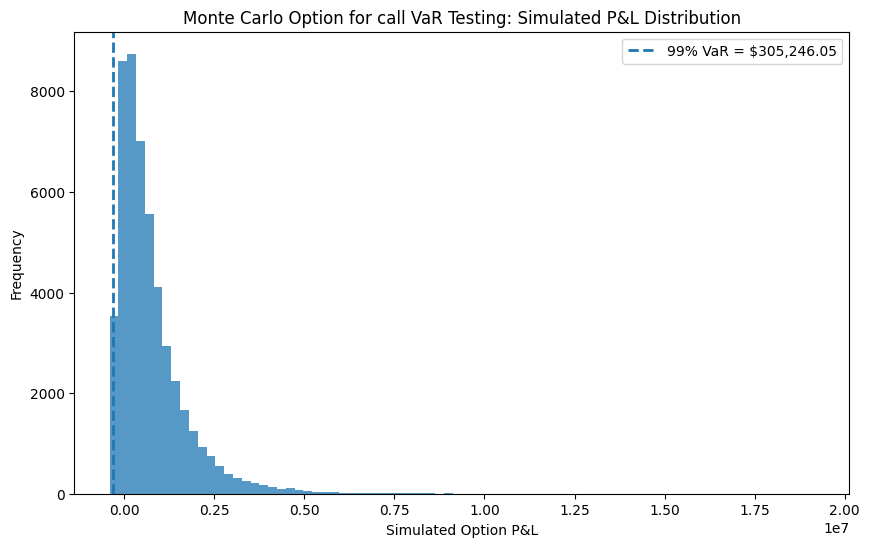

In [9]:
import matplotlib.pyplot as plt
pnl = result["pnl"]
var = result["var"]

plt.figure(figsize=(10, 6))
plt.hist(pnl, bins=80, alpha=0.75)

# VaR line
plt.axvline(-var, linestyle="--", linewidth=2, label=f"99% VaR = ${var:,.2f}")
plt.title("Monte Carlo Option for call VaR Testing: Simulated P&L Distribution")
plt.xlabel("Simulated Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [10]:
import sys
print(sys.executable)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python


"Put option"

In [11]:
import pandas as pd
import numpy as np

# Select ATM put
closest_idx = (puts["strike"] - S0).abs().idxmin()
option = puts.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# Correct time to maturity
expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

T = max((expiration_date - today).days / 365, 1 / 365)

# Horizon cannot exceed remaining maturity
horizon_days = min(1, max((expiration_date - today).days, 1))
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="put",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=horizon_days
)
raw_var = result["var"]
clean_var = max(raw_var, 0)

print("Selected Put:")
print(option)

print("T:", T)
print("Horizon days:", horizon_days)
print("Monte Carlo Put VaR:", clean_var)
print("1% PnL percentile:", np.percentile(result["pnl"], 1))

Selected Put:
contractSymbol             AAPL260513P00295000
lastTradeDate        2026-05-12 18:23:41+00:00
strike                                   295.0
lastPrice                                  2.3
bid                                       2.13
ask                                       2.22
change                                    -1.3
percentChange                        -36.11111
volume                                 10397.0
openInterest                             226.0
impliedVolatility                     0.198494
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
Name: 29, dtype: object
T: 0.0027397260273972603
Horizon days: 1
Monte Carlo Put VaR: 11499.999999999998
1% PnL percentile: -11499.999999999998


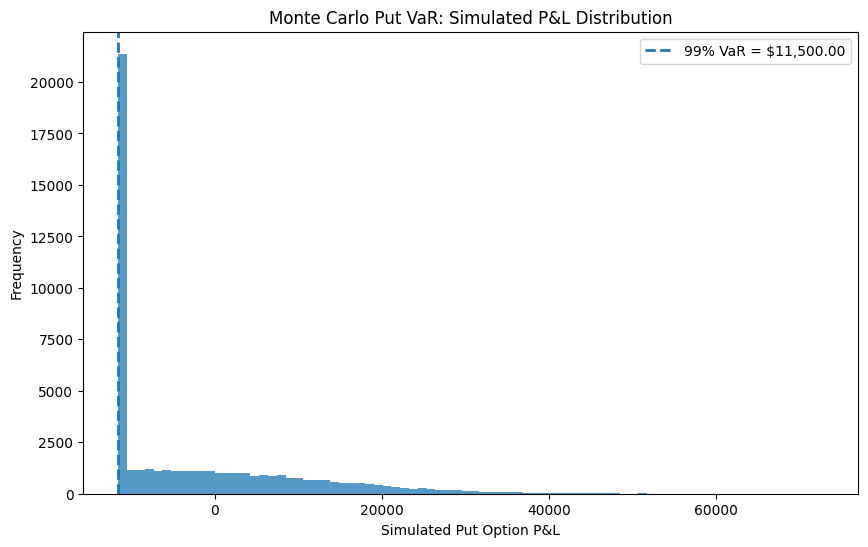

In [12]:
import matplotlib.pyplot as plt
import numpy as np

pnl = result["pnl"]
var = clean_var

plt.figure(figsize=(10, 6))

plt.hist(pnl, bins=80, alpha=0.75)

plt.axvline(
    -var,
    linestyle="--",
    linewidth=2,
    label=f"99% VaR = ${var:,.2f}"
)

plt.title("Monte Carlo Put VaR: Simulated P&L Distribution")
plt.xlabel("Simulated Put Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

  Expiration_Type Expiration_Date  Strike  Option_Price  Implied_Vol  \
0           Short      2026-05-13   295.0          2.02     0.202889   
1          Medium      2026-05-22   295.0          5.10     0.233467   
2            Long      2026-07-17   295.0         11.25     0.215889   

          T           VaR  
0  0.002740   2020.000000  
1  0.027397   5100.000000  
2  0.180822  10142.274086  


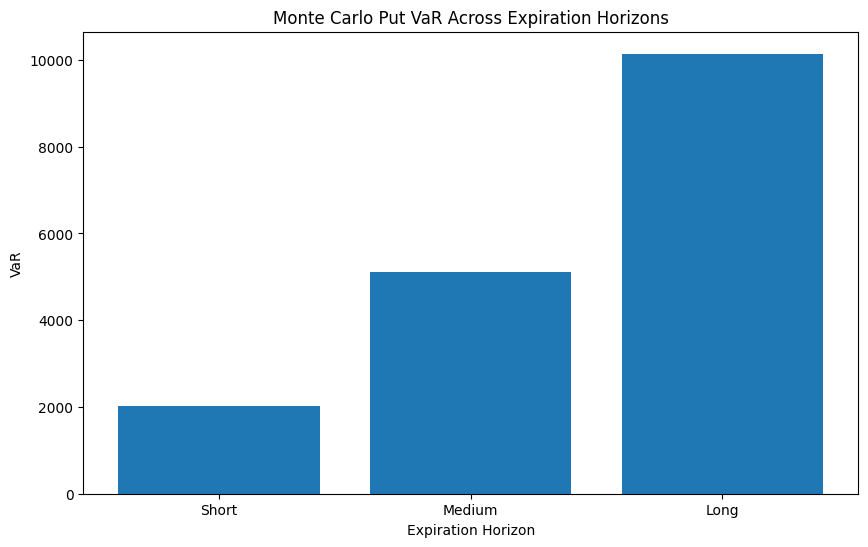

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Current stock price
stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

contracts = 10
# ---------------------------------------------
# Expiration selections
# ---------------------------------------------

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []

# ---------------------------------------------
# Run Monte Carlo VaR for each expiration
# ---------------------------------------------

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    puts = chain.puts

    # Select ATM put
    closest_idx = (puts["strike"] - S0).abs().idxmin()
    option = puts.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    # Time to maturity
    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    T = max((expiration_date - today).days / 365, 1 / 365)

    horizon_days = min(10, max((expiration_date - today).days, 1))

    # Monte Carlo VaR
    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=0.05,
        sigma=sigma,
        option_price=option_price,
        option_type="put",
        contracts=contracts,
        n_sim=50000,
        confidence=0.99,
        horizon_days=horizon_days
    )

    var = max(result["var"], 0)

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "T": T,
        "VaR": var
    })

# ---------------------------------------------
# Results table
# ---------------------------------------------

df_results = pd.DataFrame(results)

print(df_results)

# ---------------------------------------------
# Visualization
# ---------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    df_results["Expiration_Type"],
    df_results["VaR"]
)

plt.title("Monte Carlo Put VaR Across Expiration Horizons")
plt.xlabel("Expiration Horizon")
plt.ylabel("VaR")

plt.show()

#we expect the option with longer expiration date to have a higher volatility but also high pnl.

Available expirations:
('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
  Expiration_Type Expiration_Date  Days_to_Expiration  Strike  Option_Price  \
0           Short      2026-05-13                   1   295.0          2.04   
1          Medium      2026-05-22                  10   295.0          5.10   
2            Long      2026-07-17                  66   295.0         11.25   

   Implied_Vol  Portfolio_Value  Horizon_Days           VaR     VaR_%  
0     0.198738           2040.0             1   2040.000000  1.000000  
1     0.230965           5100.0            10   5100.000000  1.000000  
2     0.216866          11250.0            10  10125.200543  0.900018  


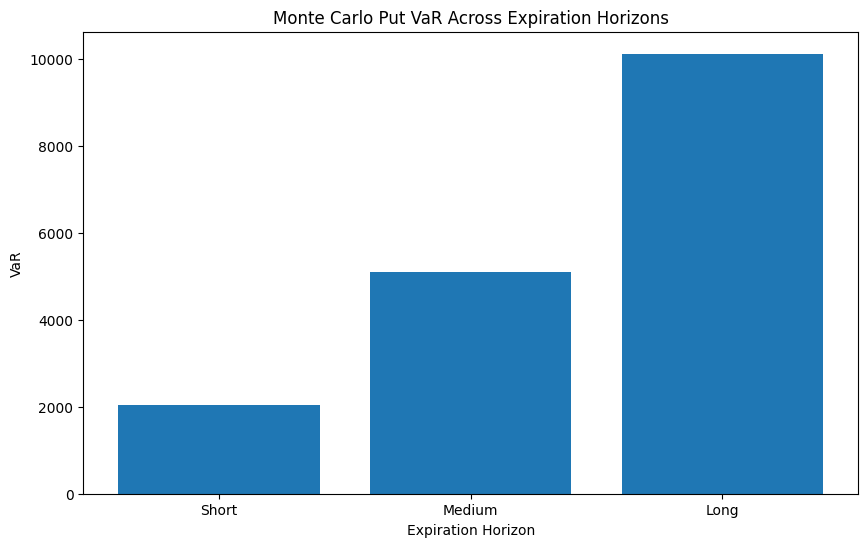

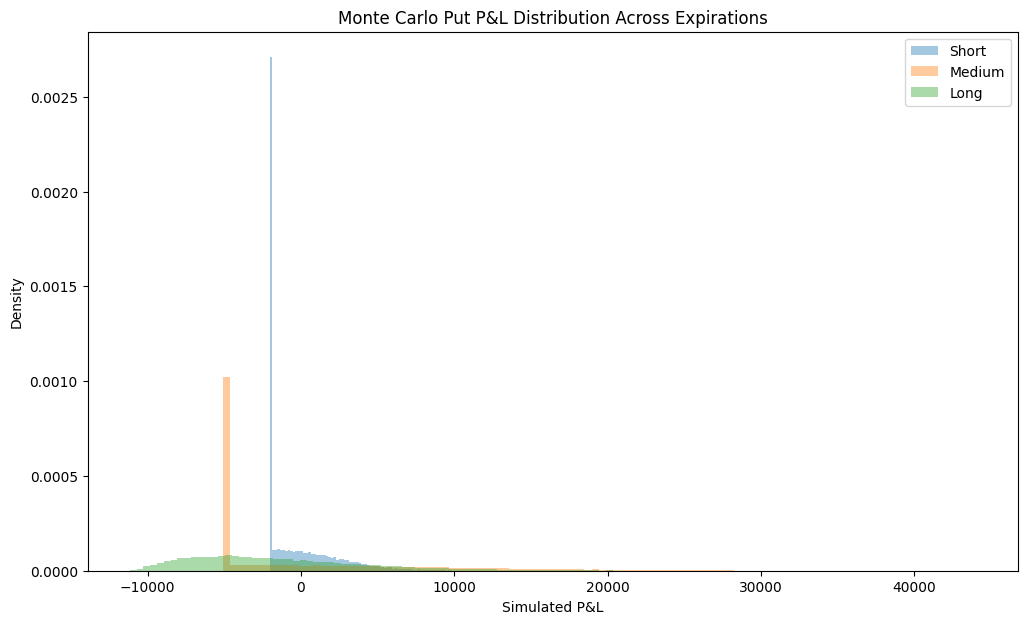

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

contracts = 10
r = 0.05
confidence = 0.99

print("Available expirations:")
print(ticker.options)

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []
all_pnls = {}

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    puts = chain.puts

    # Select ATM put
    closest_idx = (puts["strike"] - S0).abs().idxmin()
    option = puts.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    days_to_exp = max((expiration_date - today).days, 1)
    T = days_to_exp / 365

    horizon_days = min(10, days_to_exp)

    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_price=option_price,
        option_type="put",
        contracts=contracts,
        n_sim=50000,
        confidence=confidence,
        horizon_days=horizon_days
    )
    
    var = max(result["var"], 0)
    portfolio_value = option_price * 100 * contracts

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Days_to_Expiration": days_to_exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "Portfolio_Value": portfolio_value,
        "Horizon_Days": horizon_days,
        "VaR": var,
        "VaR_%": var / portfolio_value if portfolio_value > 0 else np.nan
    })

    all_pnls[label] = result["pnl"]

df_results = pd.DataFrame(results)

print(df_results)

# Bar chart: VaR by expiration
plt.figure(figsize=(10, 6))
plt.bar(df_results["Expiration_Type"], df_results["VaR"])
plt.title("Monte Carlo Put VaR Across Expiration Horizons")
plt.xlabel("Expiration Horizon")
plt.ylabel("VaR")
plt.show()

# Histogram: P&L distribution by expiration
plt.figure(figsize=(12, 7))

for label, pnl in all_pnls.items():
    plt.hist(pnl, bins=100, alpha=0.4, density=True, label=label)

plt.title("Monte Carlo Put P&L Distribution Across Expirations")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.show()

Pnl Distribution for the call option: 


Available expirations:
('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
  Expiration_Type Expiration_Date  Days_to_Expiration  Strike  Option_Price  \
0           Short      2026-05-13                   1   295.0          1.37   
1          Medium      2026-05-22                  10   295.0          1.37   
2            Long      2026-07-17                  66   295.0          1.37   

   Implied_Vol  Portfolio_Value  Horizon_Days          VaR     VaR_%  
0     0.205574           1370.0             1  1370.000000  1.000000  
1     0.205574           1370.0            10  1370.000000  1.000000  
2     0.205574           1370.0            10    26.485953  0.019333  


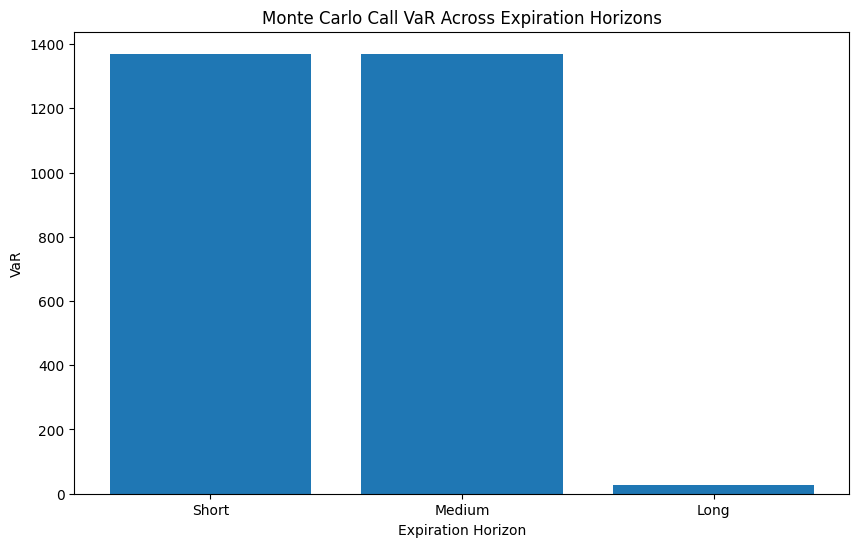

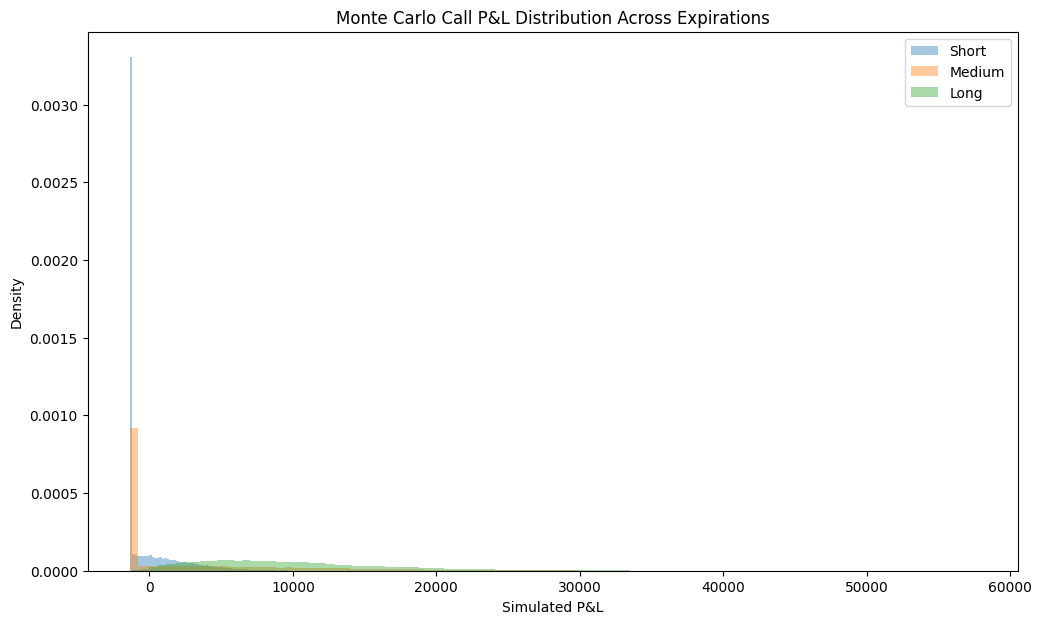

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)
stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]
contracts = 10
r = 0.05
confidence = 0.99

print("Available expirations:")
print(ticker.options)

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []
all_pnls = {}

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    calls = chain.calls

    # Select ATM put
    closest_idx = (calls["strike"] - S0).abs().idxmin()
    option = calls.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    days_to_exp = max((expiration_date - today).days, 1)
    T = days_to_exp / 365

    horizon_days = min(10, days_to_exp)

    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_price=option_price,
        option_type="call",
        contracts=contracts,
        n_sim=50000,
        confidence=confidence,
        horizon_days=horizon_days
    )
    
    var = max(result["var"], 0)
    portfolio_value = option_price * 100 * contracts

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Days_to_Expiration": days_to_exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "Portfolio_Value": portfolio_value,
        "Horizon_Days": horizon_days,
        "VaR": var,
        "VaR_%": var / portfolio_value if portfolio_value > 0 else np.nan
    })

    all_pnls[label] = result["pnl"]

df_results = pd.DataFrame(results)

print(df_results)

# Bar chart: VaR by expiration
plt.figure(figsize=(10, 6))
plt.bar(df_results["Expiration_Type"], df_results["VaR"])
plt.title("Monte Carlo Call VaR Across Expiration Horizons")
plt.xlabel("Expiration Horizon")
plt.ylabel("VaR")
plt.show()

# Histogram: P&L distribution by expiration
plt.figure(figsize=(12, 7))

for label, pnl in all_pnls.items():
    plt.hist(pnl, bins=100, alpha=0.4, density=True, label=label)

plt.title("Monte Carlo Call P&L Distribution Across Expirations")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.show()

#there is a high voliatility when short and medium expirations are very high. 

In [ ]:
#There are higher VAR for short and medium expiratinos. 
#We make our internal model so that it captures the fixed portfolio, not stock shares since the asset value changes over period of market regime period. 

In [52]:
#This is for the stock portfolio, not options related portfolio.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  Regime  Start_Date    End_Date  Mean_Return  Volatility  \
0     Normal Market 2023  2023-01-01  2024-01-01     0.001835    0.012570   
1      COVID Crisis 2020  2020-02-01  2020-05-01     0.000214    0.044702   
2  Rate-Hike Regime 2022  2022-01-01  2022-12-31    -0.001074    0.022471   
3  Financial Crisis 2008  2008-09-01  2009-03-01    -0.004009    0.045348   

   Portfolio_Value  Parametric_VaR  Parametric_CVaR     VaR_%  
0          1000000    74123.074347     87593.013678  0.074123  
1          1000000   326714.412085    374616.477592  0.326714  
2          1000000   176046.511453    200126.533181  0.176047  
3          1000000   373698.248104    422292.917338  0.373698  


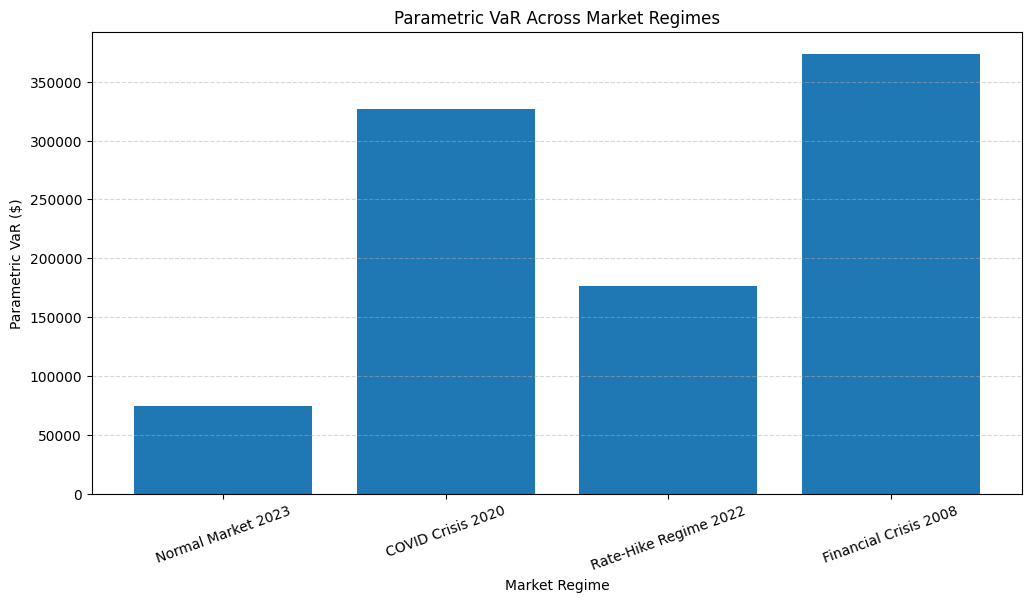

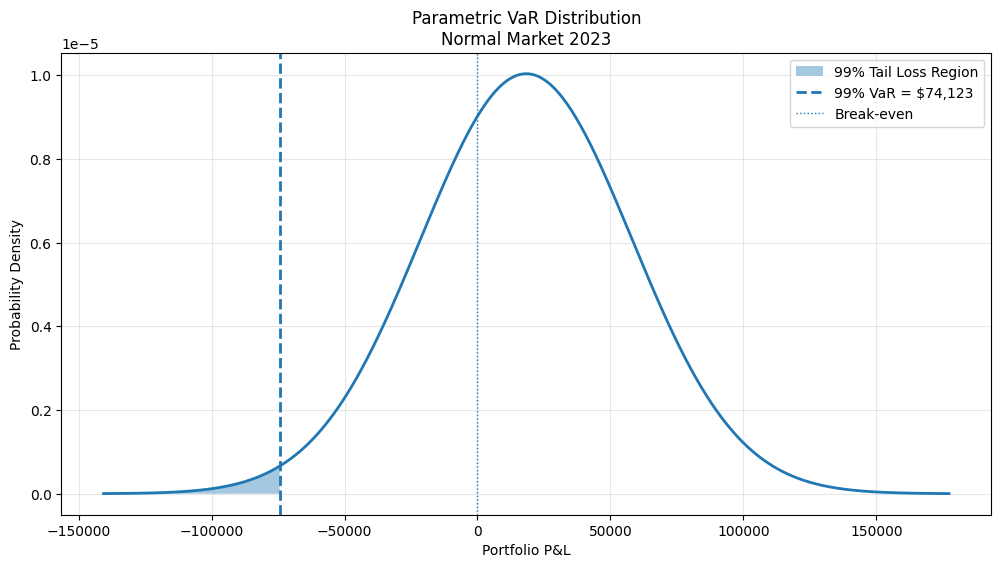

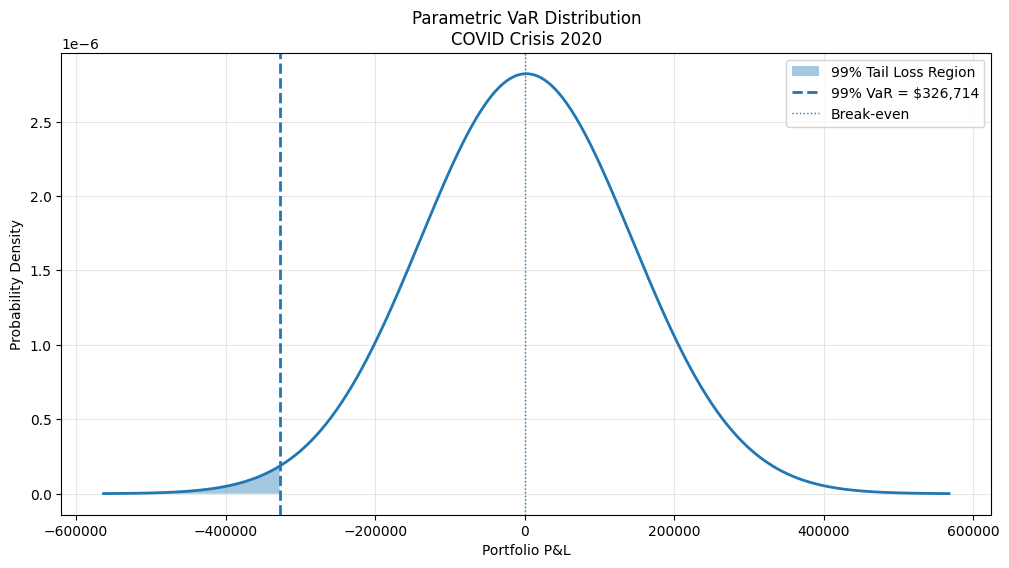

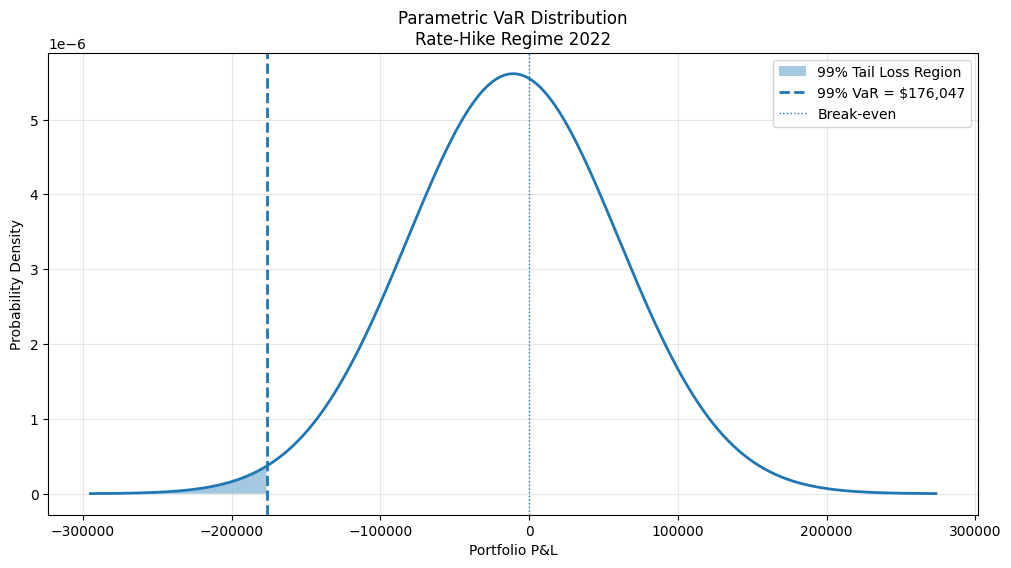

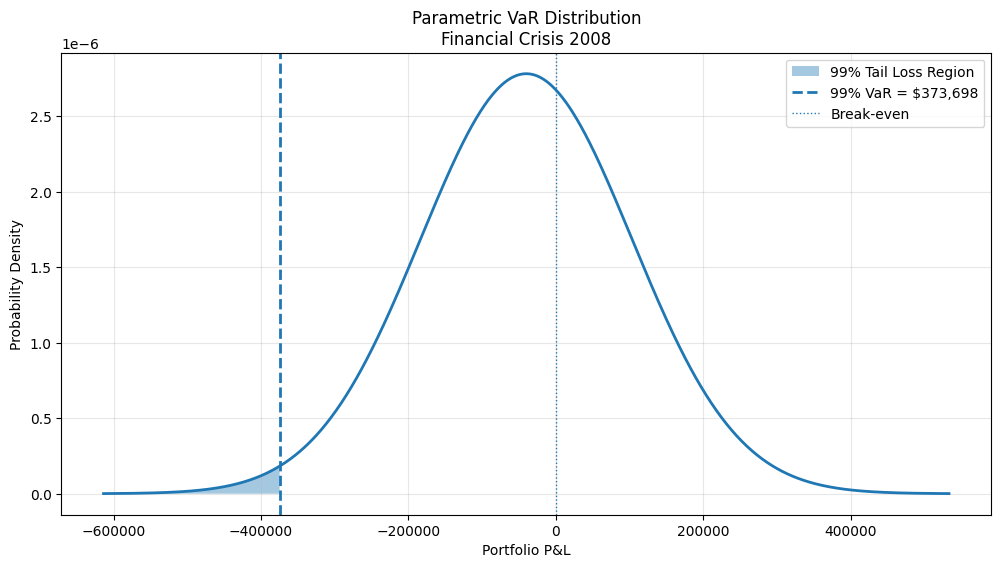

In [55]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.risk.parametric_var import parametric_var

# Settings

ticker_symbol = "AAPL"

portfolio_value = 1_000_000

confidence = 0.99

horizon = 10

# Market Regimes

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}

results = []

distribution_data = {}

# Run Parametric VaR by Regime

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    # Convert dataframe -> series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    # Returns

    returns = prices.pct_change().dropna()

    mu = returns.mean()

    sigma = returns.std()

    # Parametric VaR

    result = parametric_var(
        mu=mu,
        sigma=sigma,
        portfolio_value=portfolio_value,
        confidence=confidence,
        horizon=horizon
    )

    # Distribution Setup


    portfolio_mean = portfolio_value * mu * horizon

    portfolio_std = portfolio_value * sigma * np.sqrt(horizon)

    x = np.linspace(
        portfolio_mean - 4 * portfolio_std,
        portfolio_mean + 4 * portfolio_std,
        1000
    )

    y = norm.pdf(
        x,
        portfolio_mean,
        portfolio_std
    )

    var_cutoff = -result["var"]

    distribution_data[regime_name] = {
        "x": x,
        "y": y,
        "var_cutoff": var_cutoff,
        "var": result["var"]
    }

    # Store Results

    results.append({
        "Regime": regime_name,
        "Start_Date": start_date,
        "End_Date": end_date,
        "Mean_Return": mu,
        "Volatility": sigma,
        "Portfolio_Value": portfolio_value,
        "Parametric_VaR": result["var"],
        "Parametric_CVaR": result["cvar"],
        "VaR_%": result["var"] / portfolio_value
    })

# Results Table
df_results = pd.DataFrame(results)

print(df_results)
#Bar Chart: VaR Comparison

plt.figure(figsize=(12, 6))

plt.bar(
    df_results["Regime"],
    df_results["Parametric_VaR"]
)

plt.title("Parametric VaR Across Market Regimes")

plt.xlabel("Market Regime")

plt.ylabel("Parametric VaR ($)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

#Parametric Distribution Graphs Comparison.

for regime_name, data in distribution_data.items():
    x = data["x"]
    y = data["y"]

    var_cutoff = data["var_cutoff"]
    var = data["var"]
    plt.figure(figsize=(12, 6))
    plt.plot(
        x,
        y,
        linewidth=2
    )
    # Tail region
    plt.fill_between(
        x,
        y,
        where=(x <= var_cutoff),
        alpha=0.4,
        label="99% Tail Loss Region"
    )
    # VaR line
    plt.axvline(
        var_cutoff,
        linestyle="--",
        linewidth=2,
        label=f"99% VaR = ${var:,.0f}"
    )

    # Zero P&L line
    plt.axvline(
        0,
        linestyle=":",
        linewidth=1,
        label="Break-even"
    )

    plt.title(
        f"Parametric VaR Distribution\n{regime_name}"
    )

    plt.xlabel("Portfolio P&L")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

#For calls and puts, use your Monte Carlo option repricing VaR function instead.

Current Stock Price: 294.79998779296875
Available expirations:
('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
  Expiration_Type Expiration_Date Option_Type  Days_to_Expiration  Strike  \
0           Short      2026-05-13        call                   1   295.0   
1           Short      2026-05-13         put                   1   295.0   
2          Medium      2026-05-22        call                  10   295.0   
3          Medium      2026-05-22         put                  10   295.0   
4            Long      2026-07-17        call                  66   295.0   
5            Long      2026-07-17         put                  66   295.0   

   Option_Price  Implied_Vol    Bid    Ask  Bid_Ask_Spread  

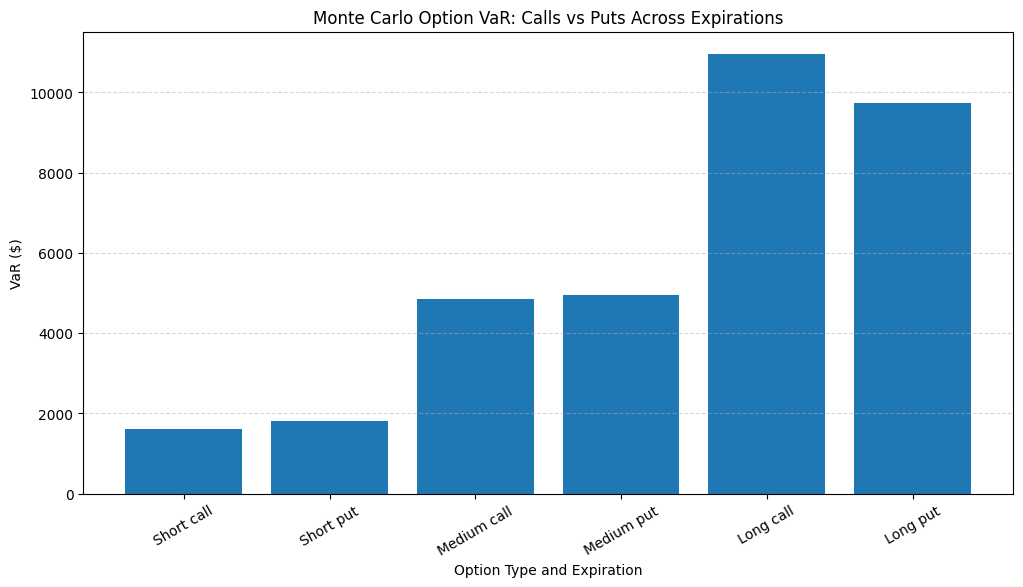

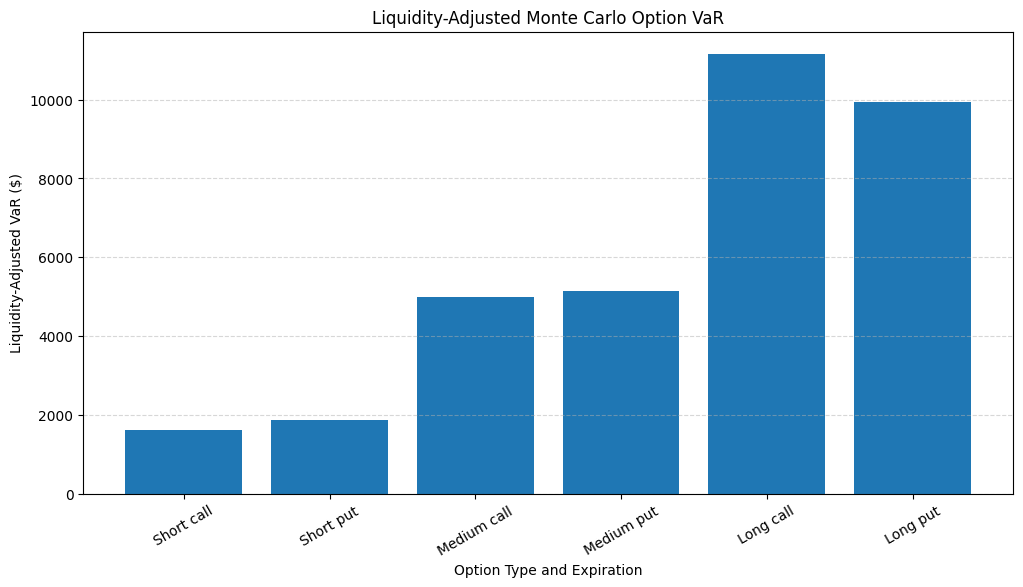

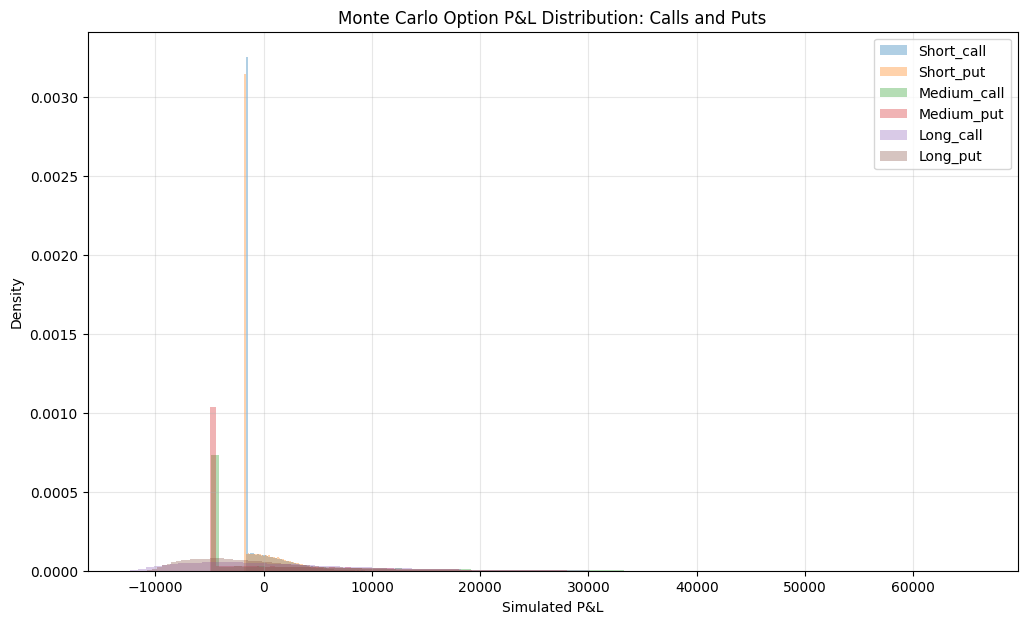

  Expiration_Type Expiration_Date Option_Type  Strike  Option_Price    Bid  \
0           Short      2026-05-13        call   295.0          1.60   1.58   
1           Short      2026-05-13         put   295.0          1.80   1.74   
2          Medium      2026-05-22        call   295.0          4.85   4.85   
3          Medium      2026-05-22         put   295.0          4.95   4.75   
4            Long      2026-07-17        call   295.0         12.58  12.60   
5            Long      2026-07-17         put   295.0         10.81  10.85   

     Ask  Bid_Ask_Spread  Spread_Cost   Volume  Open_Interest           VaR  \
0   1.60            0.02         20.0  99006.0         6689.0   1600.000000   
1   1.80            0.06         60.0  12183.0          226.0   1800.000000   
2   5.00            0.15        150.0   4212.0         3374.0   4850.000000   
3   4.95            0.20        200.0    824.0          240.0   4950.000000   
4  12.80            0.20        200.0   1372.0        4771

In [56]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

contracts = 10
r = 0.05
confidence = 0.99
n_sim = 50000

# ---------------------------------------------------
# Current Stock Price
# ---------------------------------------------------

stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

print("Current Stock Price:", S0)

print("Available expirations:")
print(ticker.options)

# ---------------------------------------------------
# Select Expiration Horizons
# ---------------------------------------------------

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []
all_pnls = {}

# ---------------------------------------------------
# Run Monte Carlo VaR for Calls and Puts
# ---------------------------------------------------

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)

    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    days_to_exp = max((expiration_date - today).days, 1)
    T = days_to_exp / 365

    horizon_days = min(10, days_to_exp)

    for option_type, option_chain in {
        "call": chain.calls,
        "put": chain.puts
    }.items():

        # Select ATM option
        closest_idx = (option_chain["strike"] - S0).abs().idxmin()
        option = option_chain.loc[closest_idx]

        K = option["strike"]
        option_price = option["lastPrice"]
        sigma = option["impliedVolatility"]

        bid = option["bid"]
        ask = option["ask"]
        volume = option["volume"]
        open_interest = option["openInterest"]

        result = monte_carlo_option_var(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            option_price=option_price,
            option_type=option_type,
            contracts=contracts,
            n_sim=n_sim,
            confidence=confidence,
            horizon_days=horizon_days
        )

        var = max(result["var"], 0)
        portfolio_value = option_price * 100 * contracts

        bid_ask_spread = ask - bid
        spread_cost = bid_ask_spread * 100 * contracts
        liquidity_adjusted_var = var + spread_cost

        results.append({
            "Expiration_Type": label,
            "Expiration_Date": exp,
            "Option_Type": option_type,
            "Days_to_Expiration": days_to_exp,
            "Strike": K,
            "Option_Price": option_price,
            "Implied_Vol": sigma,
            "Bid": bid,
            "Ask": ask,
            "Bid_Ask_Spread": bid_ask_spread,
            "Spread_Cost": spread_cost,
            "Volume": volume,
            "Open_Interest": open_interest,
            "Portfolio_Value": portfolio_value,
            "Horizon_Days": horizon_days,
            "VaR": var,
            "VaR_%": var / portfolio_value if portfolio_value > 0 else np.nan,
            "Liquidity_Adjusted_VaR": liquidity_adjusted_var,
            "Liquidity_Adjusted_VaR_%": liquidity_adjusted_var / portfolio_value if portfolio_value > 0 else np.nan
        })

        all_pnls[f"{label}_{option_type}"] = result["pnl"]

# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

df_results = pd.DataFrame(results)

print(df_results)

# ---------------------------------------------------
# Bar Chart: Call vs Put VaR
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

labels = df_results["Expiration_Type"] + " " + df_results["Option_Type"]
plt.bar(labels, df_results["VaR"])

plt.title("Monte Carlo Option VaR: Calls vs Puts Across Expirations")
plt.xlabel("Option Type and Expiration")
plt.ylabel("VaR ($)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ---------------------------------------------------
# Bar Chart: Liquidity-Adjusted VaR
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(labels, df_results["Liquidity_Adjusted_VaR"])

plt.title("Liquidity-Adjusted Monte Carlo Option VaR")
plt.xlabel("Option Type and Expiration")
plt.ylabel("Liquidity-Adjusted VaR ($)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ---------------------------------------------------
# P&L Distribution: Calls and Puts
# ---------------------------------------------------

plt.figure(figsize=(12, 7))

for label, pnl in all_pnls.items():
    plt.hist(
        pnl,
        bins=100,
        alpha=0.35,
        density=True,
        label=label
    )

plt.title("Monte Carlo Option P&L Distribution: Calls and Puts")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ---------------------------------------------------
# Liquidity Reference Table
# ---------------------------------------------------

liquidity_table = df_results[[
    "Expiration_Type",
    "Expiration_Date",
    "Option_Type",
    "Strike",
    "Option_Price",
    "Bid",
    "Ask",
    "Bid_Ask_Spread",
    "Spread_Cost",
    "Volume",
    "Open_Interest",
    "VaR",
    "Liquidity_Adjusted_VaR"
]]

print(liquidity_table)

Parametric Testing at first for stock when the market is good in 2023- 2024 

Compare Parametric Stock vs Monte Stock 

In [51]:
plt.figure(figsize=(10, 6))
methods = ["Parametric", "Monte Carlo"]
vars_ = [param_result["var"], mc_result["var"]]
bars = plt.bar(methods, vars_)

# Add values on top
for bar, val in zip(bars, vars_):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 20,   
        f"${val:,.0f}",
        ha="center"
    )
plt.title("Stocks: 99% VaR Comparison: Parametric vs Monte Carlo")
plt.ylabel("VaR ($)")
plt.show()

NameError: name 'param_result' is not defined

<Figure size 1000x600 with 0 Axes>

Parametric vs Monte Carlo in Investment 

In [49]:
methods = ["Parametric", "Monte Carlo"]
vars_ = [
    param_result["var"],
    mc_result["var"]
]

bars = plt.bar(methods, vars_)

# ---------------------------------------------
# Add value labels
# ---------------------------------------------

for bar, val in zip(bars, vars_):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01,
        f"${val:,.0f}",
        ha="center",
        fontsize=11
    )

# ---------------------------------------------
# Formatting
# ---------------------------------------------

plt.title(
    "Stocks: 99% VaR Comparison\nParametric vs Monte Carlo",
    fontsize=14
)

plt.ylabel("VaR ($)", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# ---------------------------------------------
# Add portfolio info
# ---------------------------------------------

plt.figtext(
    0.15,
    0.80,
    f"Portfolio Value: ${portfolio_value:,.0f}\n"
    f"Shares: {shares:,}\n"
    f"Horizon: 10 Days\n"
    f"Confidence: 99%",
    fontsize=10
)
plt.show()

NameError: name 'param_result' is not defined

Parametric and Monte for Options

('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
Selected Option:
contractSymbol             AAPL260522P00295000
lastTradeDate        2026-05-12 19:27:48+00:00
strike                                   295.0
lastPrice                                 4.75
bid                                       4.75
ask                                       4.85
change                                   -1.95
percentChange                         -29.0611
volume                                   700.0
openInterest                               240
impliedVolatility                     0.232552
inTheMoney                                True
contractSize                           REGULAR
currency                           

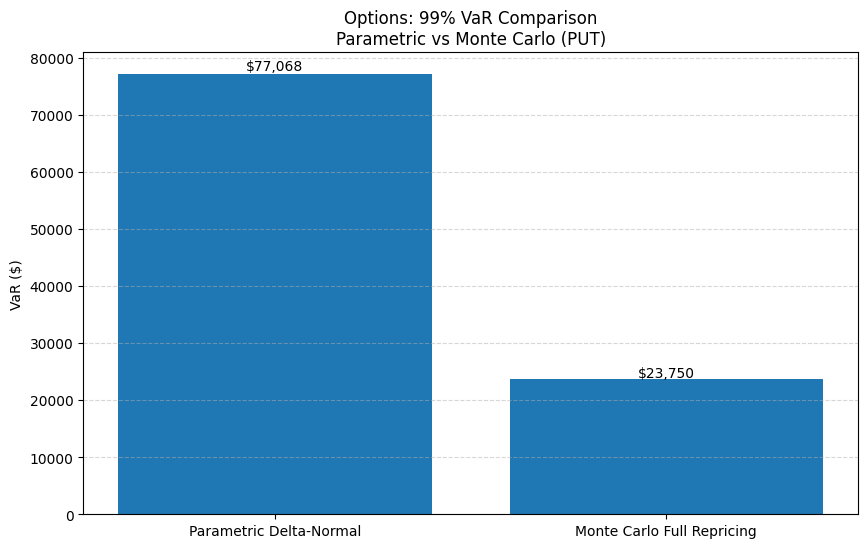

In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.monte_carlo_var import monte_carlo_option_var

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"
option_type = "put"      # "call" or "put"
contracts = 50
confidence = 0.99
r = 0.05
horizon_days = 10

ticker = yf.Ticker(ticker_symbol)

# ---------------------------------------------------
# Stock data
# ---------------------------------------------------

stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

# ---------------------------------------------------
# Option chain
# ---------------------------------------------------

# Pick a medium expiration instead of nearest
print(ticker.options)
exp = ticker.options[4]

chain = ticker.option_chain(exp)

if option_type == "call":
    options = chain.calls
else:
    options = chain.puts

# Select ATM option
closest_idx = (options["strike"] - S0).abs().idxmin()
option = options.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# ---------------------------------------------------
# Time to maturity
# ---------------------------------------------------

expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

days_to_exp = max((expiration_date - today).days, 1)
T = days_to_exp / 365

horizon_days = min(horizon_days, days_to_exp)

# ---------------------------------------------------
# Black-Scholes Delta
# ---------------------------------------------------

d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

if option_type == "call":
    delta = norm.cdf(d1)
else:
    delta = norm.cdf(d1) - 1

# ---------------------------------------------------
# Parametric Delta-Normal Option VaR
# ---------------------------------------------------

z = norm.ppf(confidence)

parametric_option_var = (
    abs(delta)
    * S0
    * sigma
    * np.sqrt(horizon_days / 252)
    * 100
    * contracts
    * z
)

# ---------------------------------------------------
# Monte Carlo Full-Repricing Option VaR
# ---------------------------------------------------

mc_result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_price=option_price,
    option_type=option_type,
    contracts=contracts,
    n_sim=50000,
    confidence=confidence,
    horizon_days=horizon_days
)

mc_option_var = max(mc_result["var"], 0)

# ---------------------------------------------------
# Results
# ---------------------------------------------------

comparison_df = pd.DataFrame({
    "Method": ["Parametric Delta-Normal", "Monte Carlo Full Repricing"],
    "VaR": [parametric_option_var, mc_option_var]
})

print("Selected Option:")
print(option)
print("\nS0:", S0)
print("Strike:", K)
print("Expiration:", exp)
print("Days to Expiration:", days_to_exp)
print("Horizon Days:", horizon_days)
print("Option Price:", option_price)
print("Implied Volatility:", sigma)
print("Delta:", delta)
print("Contracts:", contracts)

print("\n", comparison_df)

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

plt.figure(figsize=(10, 6))
bars = plt.bar(
    comparison_df["Method"],
    comparison_df["VaR"]
)
for bar, val in zip(bars, comparison_df["VaR"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01,
        f"${val:,.0f}",
        ha="center"
    )
plt.title(f"Options: 99% VaR Comparison\nParametric vs Monte Carlo ({option_type.upper()})")
plt.ylabel("VaR ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                  Regime  Start_Date    End_Date Option_Type          S0  \
0     Normal Market 2023  2023-01-01  2024-01-01        call  190.375046   
1     Normal Market 2023  2023-01-01  2024-01-01         put  190.375046   
2      COVID Crisis 2020  2020-02-01  2020-05-01        call   70.924355   
3      COVID Crisis 2020  2020-02-01  2020-05-01         put   70.924355   
4  Rate-Hike Regime 2022  2022-01-01  2022-12-31        call  127.761597   
5  Rate-Hike Regime 2022  2022-01-01  2022-12-31         put  127.761597   
6  Financial Crisis 2008  2008-09-01  2009-03-01        call    2.673533   
7  Financial Crisis 2008  2008-09-01  2009-03-01         put    2.673533   

       Strike  Option_Price  Daily_Volatility  Annualized_Volatility  \
0  190.375046      4.736876          0.012570               0.199543   
1  190.375046      3.956119          0.012570               0.199543   
2   70.924355      5.881237          0.044702               0.709620   
3   70.924355      5.590366

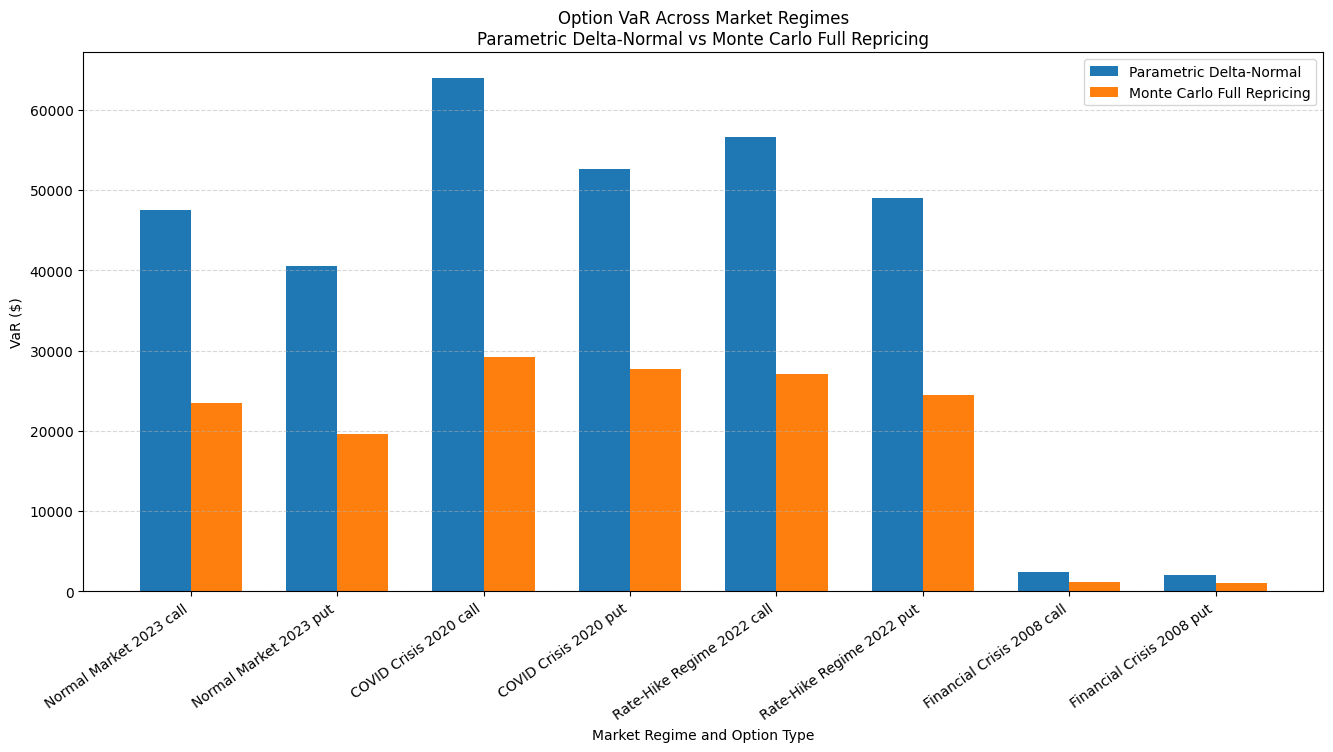

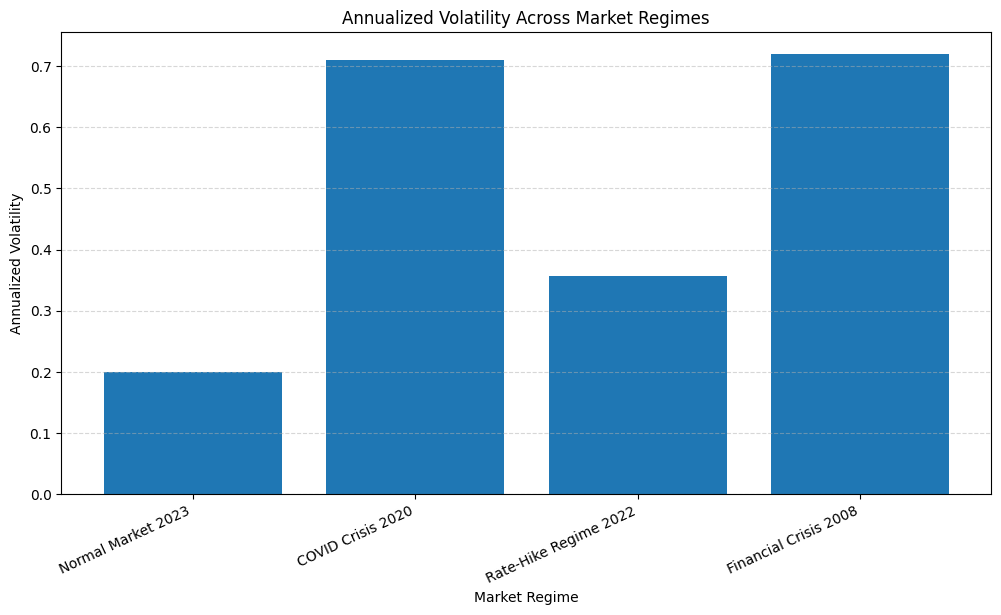

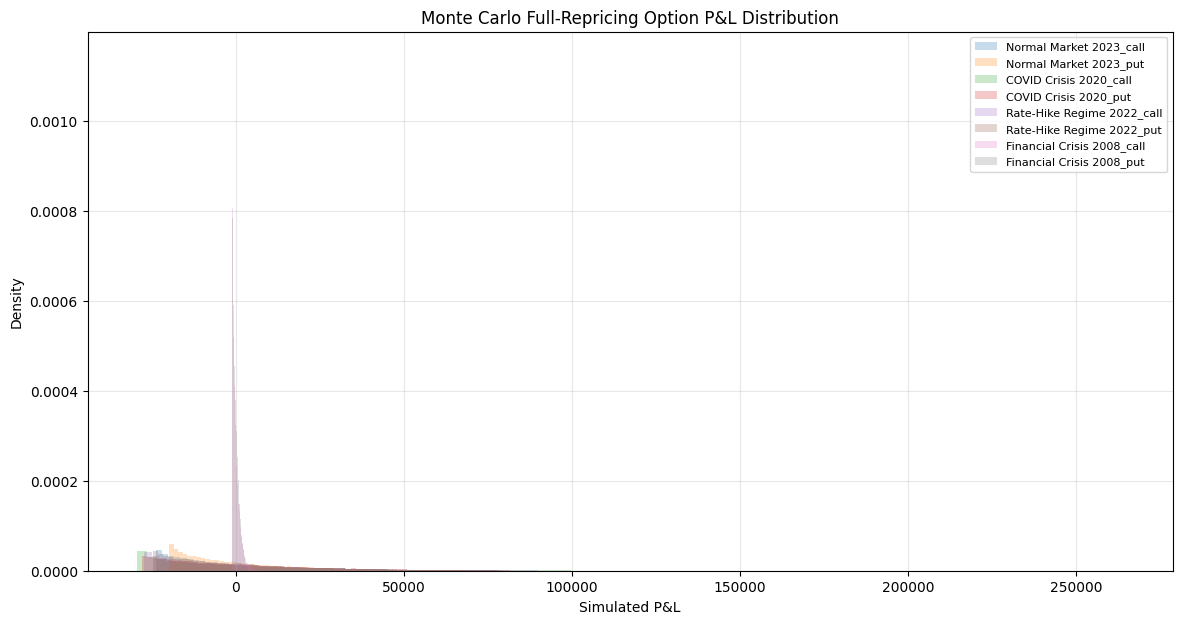

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.monte_carlo_var import monte_carlo_option_var

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"

contracts = 50
confidence = 0.99
r = 0.05
horizon_days = 10
n_sim = 50000

# Hypothetical option maturity
T = 30 / 365   # 30-day option

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}

results = []
all_pnls = {}

# ---------------------------------------------------
# Black-Scholes Price
# ---------------------------------------------------

def black_scholes_price(S, K, T, r, sigma, option_type="call"):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price


# ---------------------------------------------------
# Black-Scholes Delta
# ---------------------------------------------------

def black_scholes_delta(S, K, T, r, sigma, option_type="call"):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    if option_type == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1


# ---------------------------------------------------
# Run Option VaR by Regime
# ---------------------------------------------------

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    returns = prices.pct_change().dropna()

    daily_mu = returns.mean()
    daily_sigma = returns.std()

    annual_sigma = daily_sigma * np.sqrt(252)

    # Use last stock price in each regime
    S0 = prices.iloc[-1]

    # ATM option
    K = S0

    for option_type in ["call", "puat"]:

        option_price = black_scholes_price(
            S=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_type=option_type
        )

        delta = black_scholes_delta(
            S=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_type=option_type
        )

        # ---------------------------------------------------
        # Parametric Delta-Normal Option VaR
        # ---------------------------------------------------

        z = norm.ppf(confidence)

        parametric_option_var = (
            abs(delta)
            * S0
            * annual_sigma
            * np.sqrt(horizon_days / 252)
            * 100
            * contracts
            * z
        )

        # ---------------------------------------------------
        # Monte Carlo Full-Repricing Option VaR
        # ---------------------------------------------------

        mc_result = monte_carlo_option_var(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_price=option_price,
            option_type=option_type,
            contracts=contracts,
            n_sim=n_sim,
            confidence=confidence,
            horizon_days=horizon_days
        )

        mc_option_var = max(mc_result["var"], 0)

        portfolio_value = option_price * 100 * contracts

        results.append({
            "Regime": regime_name,
            "Start_Date": start_date,
            "End_Date": end_date,
            "Option_Type": option_type,
            "S0": S0,
            "Strike": K,
            "Option_Price": option_price,
            "Daily_Volatility": daily_sigma,
            "Annualized_Volatility": annual_sigma,
            "Delta": delta,
            "Contracts": contracts,
            "Portfolio_Value": portfolio_value,
            "Parametric_Delta_Normal_VaR": parametric_option_var,
            "Monte_Carlo_Full_Repricing_VaR": mc_option_var,
            "Parametric_VaR_%": parametric_option_var / portfolio_value,
            "Monte_Carlo_VaR_%": mc_option_var / portfolio_value
        })

        all_pnls[f"{regime_name}_{option_type}"] = mc_result["pnl"]


# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

df_results = pd.DataFrame(results)

print(df_results)


# ---------------------------------------------------
# Bar Chart: Parametric vs Monte Carlo VaR
# ---------------------------------------------------

labels = df_results["Regime"] + " " + df_results["Option_Type"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(16, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_Delta_Normal_VaR"],
    width,
    label="Parametric Delta-Normal"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_Full_Repricing_VaR"],
    width,
    label="Monte Carlo Full Repricing"
)

plt.title("Option VaR Across Market Regimes\nParametric Delta-Normal vs Monte Carlo Full Repricing")
plt.xlabel("Market Regime and Option Type")
plt.ylabel("VaR ($)")
plt.xticks(x, labels, rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ---------------------------------------------------
# Bar Chart: Annualized Volatility by Regime
# ---------------------------------------------------

vol_table = df_results.drop_duplicates("Regime")

plt.figure(figsize=(12, 6))

plt.bar(
    vol_table["Regime"],
    vol_table["Annualized_Volatility"]
)

plt.title("Annualized Volatility Across Market Regimes")
plt.xlabel("Market Regime")
plt.ylabel("Annualized Volatility")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ---------------------------------------------------
# Monte Carlo P&L Distribution
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

for label, pnl in all_pnls.items():

    plt.hist(
        pnl,
        bins=100,
        alpha=0.25,
        density=True,
        label=label
    )

plt.title("Monte Carlo Full-Repricing Option P&L Distribution")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                  Regime Option_Type          S0      Strike  Option_Price  \
0     Normal Market 2023        call  190.375046  190.375046      4.736876   
1     Normal Market 2023         put  190.375046  190.375046      3.956119   
2      COVID Crisis 2020        call   70.924355   70.924355      5.881237   
3      COVID Crisis 2020         put   70.924355   70.924355      5.590366   
4  Rate-Hike Regime 2022        call  127.761597  127.761597      5.465811   
5  Rate-Hike Regime 2022         put  127.761597  127.761597      4.941841   
6  Financial Crisis 2008        call    2.673533    2.673533      0.224810   
7  Financial Crisis 2008         put    2.673533    2.673533      0.213846   

   Daily_Volatility  Annualized_Volatility     Delta     Contracts  \
0          0.012570               0.199543  0.540003   2111.095857   
1          0.012570               0.199543 -0.459997   2527.730131   
2          0.044702               0.709620  0.548519   1700.322456   
3          0.0447

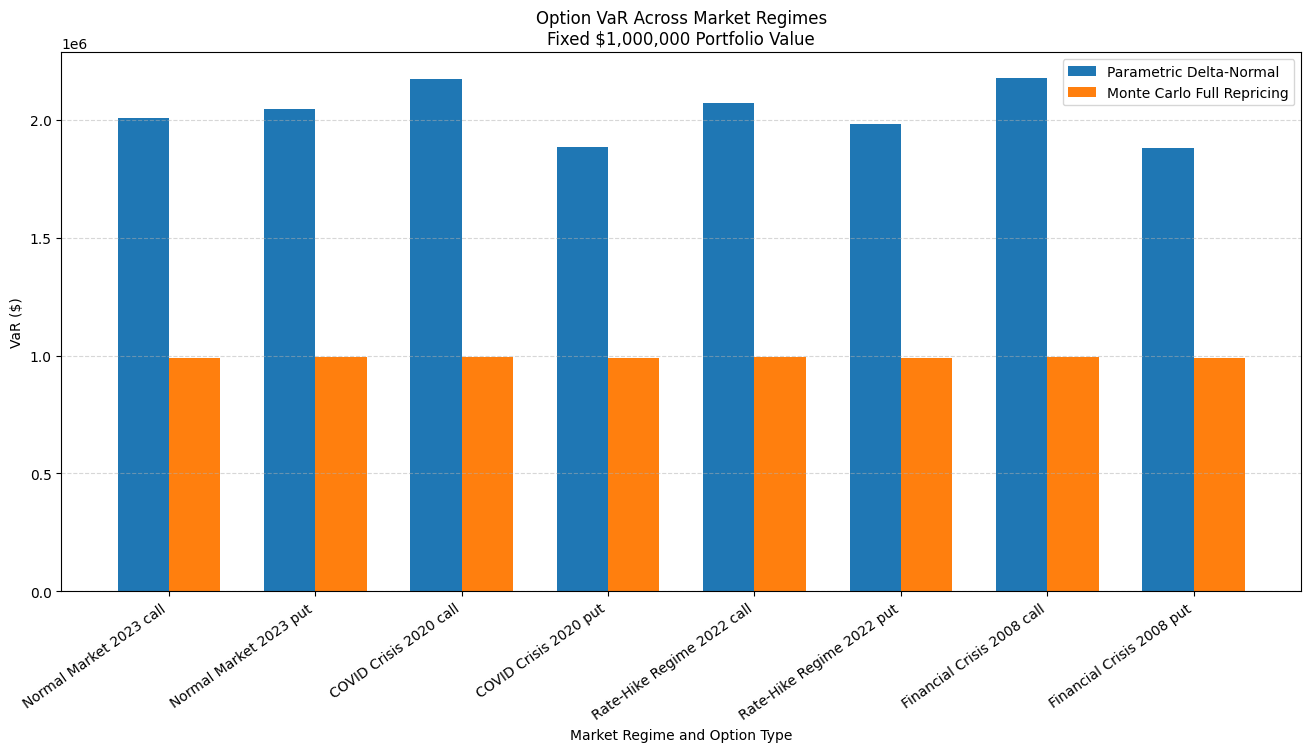

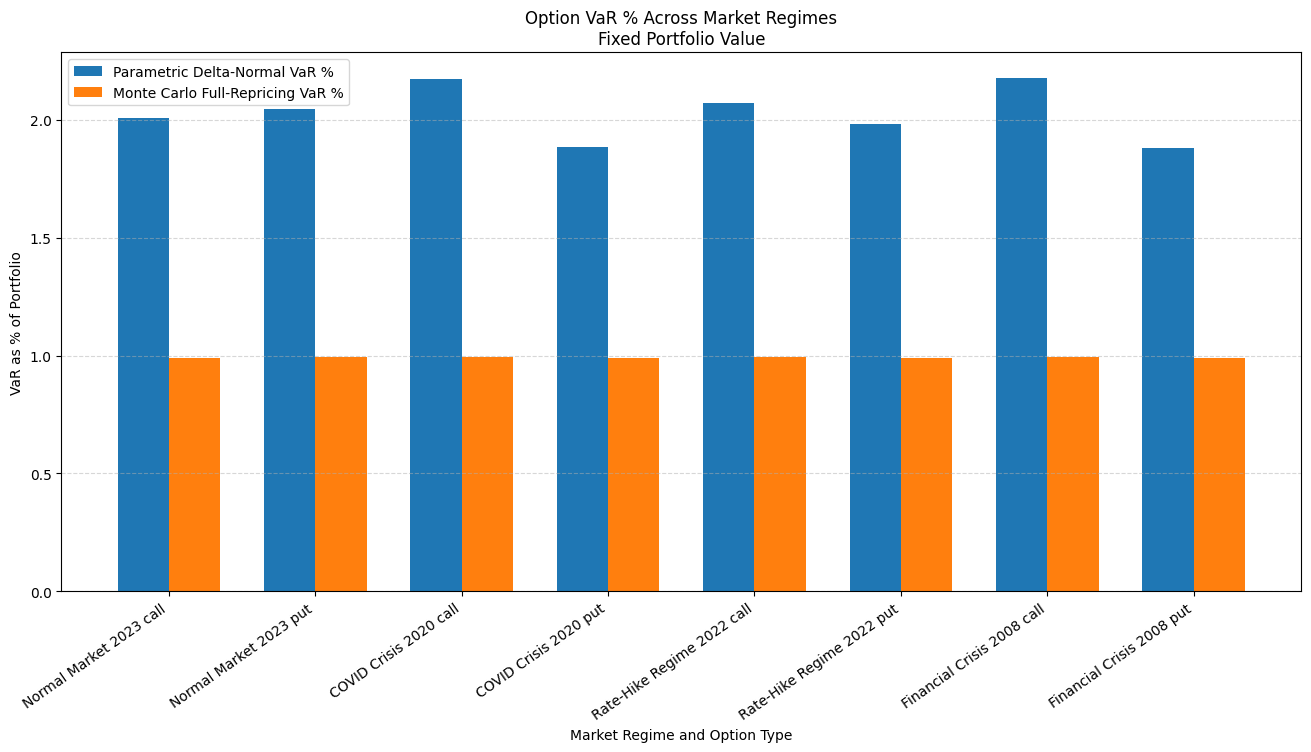

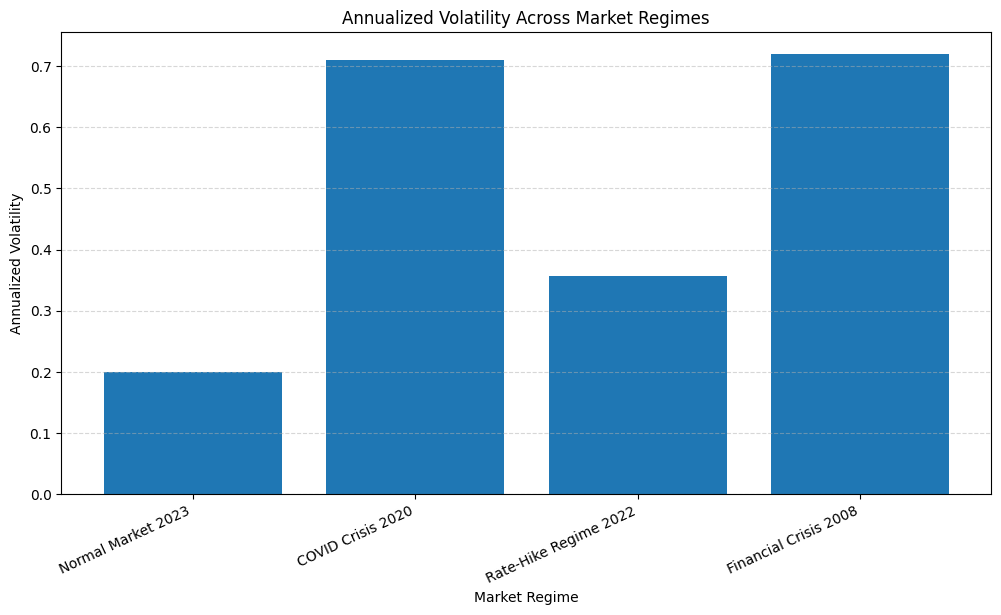

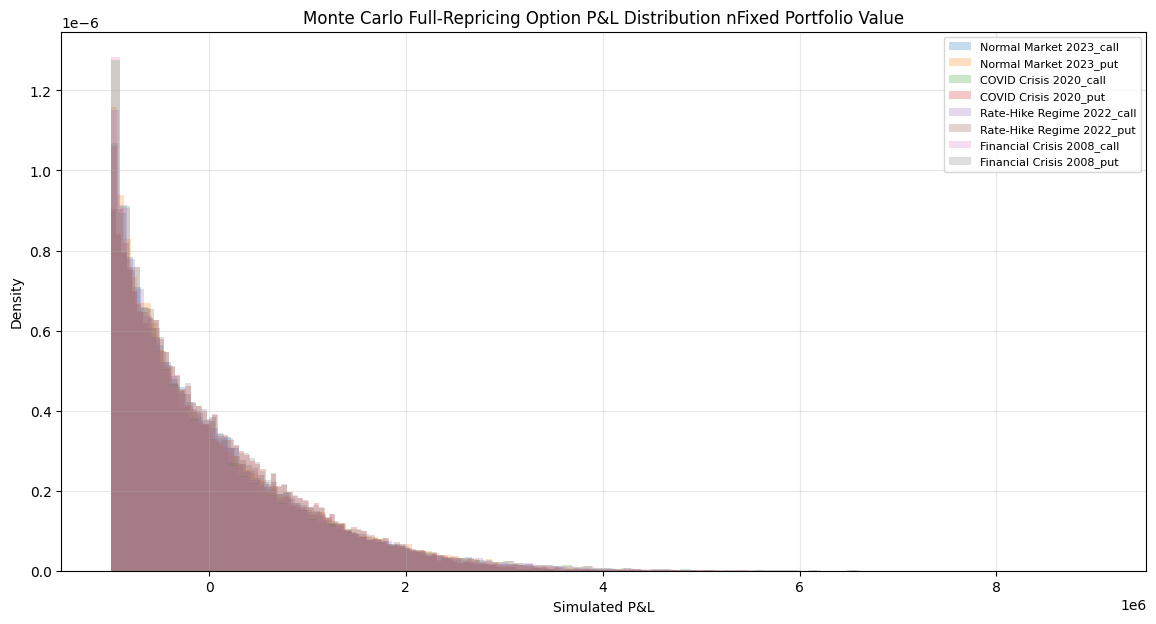

In [ ]:
#working on this
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.monte_carlo_var import monte_carlo_option_var

# Settings
ticker_symbol = "AAPL"

target_portfolio_value = 1_000_000

confidence = 0.99
r = 0.05
horizon_days = 10
n_sim = 50000
T = 30 / 365   # hypothetical 30-day ATM option

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}

results = []
all_pnls = {}

# Black-Scholes Functions

def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def black_scholes_delta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    if option_type == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1



# Run Option VaR by Regime

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    returns = prices.pct_change().dropna()

    daily_sigma = returns.std()
    annual_sigma = daily_sigma * np.sqrt(252)

    S0 = prices.iloc[-1]
    K = S0   # ATM option

    for option_type in ["call", "put"]:

        option_price = black_scholes_price(
            S=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_type=option_type
        )

        delta = black_scholes_delta(
            S=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_type=option_type
        )

        # Fixed portfolio value converted into contracts
        contracts = target_portfolio_value / (option_price * 100)

        portfolio_value = option_price * 100 * contracts

        # ---------------------------------------------------
        # Parametric Delta-Normal Option VaR
        # ---------------------------------------------------

        z = norm.ppf(confidence)

        parametric_option_var = (
            abs(delta)
            * S0
            * annual_sigma
            * np.sqrt(horizon_days / 252)
            * 100
            * contracts
            * z
        )

        # ---------------------------------------------------
        # Monte Carlo Full-Repricing Option VaR
        # ---------------------------------------------------

        mc_result = monte_carlo_option_var(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=annual_sigma,
            option_price=option_price,
            option_type=option_type,
            contracts=contracts,
            n_sim=n_sim,
            confidence=confidence,
            horizon_days=horizon_days
        )

        mc_option_var = max(mc_result["var"], 0)

        results.append({
            "Regime": regime_name,
            "Option_Type": option_type,
            "S0": S0,
            "Strike": K,
            "Option_Price": option_price,
            "Daily_Volatility": daily_sigma,
            "Annualized_Volatility": annual_sigma,
            "Delta": delta,
            "Contracts": contracts,
            "Portfolio_Value": portfolio_value,
            "Parametric_Delta_Normal_VaR": parametric_option_var,
            "Monte_Carlo_Full_Repricing_VaR": mc_option_var,
            "Parametric_VaR_%": parametric_option_var / portfolio_value,
            "Monte_Carlo_VaR_%": mc_option_var / portfolio_value
        })

        all_pnls[f"{regime_name}_{option_type}"] = mc_result["pnl"]


# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

df_results = pd.DataFrame(results)

print(df_results)


# ---------------------------------------------------
# Bar Chart: Parametric vs Monte Carlo VaR
# ---------------------------------------------------

labels = df_results["Regime"] + " " + df_results["Option_Type"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(16, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_Delta_Normal_VaR"],
    width,
    label="Parametric Delta-Normal"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_Full_Repricing_VaR"],
    width,
    label="Monte Carlo Full Repricing"
)

plt.title("Option VaR Across Market Regimes\nFixed $1,000,000 Portfolio Value")
plt.xlabel("Market Regime and Option Type")
plt.ylabel("VaR ($)")
plt.xticks(x, labels, rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ---------------------------------------------------
# Bar Chart: VaR %
# ---------------------------------------------------

plt.figure(figsize=(16, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_VaR_%"],
    width,
    label="Parametric Delta-Normal VaR %"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_VaR_%"],
    width,
    label="Monte Carlo Full-Repricing VaR %"
)

plt.title("Option VaR % Across Market Regimes\nFixed Portfolio Value")
plt.xlabel("Market Regime and Option Type")
plt.ylabel("VaR as % of Portfolio")
plt.xticks(x, labels, rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ---------------------------------------------------
# Volatility Comparison
# ---------------------------------------------------

vol_table = df_results.drop_duplicates("Regime")

plt.figure(figsize=(12, 6))

plt.bar(
    vol_table["Regime"],
    vol_table["Annualized_Volatility"]
)

plt.title("Annualized Volatility Across Market Regimes")
plt.xlabel("Market Regime")
plt.ylabel("Annualized Volatility")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


# ---------------------------------------------------
# Monte Carlo P&L Distribution
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

for label, pnl in all_pnls.items():

    plt.hist(
        pnl,
        bins=100,
        alpha=0.25,
        density=True,
        label=label
    )
plt.title("Monte Carlo Full-Repricing Option P&L Distribution nFixed Portfolio Value")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.show()

#Findings: Long options have bounded downside, and doenes't protrary the complex risk aspects of the market changes. For this reason, we design our risk models based on 
#short option scenes.


In [ ]:
!pip install black_scholes_price

In [ ]:
import os
print(os.getcwd())

/Users/sangpark/Documents/Risk class project/risk-system-main


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                  Regime Position Option_Type          S0      Strike  \
0     Normal Market 2023    short         put  190.375046  190.375046   
1      COVID Crisis 2020    short         put   70.924355   70.924355   
2  Rate-Hike Regime 2022    short         put  127.761597  127.761597   
3  Financial Crisis 2008    short         put    2.673533    2.673533   

   Option_Price  Daily_Volatility  Annualized_Volatility     Delta  Contracts  \
0      3.956119          0.012570               0.199543 -0.459997       1000   
1      5.590366          0.044702               0.709620 -0.451481       1000   
2      4.941841          0.022471               0.356721 -0.463620       1000   
3      0.213846          0.045348               0.719881 -0.451012       1000   

   Portfolio_Value  Parametric_Delta_Normal_VaR  \
0    395611.852666                 8.097989e+05   
1    559036.552848                 1.053016e+06   
2    494184.065357                 9.791863e+05   
3     21384.587307      

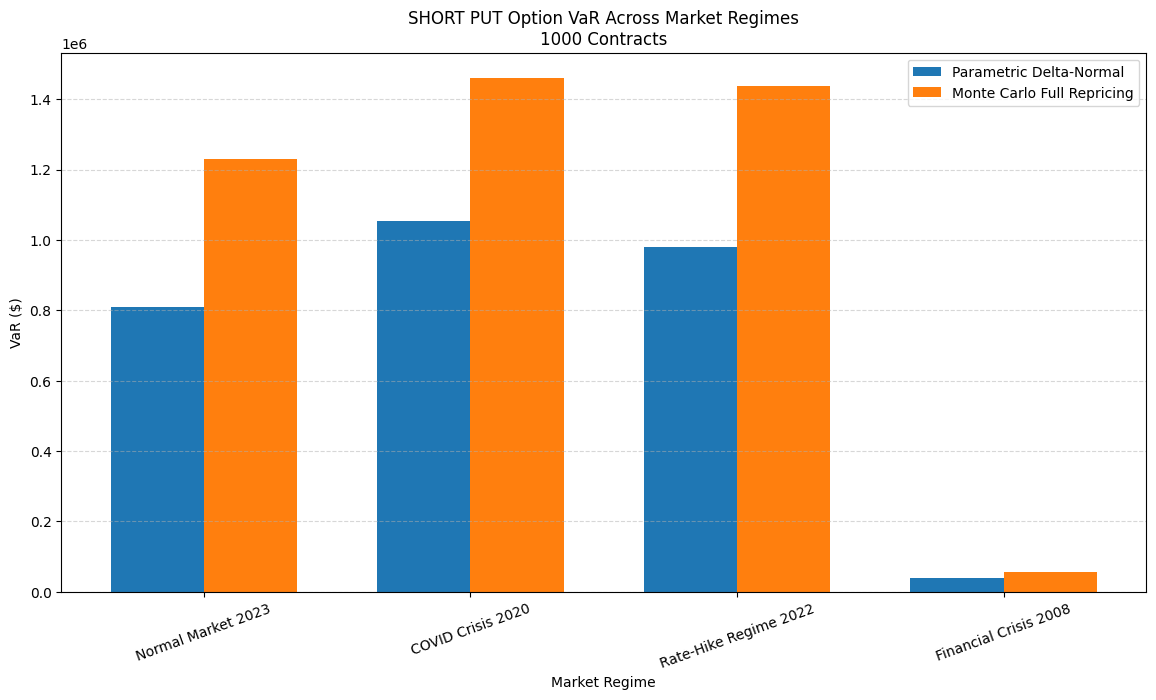

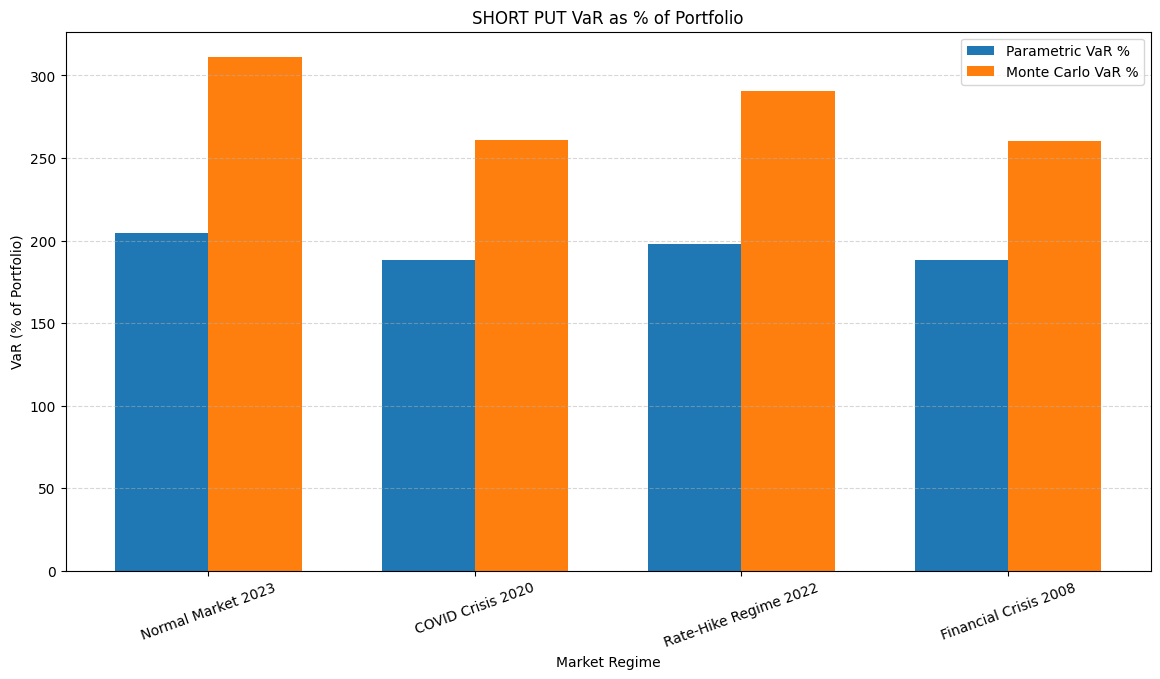

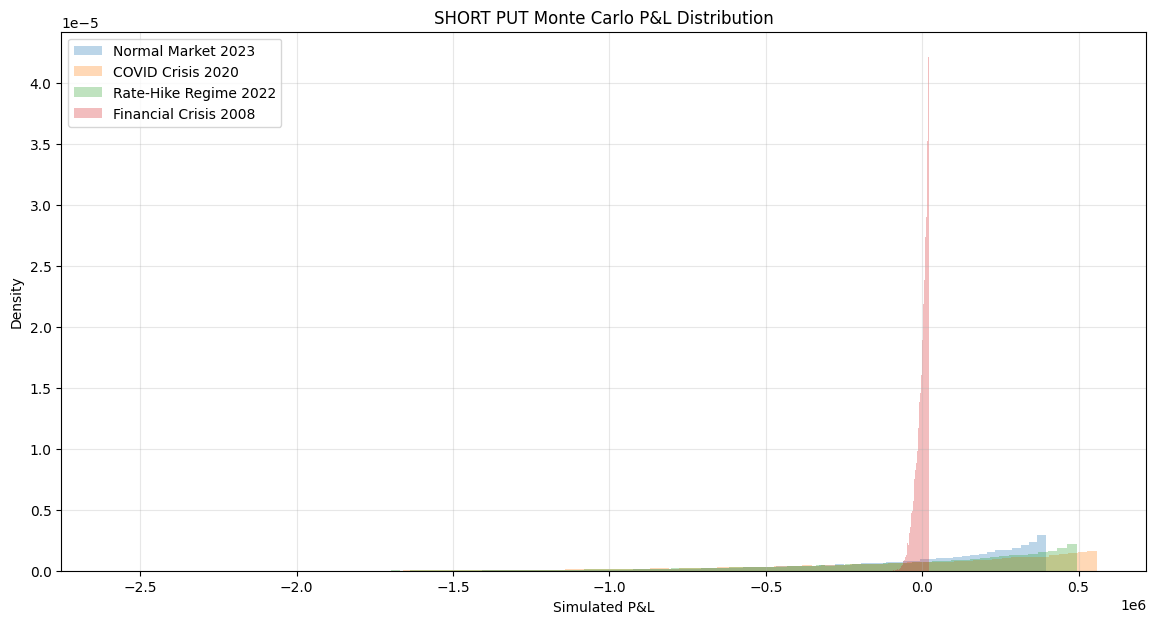

In [66]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.risk.black_scholes_prices import black_scholes_price
from src.risk.monte_carlo_var import monte_carlo_option_var
#Settings
ticker_symbol = "AAPL"
contracts = 1000
confidence = 0.99
r = 0.05
horizon_days = 10
n_sim = 50000
T = 30 / 365
option_type = "put"          # "call" or "put"
position_type = "short"      # "long" or "short"

regimes = {
    "Normal Market 2023": ("2023-01-01", "2024-01-01"),
    "COVID Crisis 2020": ("2020-02-01", "2020-05-01"),
    "Rate-Hike Regime 2022": ("2022-01-01", "2022-12-31"),
    "Financial Crisis 2008": ("2008-09-01", "2009-03-01")
}
results = []
all_pnls = {}

#Run Option VaR by Regime

for regime_name, (start_date, end_date) in regimes.items():

    prices = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=True
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker_symbol]

    returns = prices.pct_change().dropna()

    daily_sigma = returns.std()
    annual_sigma = daily_sigma * np.sqrt(252)

    S0 = prices.iloc[-1]
    K = S0

    option_price = black_scholes_price(
        S=S0,
        K=K,
        T=T,
        r=r,
        sigma=annual_sigma,
        option_type=option_type
    )
    # Delta calculation
    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * annual_sigma**2) * T
    ) / (annual_sigma * np.sqrt(T))

    if option_type == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1
    # Parametric Delta-Normal VaR
    z = norm.ppf(confidence)
    parametric_var = (
        abs(delta)
        * S0
        * annual_sigma
        * np.sqrt(horizon_days / 252)
        * 100
        * contracts
        * z
    )
    # Monte Carlo Full-Repricing VaR
    mc_result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=annual_sigma,
        option_price=option_price,
        option_type=option_type,
        contracts=contracts,
        n_sim=n_sim,
        confidence=confidence,
        horizon_days=horizon_days
    )

    long_pnl = mc_result["pnl"]

    if position_type == "long":
        pnl = long_pnl
    else:
        pnl = -long_pnl

    mc_var = -np.percentile(
        pnl,
        (1 - confidence) * 100
    )

    portfolio_value = option_price * 100 * contracts

    results.append({
        "Regime": regime_name,
        "Position": position_type,
        "Option_Type": option_type,
        "S0": S0,
        "Strike": K,
        "Option_Price": option_price,
        "Daily_Volatility": daily_sigma,
        "Annualized_Volatility": annual_sigma,
        "Delta": delta,
        "Contracts": contracts,
        "Portfolio_Value": portfolio_value,
        "Parametric_Delta_Normal_VaR": parametric_var,
        "Monte_Carlo_Full_Repricing_VaR": mc_var,
        "Parametric_VaR_%": parametric_var / portfolio_value,
        "Monte_Carlo_VaR_%": mc_var / portfolio_value
    })

    all_pnls[regime_name] = pnl

# Results Table

df_results = pd.DataFrame(results)

print(df_results)

# VaR Comparison Chart

labels = df_results["Regime"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_Delta_Normal_VaR"],
    width,
    label="Parametric Delta-Normal"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_Full_Repricing_VaR"],
    width,
    label="Monte Carlo Full Repricing"
)

plt.title(
    f"{position_type.upper()} {option_type.upper()} Option VaR Across Market Regimes\n"
    f"{contracts} Contracts"
)

plt.xlabel("Market Regime")
plt.ylabel("VaR ($)")
plt.xticks(x, labels, rotation=20)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ---------------------------------------------------
# VaR Percentage Chart
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    df_results["Parametric_VaR_%"] * 100,
    width,
    label="Parametric VaR %"
)

plt.bar(
    x + width / 2,
    df_results["Monte_Carlo_VaR_%"] * 100,
    width,
    label="Monte Carlo VaR %"
)

plt.title(
    f"{position_type.upper()} {option_type.upper()} VaR as % of Portfolio"
)

plt.xlabel("Market Regime")
plt.ylabel("VaR (% of Portfolio)")
plt.xticks(x, labels, rotation=20)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ---------------------------------------------------
# Monte Carlo P&L Distribution
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

for label, pnl in all_pnls.items():

    plt.hist(
        pnl,
        bins=100,
        alpha=0.30,
        density=True,
        label=label
    )

plt.title(
    f"{position_type.upper()} {option_type.upper()} Monte Carlo P&L Distribution"
)

plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Historical ES => for option ES. Starting with put. 

('2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-26', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
Selected Option:
contractSymbol             AAPL260522C00295000
lastTradeDate        2026-05-12 19:59:47+00:00
strike                                   295.0
lastPrice                                 4.86
bid                                       4.75
ask                                        5.0
change                                    0.72
percentChange                        17.391312
volume                                  4403.0
openInterest                              3374
impliedVolatility                     0.261848
inTheMoney                               False
contractSize                           REGULAR
currency                           

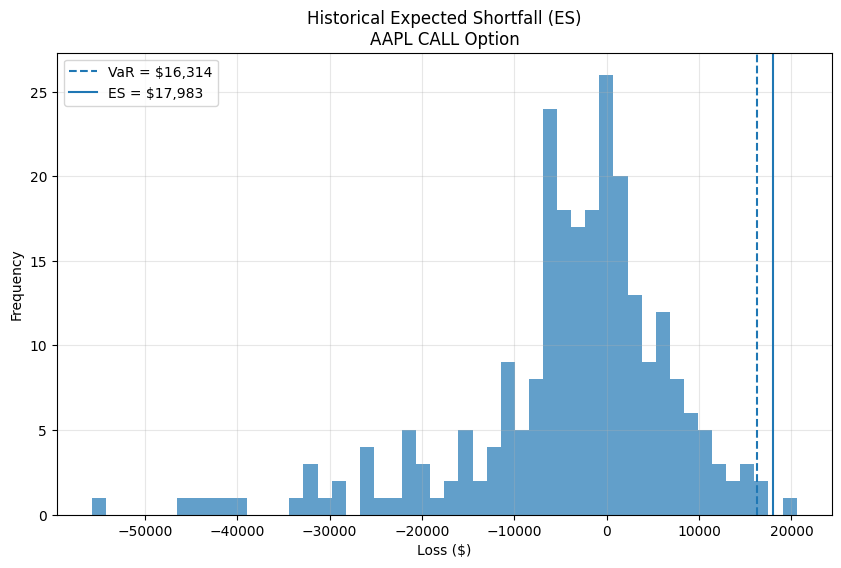

In [68]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.risk.black_scholes_prices import black_scholes_price

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"
option_type = "call"      # "call" or "put"
contracts = 50
confidence = 0.99
r = 0.05

ticker = yf.Ticker(ticker_symbol)

# ---------------------------------------------------
# Stock data
# ---------------------------------------------------

stock_hist = ticker.history(period="1y")

S0 = stock_hist["Close"].iloc[-1]

# Historical returns
returns = stock_hist["Close"].pct_change().dropna()

# ---------------------------------------------------
# Option chain
# ---------------------------------------------------

print(ticker.options)

exp = ticker.options[4]

chain = ticker.option_chain(exp)

if option_type == "call":
    options = chain.calls
else:
    options = chain.puts

# ATM option
closest_idx = (options["strike"] - S0).abs().idxmin()
option = options.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# ---------------------------------------------------
# Time to maturity
# ---------------------------------------------------

expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

days_to_exp = max((expiration_date - today).days, 1)
T = days_to_exp / 365

# ---------------------------------------------------
# Current portfolio value
# ---------------------------------------------------

portfolio_value = option_price * 100 * contracts

# ---------------------------------------------------
# Historical Repricing
# ---------------------------------------------------

simulated_option_values = []

for ret in returns:

    # Simulated stock price using historical return
    simulated_S = S0 * (1 + ret)

    # Reprice option
    repriced_option = black_scholes_price(
        S=simulated_S,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_type=option_type
    )

    simulated_option_values.append(
        repriced_option * 100 * contracts
    )

simulated_option_values = np.array(simulated_option_values)

# ---------------------------------------------------
# Profit / Loss Distribution
# ---------------------------------------------------

pnl = simulated_option_values - portfolio_value

losses = -pnl

# ---------------------------------------------------
# Historical VaR
# ---------------------------------------------------

historical_var = np.percentile(
    losses,
    confidence * 100
)

# ---------------------------------------------------
# Historical Expected Shortfall (ES)
# ---------------------------------------------------

tail_losses = losses[losses >= historical_var]

historical_es = tail_losses.mean()

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("Selected Option:")
print(option)

print("\nS0:", S0)
print("Strike:", K)
print("Expiration:", exp)
print("Option Price:", option_price)
print("Implied Volatility:", sigma)
print("Contracts:", contracts)

print(f"\nHistorical {int(confidence*100)}% VaR: ${historical_var:,.2f}")
print(f"Historical {int(confidence*100)}% ES : ${historical_es:,.2f}")

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    losses,
    bins=50,
    alpha=0.7
)

plt.axvline(
    historical_var,
    linestyle="--",
    label=f"VaR = ${historical_var:,.0f}"
)

plt.axvline(
    historical_es,
    linestyle="-",
    label=f"ES = ${historical_es:,.0f}"
)

plt.title(
    f"Historical Expected Shortfall (ES)\n{ticker_symbol} {option_type.upper()} Option"
)

plt.xlabel("Loss ($)")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)
plt.show()

#Realistic Historical Expected Shortfall (ES)
#Taking historical AAPL returns 
#simulating how the stock would rise. 
#repricing the call option using black-scholes. 

[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Current Price: $294.80
Shares: 100
Portfolio Value: $29,480.00

Historical 99% VaR: $985.03
Historical 99% ES : $1,169.96


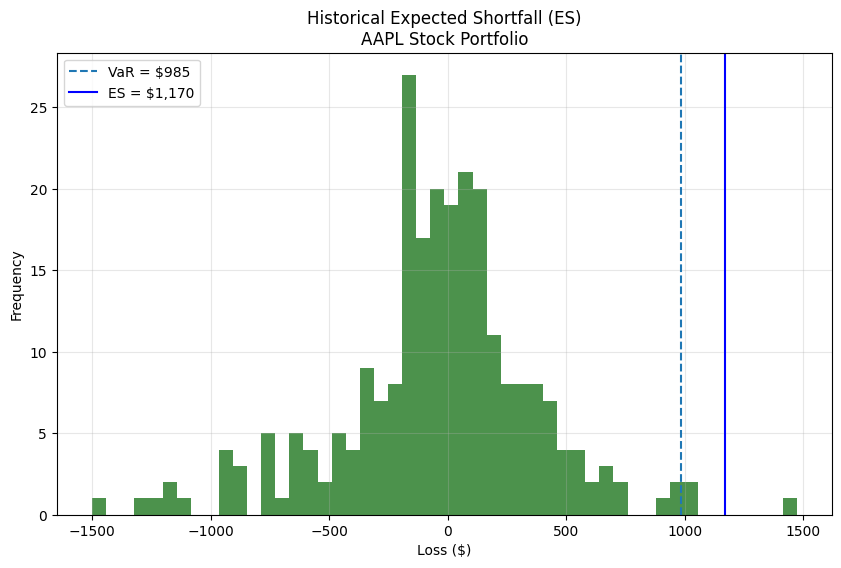

In [69]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"

shares = 100

confidence = 0.99

# ---------------------------------------------------
# Download stock data
# ---------------------------------------------------

prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]

# Convert dataframe -> series if needed
if isinstance(prices, pd.DataFrame):
    prices = prices[ticker]

# ---------------------------------------------------
# Historical returns
# ---------------------------------------------------

returns = prices.pct_change().dropna()

# ---------------------------------------------------
# Current portfolio value
# ---------------------------------------------------

current_price = prices.iloc[-1]

portfolio_value = current_price * shares

# ---------------------------------------------------
# Historical P&L distribution
# ---------------------------------------------------

historical_pnl = portfolio_value * returns

# Convert to losses
losses = -historical_pnl

# ---------------------------------------------------
# Historical VaR
# ---------------------------------------------------

historical_var = np.percentile(
    losses,
    confidence * 100
)

# ---------------------------------------------------
# Historical Expected Shortfall (ES)
# ---------------------------------------------------

tail_losses = losses[losses >= historical_var]

historical_es = tail_losses.mean()

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print(f"Ticker: {ticker}")
print(f"Current Price: ${current_price:,.2f}")
print(f"Shares: {shares}")
print(f"Portfolio Value: ${portfolio_value:,.2f}")

print(f"\nHistorical {int(confidence*100)}% VaR: ${historical_var:,.2f}")
print(f"Historical {int(confidence*100)}% ES : ${historical_es:,.2f}")

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    losses,
    bins=50,
    alpha=0.7,
    color = "darkgreen"
)

plt.axvline(
    historical_var,
    linestyle="--",
    label=f"VaR = ${historical_var:,.0f}"
)

plt.axvline(
    historical_es,
    linestyle="-",
    label=f"ES = ${historical_es:,.0f}",
    color = "blue"
)

plt.title(
    f"Historical Expected Shortfall (ES)\n{ticker} Stock Portfolio"
)

plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [70]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
n_sim = 10000

regimes = {
    "Dot-com Bubble / Crash": ("2000-03-01", "2002-10-31"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "COVID Recession": ("2020-02-01", "2020-06-30"),
    "2022-2023 Rate Hikes": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# VaR / CVaR Functions
# ---------------------------------------------------

def historical_var_cvar(losses, confidence=0.99):
    var = np.percentile(losses, confidence * 100)
    cvar = losses[losses >= var].mean()
    return var, cvar


def parametric_var_cvar(returns, portfolio_value, confidence=0.99):
    mu = returns.mean()
    sigma = returns.std()

    z = norm.ppf(confidence)

    var = portfolio_value * (z * sigma - mu)

    cvar = portfolio_value * (
        sigma * norm.pdf(z) / (1 - confidence) - mu
    )

    return var, cvar


def monte_carlo_var_cvar(returns, portfolio_value, confidence=0.99, n_sim=10000):
    mu = returns.mean()
    sigma = returns.std()

    simulated_returns = np.random.normal(
        loc=mu,
        scale=sigma,
        size=n_sim
    )

    simulated_losses = -portfolio_value * simulated_returns

    var = np.percentile(simulated_losses, confidence * 100)
    cvar = simulated_losses[simulated_losses >= var].mean()

    return var, cvar


def breach_rate(losses, var):
    return (losses > var).mean()


# ---------------------------------------------------
# Regime Testing
# ---------------------------------------------------

results = []

for regime_name, (start_date, end_date) in regimes.items():

    print(f"Testing: {regime_name}")

    prices = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )["Close"]

    # Convert DataFrame to Series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    returns = prices.pct_change().dropna()

    current_price = prices.iloc[-1]
    portfolio_value = current_price * shares

    # Actual historical losses
    losses = -portfolio_value * returns

    # Historical VaR / CVaR
    hist_var, hist_cvar = historical_var_cvar(
        losses,
        confidence
    )

    # Parametric VaR / CVaR
    param_var, param_cvar = parametric_var_cvar(
        returns,
        portfolio_value,
        confidence
    )

    # Monte Carlo VaR / CVaR
    mc_var, mc_cvar = monte_carlo_var_cvar(
        returns,
        portfolio_value,
        confidence,
        n_sim
    )

    results.append({
        "Regime": regime_name,

        "Historical VaR": hist_var,
        "Historical CVaR": hist_cvar,
        "Historical Breach Rate": breach_rate(losses, hist_var),

        "Parametric VaR": param_var,
        "Parametric CVaR": param_cvar,
        "Parametric Breach Rate": breach_rate(losses, param_var),

        "Monte Carlo VaR": mc_var,
        "Monte Carlo CVaR": mc_cvar,
        "Monte Carlo Breach Rate": breach_rate(losses, mc_var),
    })


# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

results_df = pd.DataFrame(results)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("\nVaR / CVaR Regime Test Results:")
print(results_df)

Testing: Dot-com Bubble / Crash
Testing: 2008 Financial Crisis
Testing: COVID Recession
Testing: 2022-2023 Rate Hikes

VaR / CVaR Regime Test Results:
                   Regime  Historical VaR  Historical CVaR  \
0  Dot-com Bubble / Crash          1.9580           4.4421   
1   2008 Financial Crisis         26.1285          36.2300   
2         COVID Recession        863.0868         995.6939   
3    2022-2023 Rate Hikes        914.3921       1,034.7848   

   Historical Breach Rate  Parametric VaR  Parametric CVaR  \
0                  0.0105          2.4338           2.7847   
1                  0.0106         25.2287          28.8820   
2                  0.0196        715.9680         823.1361   
3                  0.0100        805.4179         923.5768   

   Parametric Breach Rate  Monte Carlo VaR  Monte Carlo CVaR  \
0                  0.0075           2.4149            2.7660   
1                  0.0133          25.9041           29.9401   
2                  0.0196         7

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Normal Period
VaR: $687.58
ES : $727.45

Stress Period
VaR: $806.02
ES : $990.06


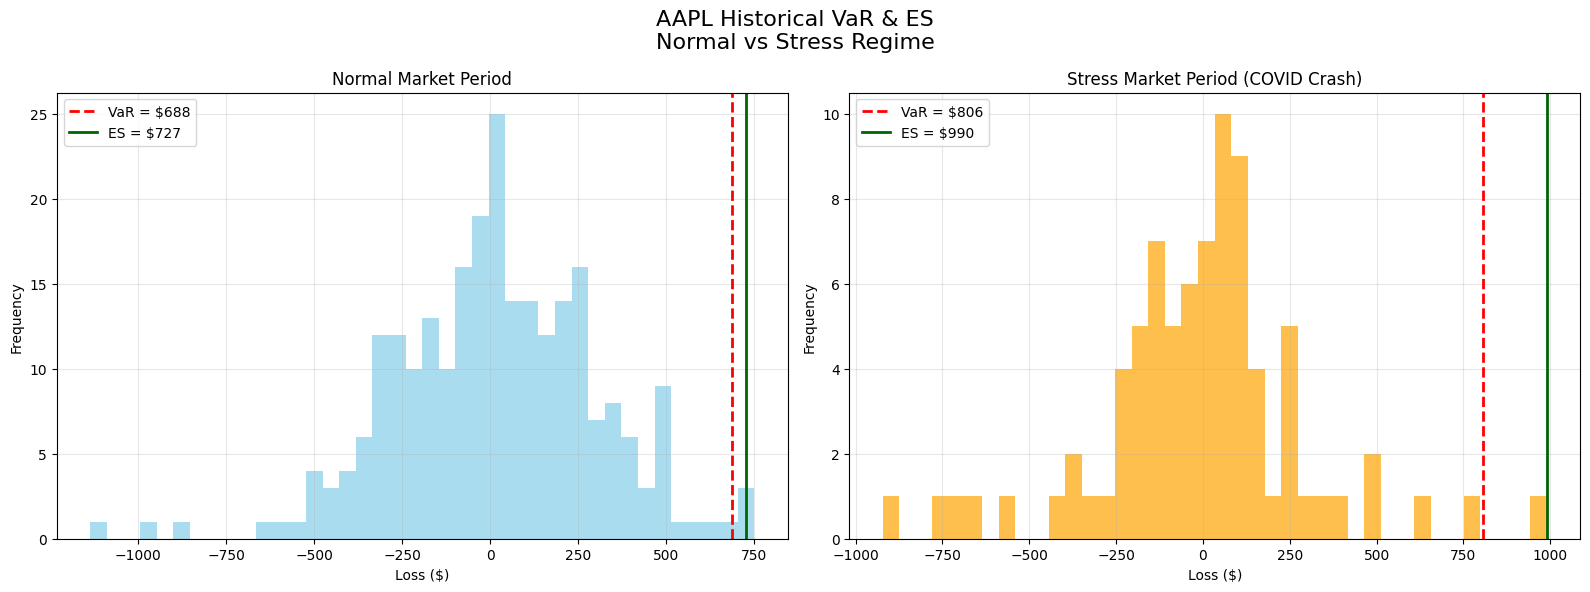

In [71]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99

# ---------------------------------------------------
# Function
# ---------------------------------------------------

def compute_var_es(prices, shares, confidence):

    returns = prices.pct_change().dropna()

    current_price = prices.iloc[-1]

    portfolio_value = current_price * shares

    pnl = portfolio_value * returns

    losses = -pnl

    var = np.percentile(
        losses,
        confidence * 100
    )

    tail_losses = losses[losses >= var]

    es = tail_losses.mean()

    return losses, var, es

# ---------------------------------------------------
# Normal period
# ---------------------------------------------------

normal_prices = yf.download(
    ticker,
    start="2022-01-01",
    end="2022-12-31",
    auto_adjust=True
)["Close"]

if isinstance(normal_prices, pd.DataFrame):
    normal_prices = normal_prices[ticker]

normal_losses, normal_var, normal_es = compute_var_es(
    normal_prices,
    shares,
    confidence
)

# ---------------------------------------------------
# Stress period (COVID crash)
# ---------------------------------------------------

stress_prices = yf.download(
    ticker,
    start="2020-02-01",
    end="2020-06-01",
    auto_adjust=True
)["Close"]

if isinstance(stress_prices, pd.DataFrame):
    stress_prices = stress_prices[ticker]

stress_losses, stress_var, stress_es = compute_var_es(
    stress_prices,
    shares,
    confidence
)

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("Normal Period")
print(f"VaR: ${normal_var:,.2f}")
print(f"ES : ${normal_es:,.2f}")

print("\nStress Period")
print(f"VaR: ${stress_var:,.2f}")
print(f"ES : ${stress_es:,.2f}")

# ---------------------------------------------------
# Visualization
# ---------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

# ---------------------------------------------------
# Normal Period Graph
# ---------------------------------------------------

axes[0].hist(
    normal_losses,
    bins=40,
    alpha=0.7,
    color="skyblue"
)

axes[0].axvline(
    normal_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"VaR = ${normal_var:,.0f}"
)

axes[0].axvline(
    normal_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"ES = ${normal_es:,.0f}"
)

axes[0].set_title("Normal Market Period")

axes[0].set_xlabel("Loss ($)")
axes[0].set_ylabel("Frequency")

axes[0].legend()

axes[0].grid(alpha=0.3)

# ---------------------------------------------------
# Stress Period Graph
# ---------------------------------------------------

axes[1].hist(
    stress_losses,
    bins=40,
    alpha=0.7,
    color="orange"
)

axes[1].axvline(
    stress_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"VaR = ${stress_var:,.0f}"
)

axes[1].axvline(
    stress_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"ES = ${stress_es:,.0f}"
)

axes[1].set_title("Stress Market Period (COVID Crash)")

axes[1].set_xlabel("Loss ($)")
axes[1].set_ylabel("Frequency")

axes[1].legend()

axes[1].grid(alpha=0.3)

# ---------------------------------------------------
# Final Layout
# ---------------------------------------------------

plt.suptitle(
    f"{ticker} Historical VaR & ES\nNormal vs Stress Regime",
    fontsize=16
)

plt.tight_layout()

plt.show()

[*********************100%***********************]  1 of 1 completed

Ticker: AAPL
Current Price: 294.79998779296875
Shares: 100
Portfolio Value: 29479.998779296875

             Method  Risk Value
0   Historical VaR    985.0267
1    Historical ES  1,169.9573
2   Parametric VaR  3,077.4514
3  Monte Carlo VaR  2,675.7399


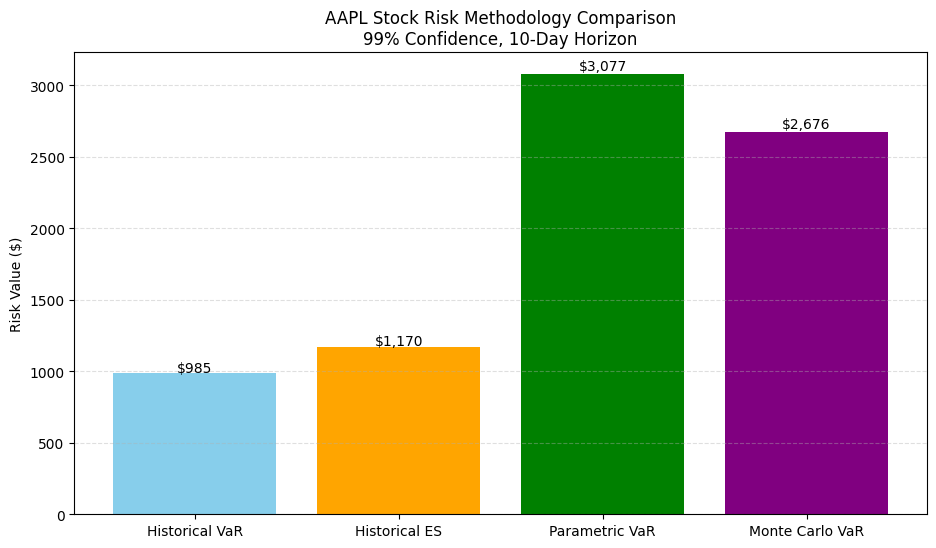

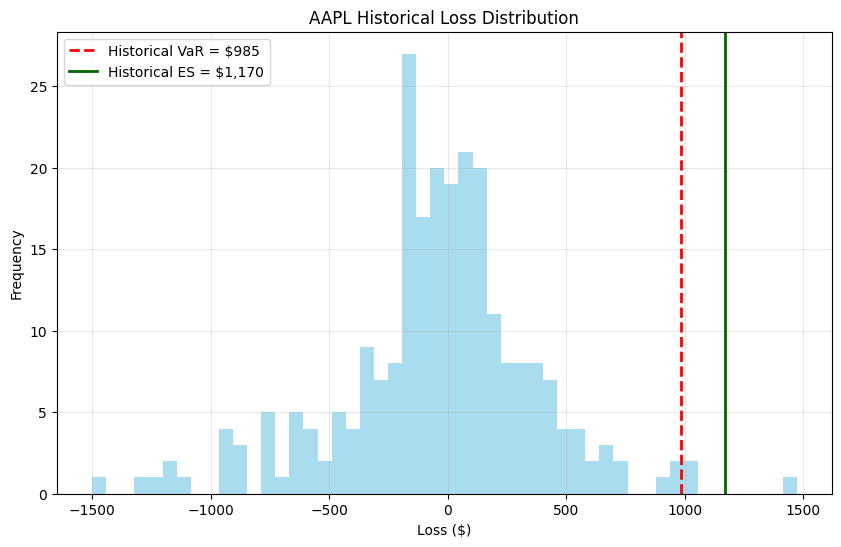

In [72]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
horizon_days = 10
n_sim = 50000

# ---------------------------------------------------
# Download stock data
# ---------------------------------------------------

prices = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=True
)["Close"]

if isinstance(prices, pd.DataFrame):
    prices = prices[ticker]

# ---------------------------------------------------
# Returns
# ---------------------------------------------------

returns = prices.pct_change().dropna()

mu = returns.mean()
sigma = returns.std()

current_price = prices.iloc[-1]
portfolio_value = current_price * shares

# ---------------------------------------------------
# 1. Historical VaR and ES
# ---------------------------------------------------

historical_pnl = portfolio_value * returns
historical_losses = -historical_pnl

historical_var = np.percentile(
    historical_losses,
    confidence * 100
)

tail_losses = historical_losses[historical_losses >= historical_var]

historical_es = tail_losses.mean()

# ---------------------------------------------------
# 2. Parametric VaR
# ---------------------------------------------------

z = norm.ppf(confidence)

parametric_var = (
    portfolio_value
    * sigma
    * np.sqrt(horizon_days)
    * z
)

# ---------------------------------------------------
# 3. Monte Carlo VaR
# ---------------------------------------------------

simulated_returns = np.random.normal(
    loc=mu * horizon_days,
    scale=sigma * np.sqrt(horizon_days),
    size=n_sim
)

simulated_prices = current_price * (1 + simulated_returns)

simulated_values = simulated_prices * shares

mc_pnl = simulated_values - portfolio_value

mc_losses = -mc_pnl

mc_var = np.percentile(
    mc_losses,
    confidence * 100
)

# ---------------------------------------------------
# Results table
# ---------------------------------------------------

comparison_df = pd.DataFrame({
    "Method": [
        "Historical VaR",
        "Historical ES",
        "Parametric VaR",
        "Monte Carlo VaR"
    ],
    "Risk Value": [
        historical_var,
        historical_es,
        parametric_var,
        mc_var
    ]
})

print("Ticker:", ticker)
print("Current Price:", current_price)
print("Shares:", shares)
print("Portfolio Value:", portfolio_value)
print("\n", comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.bar(
    comparison_df["Method"],
    comparison_df["Risk Value"],
    color=["skyblue", "orange", "green", "purple"]
)

for bar, val in zip(bars, comparison_df["Risk Value"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.01,
        f"${val:,.0f}",
        ha="center"
    )

plt.title(
    f"{ticker} Stock Risk Methodology Comparison\n"
    f"{int(confidence*100)}% Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("Risk Value ($)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# ---------------------------------------------------
# Loss distribution graph
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    historical_losses,
    bins=50,
    alpha=0.7,
    color="skyblue"
)

plt.axvline(
    historical_var,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Historical VaR = ${historical_var:,.0f}"
)

plt.axvline(
    historical_es,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"Historical ES = ${historical_es:,.0f}"
)

plt.title(f"{ticker} Historical Loss Distribution")
plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Risk Methodology Comparison

                      Regime  Historical VaR  Historical ES  Parametric VaR  \
0  Normal Market (2023-2024)        533.3568       717.4795      1,760.4426   
1        COVID Crisis (2020)        806.0210       990.0629      2,219.7341   

   Monte Carlo VaR  
0       1,415.2798  
1       2,127.8702  


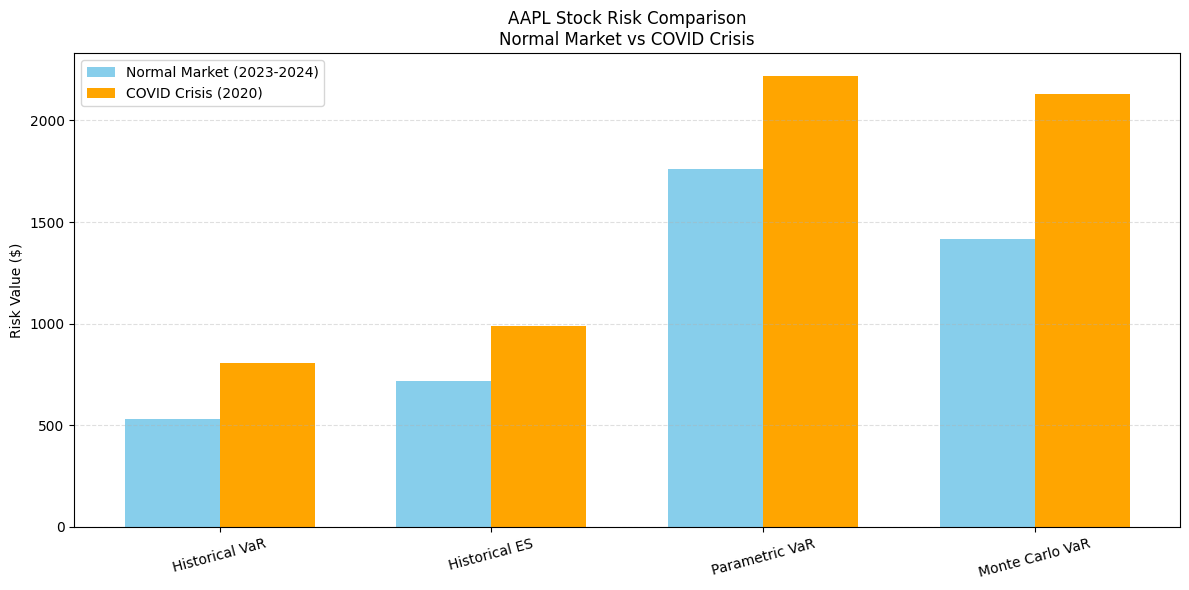

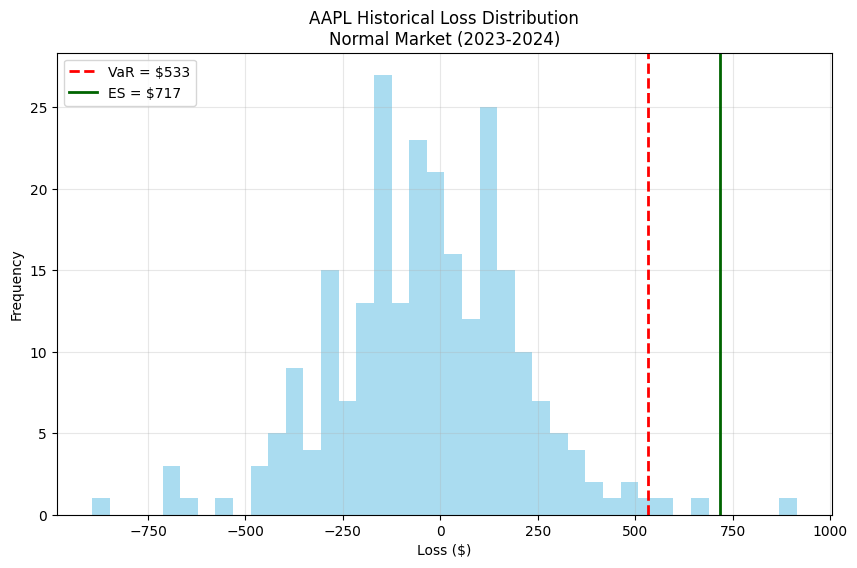

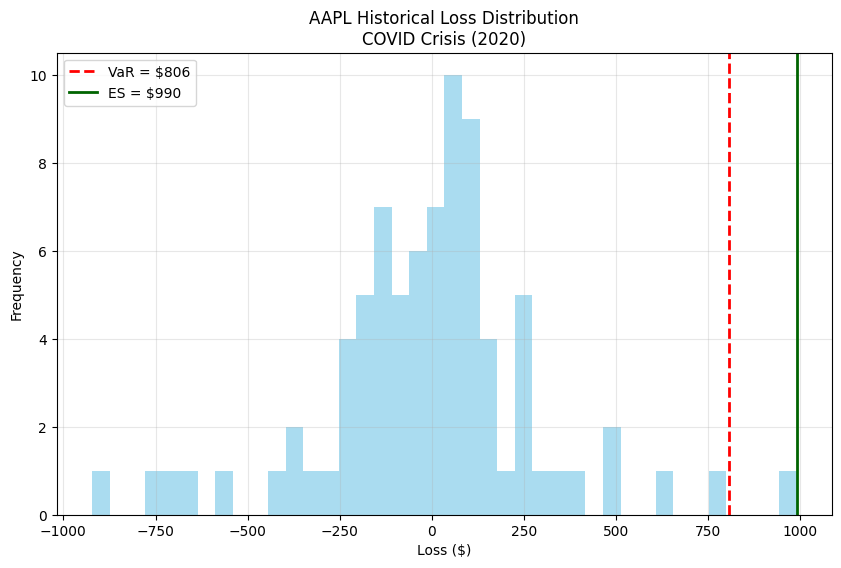

In [73]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
shares = 100
confidence = 0.99
horizon_days = 10
n_sim = 50000

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    )
}

# ---------------------------------------------------
# Risk computation function
# ---------------------------------------------------

def compute_stock_risk(
    prices,
    shares,
    confidence,
    horizon_days,
    n_sim
):

    # ---------------------------------------------
    # Returns
    # ---------------------------------------------

    returns = prices.pct_change().dropna()

    mu = returns.mean()
    sigma = returns.std()

    # ---------------------------------------------
    # Portfolio value
    # ---------------------------------------------

    current_price = prices.iloc[-1]

    portfolio_value = current_price * shares

    # ---------------------------------------------
    # Historical VaR / ES
    # ---------------------------------------------

    historical_pnl = portfolio_value * returns

    historical_losses = -historical_pnl

    historical_var = np.percentile(
        historical_losses,
        confidence * 100
    )

    tail_losses = historical_losses[
        historical_losses >= historical_var
    ]

    historical_es = tail_losses.mean()

    # ---------------------------------------------
    # Parametric VaR
    # ---------------------------------------------

    z = norm.ppf(confidence)

    parametric_var = (
        portfolio_value
        * sigma
        * np.sqrt(horizon_days)
        * z
    )

    # ---------------------------------------------
    # Monte Carlo VaR
    # ---------------------------------------------

    simulated_returns = np.random.normal(
        loc=mu * horizon_days,
        scale=sigma * np.sqrt(horizon_days),
        size=n_sim
    )

    simulated_prices = current_price * (
        1 + simulated_returns
    )

    simulated_values = simulated_prices * shares

    mc_pnl = simulated_values - portfolio_value

    mc_losses = -mc_pnl

    mc_var = np.percentile(
        mc_losses,
        confidence * 100
    )

    # ---------------------------------------------
    # Return results
    # ---------------------------------------------
    
    return {
        "Portfolio Value": portfolio_value,
        "Historical VaR": historical_var,
        "Historical ES": historical_es,
        "Parametric VaR": parametric_var,
        "Monte Carlo VaR": mc_var,
        "Losses": historical_losses
    }

# ---------------------------------------------------
# Run each market regime
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True
    )["Close"]

    # Convert dataframe -> series if needed
    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    results[regime_name] = compute_stock_risk(
        prices,
        shares,
        confidence,
        horizon_days,
        n_sim
    )

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "Historical VaR": data["Historical VaR"],
        "Historical ES": data["Historical ES"],
        "Parametric VaR": data["Parametric VaR"],
        "Monte Carlo VaR": data["Monte Carlo VaR"]
    }
    for regime, data in results.items()
])

print("\nRisk Methodology Comparison\n")

print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

methods = [
    "Historical VaR",
    "Historical ES",
    "Parametric VaR",
    "Monte Carlo VaR"
]

x = np.arange(len(methods))

width = 0.35

plt.figure(figsize=(12, 6))

# Normal regime
plt.bar(
    x - width/2,
    comparison_df.loc[0, methods],
    width,
    label=comparison_df.loc[0, "Regime"],
    color="skyblue"
)

# Crisis regime
plt.bar(
    x + width/2,
    comparison_df.loc[1, methods],
    width,
    label=comparison_df.loc[1, "Regime"],
    color="orange"
)

# ---------------------------------------------
# Formatting
# ---------------------------------------------

plt.xticks(
    x,
    methods,
    rotation=15
)

plt.ylabel("Risk Value ($)")

plt.title(
    f"{ticker} Stock Risk Comparison\n"
    "Normal Market vs COVID Crisis"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------
# Histogram graphs
# ---------------------------------------------------

for regime, data in results.items():

    losses = data["Losses"]

    plt.figure(figsize=(10, 6))

    # ---------------------------------------------
    # Histogram
    # ---------------------------------------------

    plt.hist(
        losses,
        bins=40,
        alpha=0.7,
        color="skyblue"
    )

    # ---------------------------------------------
    # VaR line
    # ---------------------------------------------

    plt.axvline(
        data["Historical VaR"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${data['Historical VaR']:,.0f}"
    )

    # ---------------------------------------------
    # ES line
    # ---------------------------------------------

    plt.axvline(
        data["Historical ES"],
        color="darkgreen",
        linestyle="-",
        linewidth=2,
        label=f"ES = ${data['Historical ES']:,.0f}"
    )

    # ---------------------------------------------
    # Formatting
    # ---------------------------------------------

    plt.title(
        f"{ticker} Historical Loss Distribution\n{regime}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()


Risk Methodology Comparison
                         Regime  Current Price  Shares Used  Portfolio Value  \
0     Normal Market (2023-2024)         190.38       525.28           100000   
1           COVID Crisis (2020)          76.96     1,299.38           100000   
2         2008 Financial Crisis           3.13    31,969.78           100000   
3  Rate-Hike Regime (2022-2023)         190.38       525.28           100000   

   Historical VaR  Historical ES  Parametric VaR  Monte Carlo VaR  
0        2,801.61       3,768.77        9,247.23         7,205.14  
1       10,473.30      12,864.71       28,842.85        24,722.98  
2        8,353.21      11,582.65       25,355.40        23,311.70  
3        4,803.11       5,435.51       13,474.19        12,496.30  


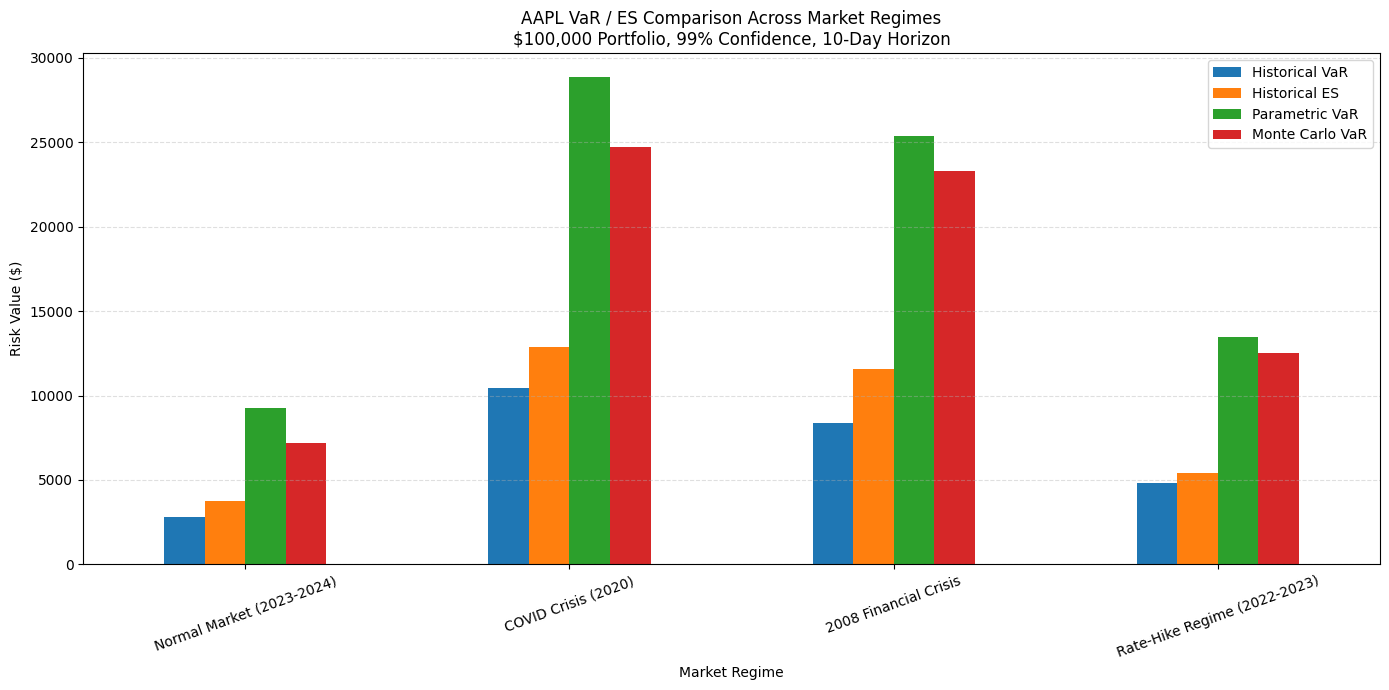

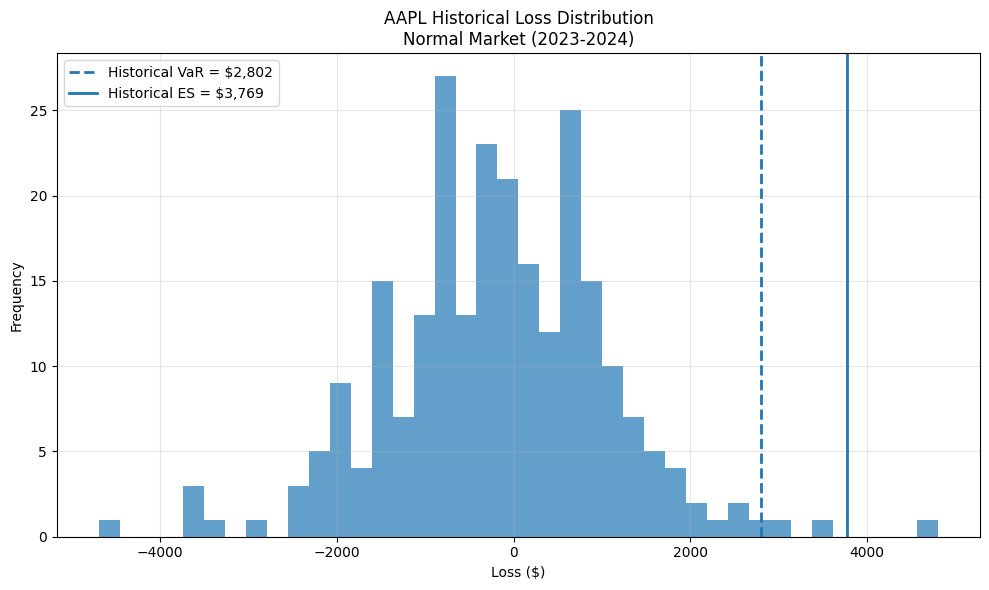

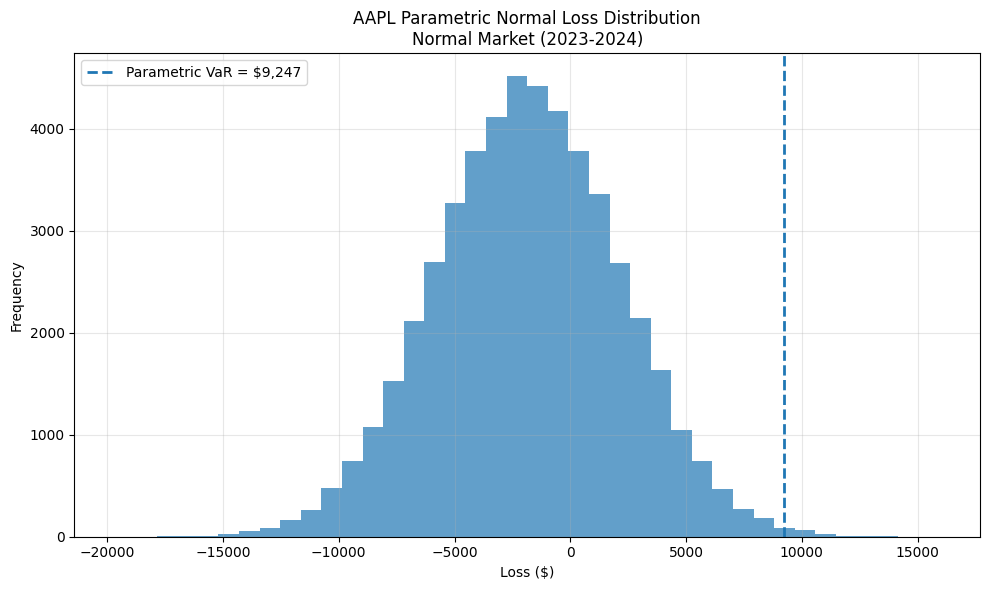

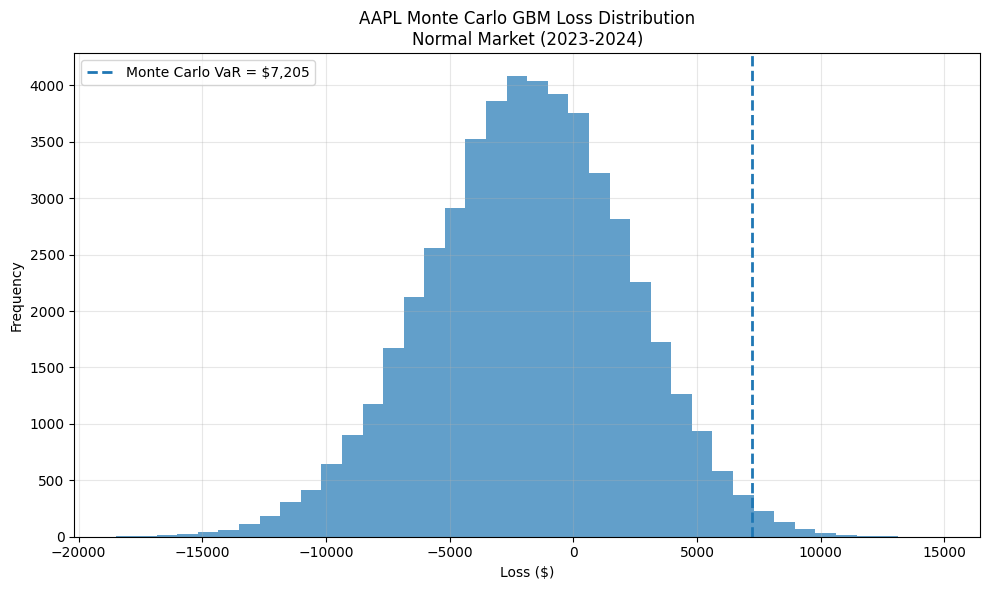

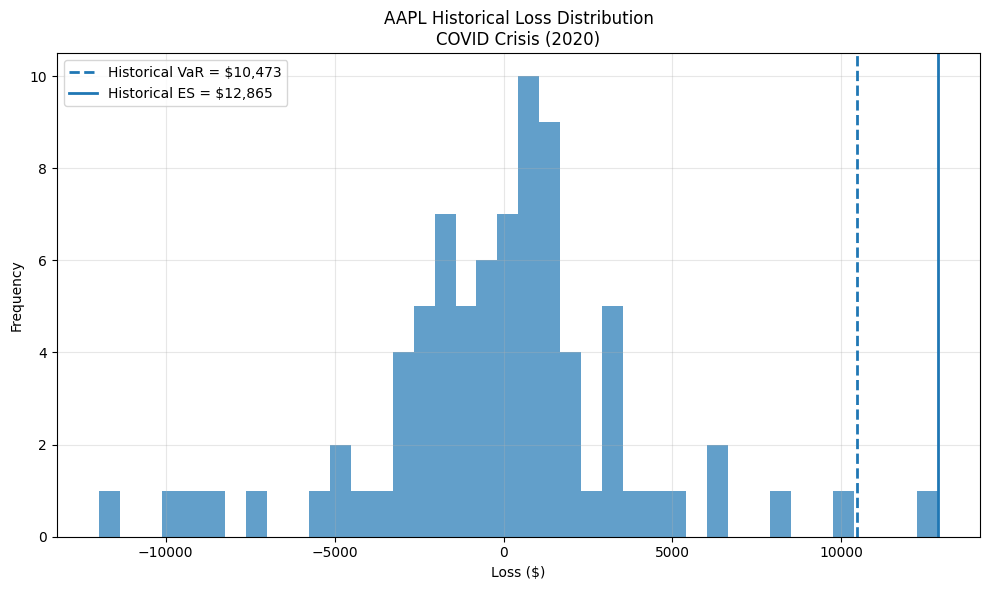

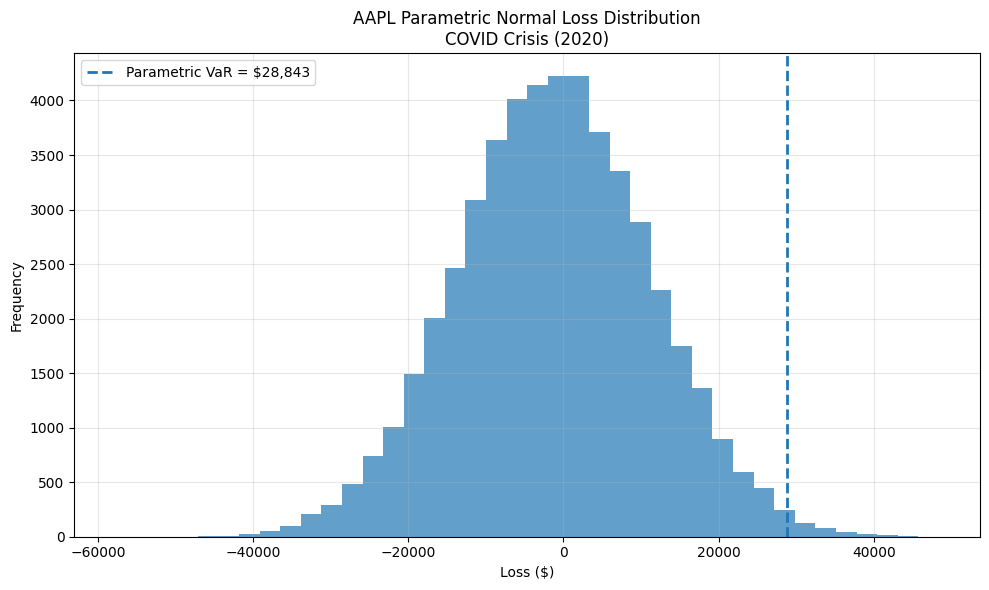

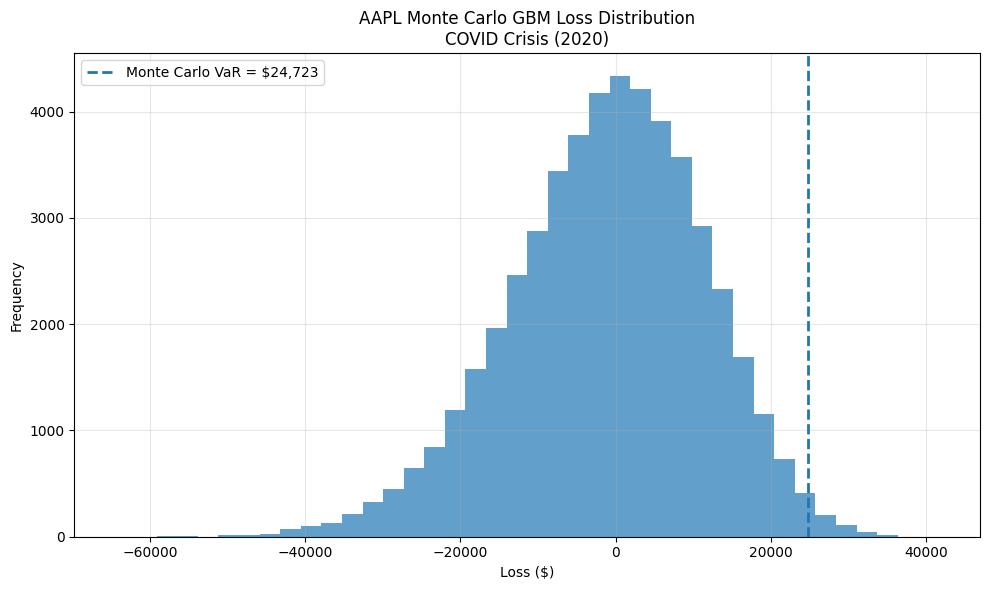

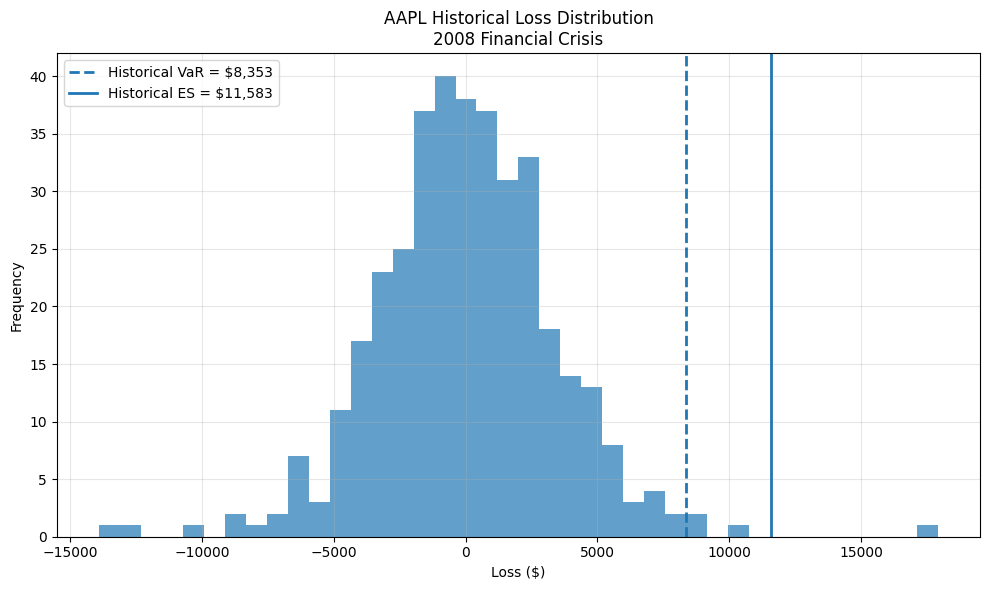

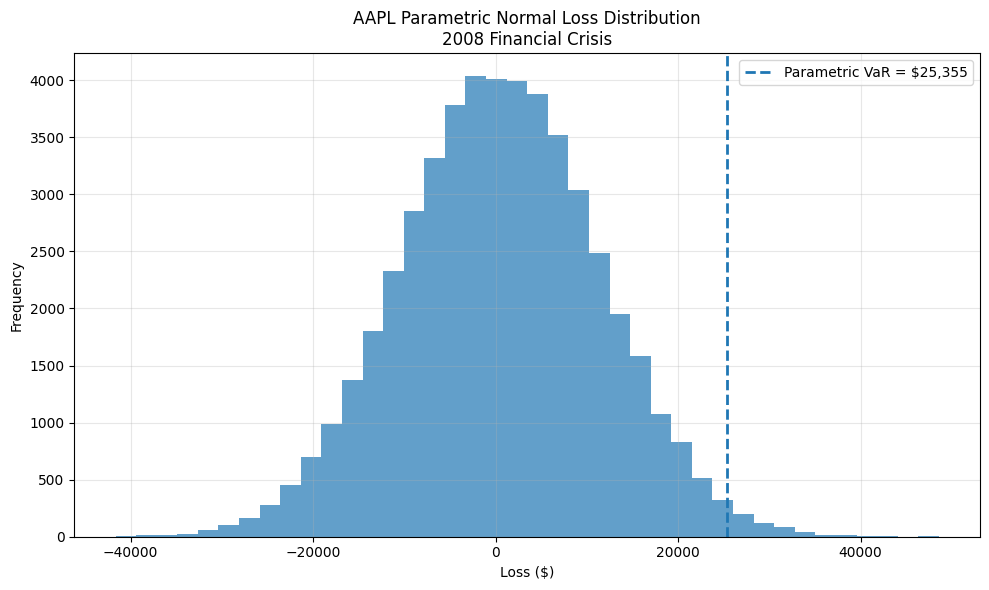

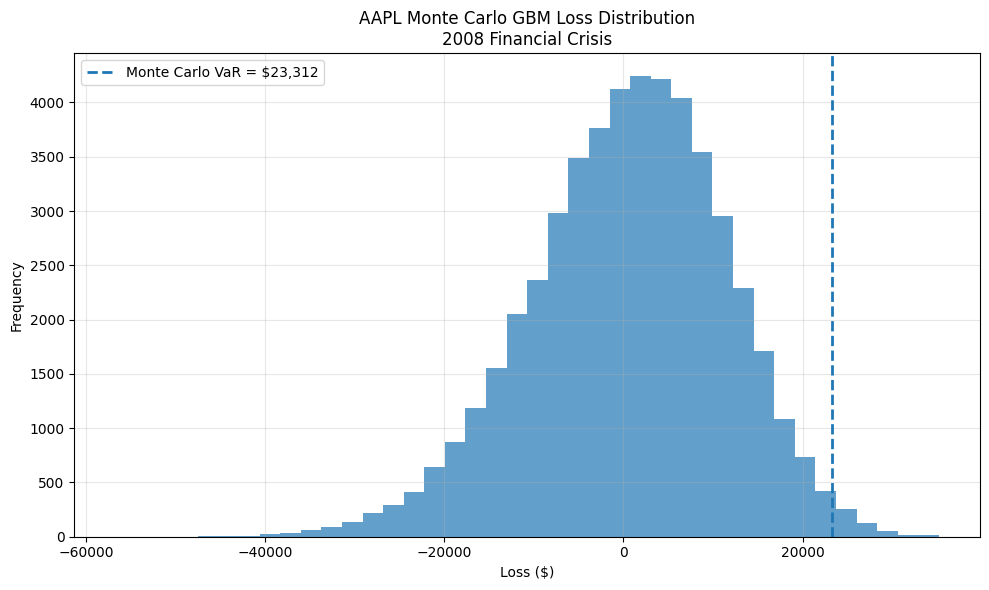

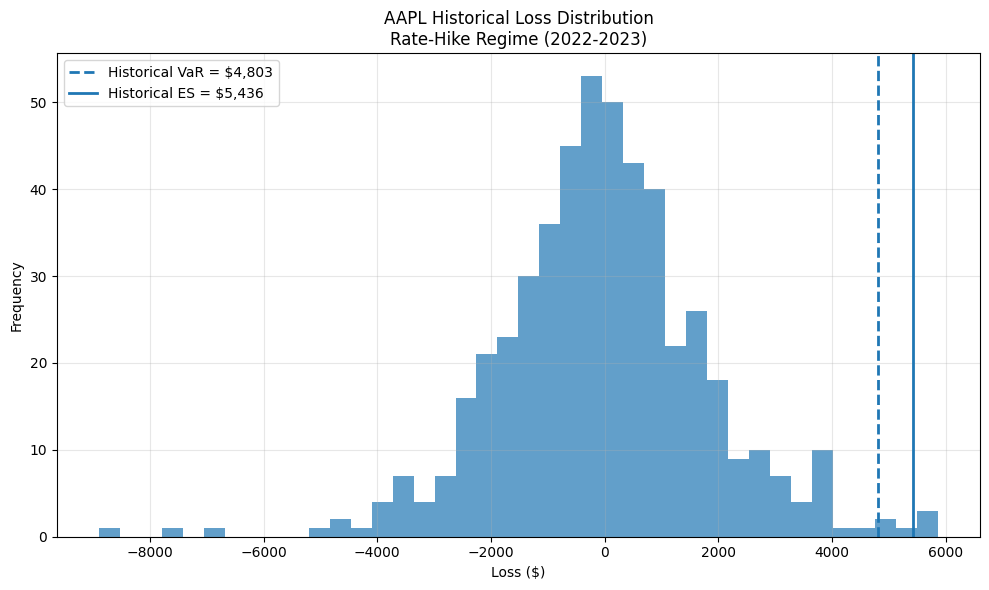

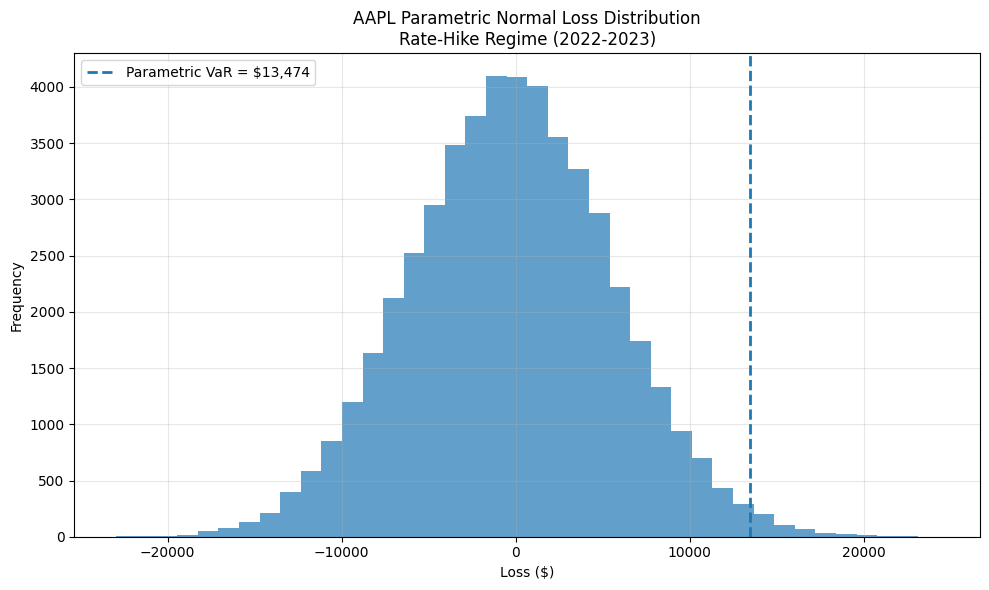

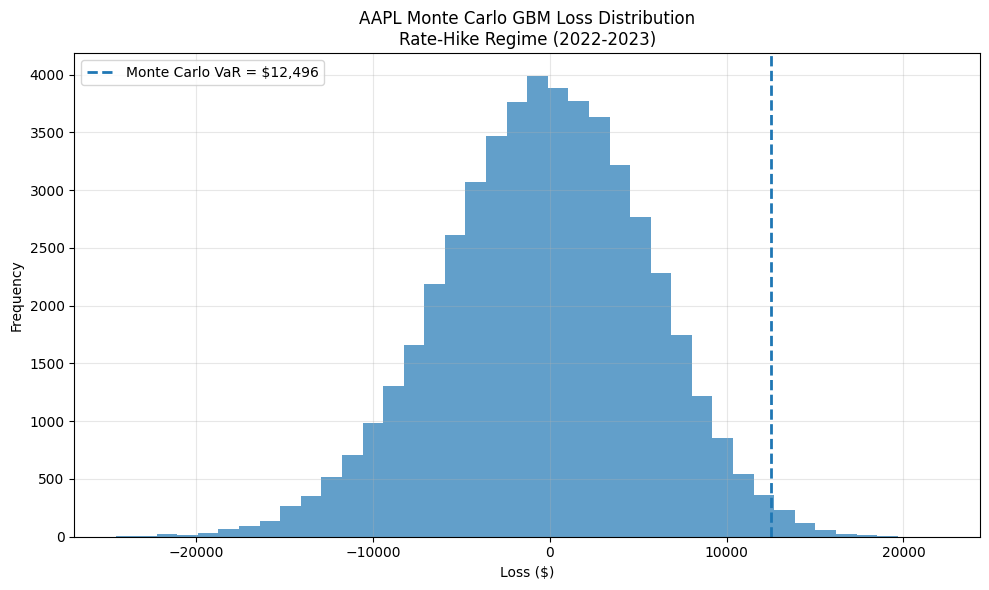

In [74]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker = "AAPL"
portfolio_value_target = 100000   # Same capital exposure for every regime
confidence = 0.99
horizon_days = 10
n_sim = 50000
np.random.seed(42)

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Risk computation function
# ---------------------------------------------------

def compute_risk_distributions(
    prices,
    portfolio_value_target,
    confidence,
    horizon_days,
    n_sim
):

    returns = prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    current_price = prices.iloc[-1]

    # Fixed portfolio value for fair comparison
    portfolio_value = portfolio_value_target

    # Shares adjust depending on stock price
    shares = portfolio_value_target / current_price

    # ---------------------------------------------------
    # Historical VaR / ES
    # ---------------------------------------------------

    historical_pnl = portfolio_value * returns
    historical_losses = -historical_pnl

    historical_var = np.percentile(
        historical_losses,
        confidence * 100
    )

    historical_es = historical_losses[
        historical_losses >= historical_var
    ].mean()

    # ---------------------------------------------------
    # Parametric VaR
    # ---------------------------------------------------

    z = norm.ppf(confidence)

    parametric_var = (
        portfolio_value
        * sigma_daily
        * np.sqrt(horizon_days)
        * z
    )

    parametric_returns = np.random.normal(
        loc=mu_daily * horizon_days,
        scale=sigma_daily * np.sqrt(horizon_days),
        size=n_sim
    )

    parametric_losses = -portfolio_value * parametric_returns

    # ---------------------------------------------------
    # Monte Carlo VaR using GBM
    # ---------------------------------------------------

    Z = np.random.normal(size=n_sim)

    simulated_prices = current_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    simulated_values = simulated_prices * shares

    mc_pnl = simulated_values - portfolio_value
    mc_losses = -mc_pnl

    mc_var = np.percentile(
        mc_losses,
        confidence * 100
    )

    return {
        "Current Price": current_price,
        "Shares": shares,
        "Portfolio Value": portfolio_value,

        "Historical Losses": historical_losses,
        "Historical VaR": historical_var,
        "Historical ES": historical_es,

        "Parametric Losses": parametric_losses,
        "Parametric VaR": parametric_var,

        "Monte Carlo Losses": mc_losses,
        "Monte Carlo VaR": mc_var
    }

# ---------------------------------------------------
# Run analysis
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    print(f"Downloading {regime_name}...")

    prices = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(prices, pd.DataFrame):
        prices = prices[ticker]

    results[regime_name] = compute_risk_distributions(
        prices,
        portfolio_value_target,
        confidence,
        horizon_days,
        n_sim
    )

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "Current Price": data["Current Price"],
        "Shares Used": data["Shares"],
        "Portfolio Value": data["Portfolio Value"],
        "Historical VaR": data["Historical VaR"],
        "Historical ES": data["Historical ES"],
        "Parametric VaR": data["Parametric VaR"],
        "Monte Carlo VaR": data["Monte Carlo VaR"]
    }
    for regime, data in results.items()
])

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\nRisk Methodology Comparison")
print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

methods = [
    "Historical VaR",
    "Historical ES",
    "Parametric VaR",
    "Monte Carlo VaR"
]

comparison_df.set_index("Regime")[methods].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker} VaR / ES Comparison Across Market Regimes\n"
    f"${portfolio_value_target:,.0f} Portfolio, "
    f"{confidence:.0%} Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("Risk Value ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Distribution graphs
# ---------------------------------------------------

for regime, data in results.items():

    # Historical distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Historical Losses"],
        bins=40,
        alpha=0.7
    )

    plt.axvline(
        data["Historical VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Historical VaR = ${data['Historical VaR']:,.0f}"
    )

    plt.axvline(
        data["Historical ES"],
        linestyle="-",
        linewidth=2,
        label=f"Historical ES = ${data['Historical ES']:,.0f}"
    )

    plt.title(f"{ticker} Historical Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Parametric distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Parametric Losses"],
        bins=40,
        alpha=0.7
    )

    plt.axvline(
        data["Parametric VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Parametric VaR = ${data['Parametric VaR']:,.0f}"
    )

    plt.title(f"{ticker} Parametric Normal Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Monte Carlo GBM distribution
    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Monte Carlo Losses"],
        bins=40,
        alpha=0.7
    )
    
    plt.axvline(
        data["Monte Carlo VaR"],
        linestyle="--",
        linewidth=2,
        label=f"Monte Carlo VaR = ${data['Monte Carlo VaR']:,.0f}"
    )
    plt.title(f"{ticker} Monte Carlo GBM Loss Distribution\n{regime}")
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
#

Option VAR

Selected Option
----------------
Ticker: AAPL
Option Type: call
Expiration: 2026-05-13
Spot Price: 294.8
Strike: 295.0
Market Option Price: 1.55
Implied Volatility: 0.271
Contracts: 1000
Current Option Portfolio Value: 155000.0

Option Repricing VaR Results
----------------------------
99% VaR: 155000.0
99% Expected Shortfall: 155000.0


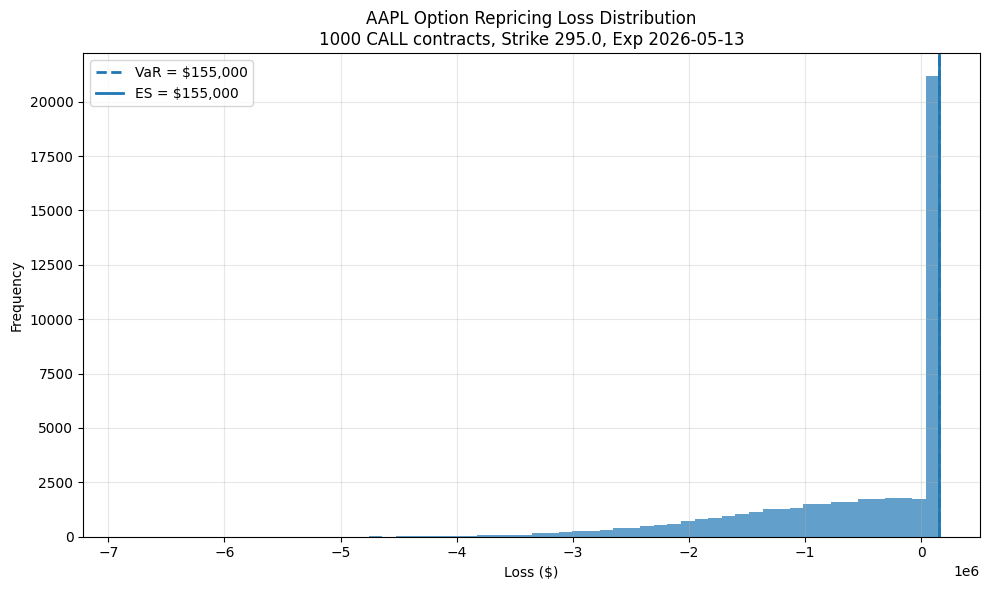

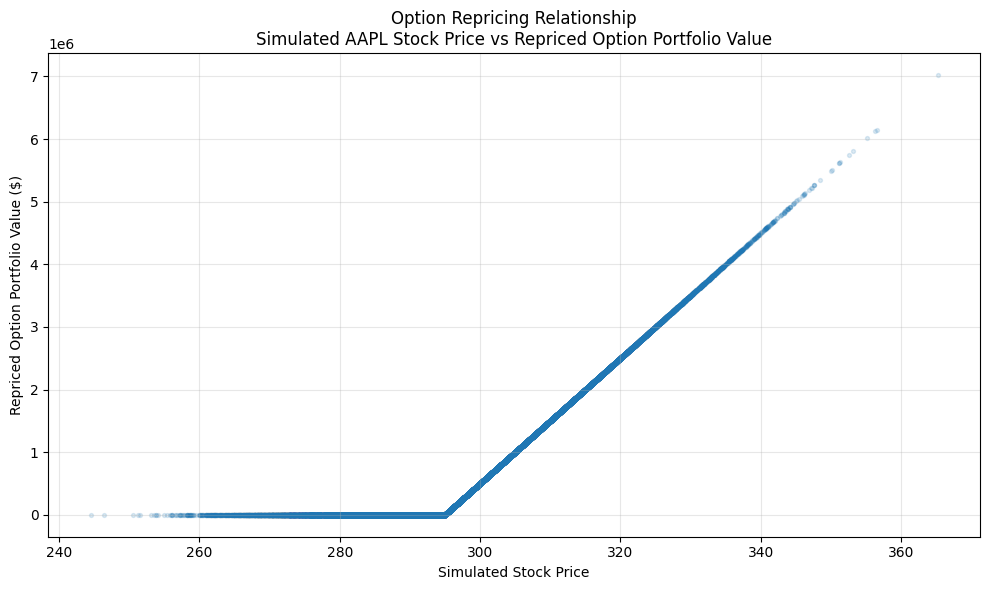

In [75]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"

option_type = "call"      # "call" or "put"
contracts = 1000          # number of option contracts
contract_size = 100       # 1 option contract = 100 shares

confidence = 0.99
horizon_days = 10
n_sim = 50000

risk_free_rate = 0.045    # approximate annual risk-free rate
np.random.seed(42)

# ---------------------------------------------------
# Black-Scholes pricing function
# ---------------------------------------------------

def bs_price(S, K, T, r, sigma, option_type="call"):
    if T <= 0:
        if option_type == "call":
            return np.maximum(S - K, 0)
        else:
            return np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ---------------------------------------------------
# Download stock and option data
# ---------------------------------------------------

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(period="1d")["Close"].iloc[-1]

expiration = ticker.options[0]   # nearest expiration
chain = ticker.option_chain(expiration)

if option_type == "call":
    options = chain.calls
else:
    options = chain.puts

# ---------------------------------------------------
# Select option: closest strike to current stock price
# ---------------------------------------------------

options["strike_diff"] = abs(options["strike"] - spot_price)
selected_option = options.sort_values("strike_diff").iloc[0]

K = selected_option["strike"]
market_option_price = selected_option["lastPrice"]
implied_vol = selected_option["impliedVolatility"]

# Time to expiration
today = pd.Timestamp.today().normalize()
expiration_date = pd.Timestamp(expiration)
T = (expiration_date - today).days / 365

T_after_horizon = max(T - horizon_days / 365, 0)

# ---------------------------------------------------
# Estimate stock return volatility
# ---------------------------------------------------

stock_prices = yf.download(
    ticker_symbol,
    period="1y",
    auto_adjust=True,
    progress=False
)["Close"]

if isinstance(stock_prices, pd.DataFrame):
    stock_prices = stock_prices[ticker_symbol]

returns = stock_prices.pct_change().dropna()

mu_daily = returns.mean()
sigma_daily = returns.std()

# ---------------------------------------------------
# Current option portfolio value
# ---------------------------------------------------

current_option_value = (
    market_option_price
    * contracts
    * contract_size
)

print("Selected Option")
print("----------------")
print("Ticker:", ticker_symbol)
print("Option Type:", option_type)
print("Expiration:", expiration)
print("Spot Price:", round(spot_price, 2))
print("Strike:", K)
print("Market Option Price:", round(market_option_price, 2))
print("Implied Volatility:", round(implied_vol, 4))
print("Contracts:", contracts)
print("Current Option Portfolio Value:", round(current_option_value, 2))

# ---------------------------------------------------
# Monte Carlo simulation of future stock prices
# ---------------------------------------------------

Z = np.random.normal(size=n_sim)

simulated_stock_prices = spot_price * np.exp(
    (mu_daily - 0.5 * sigma_daily**2) * horizon_days
    + sigma_daily * np.sqrt(horizon_days) * Z
)

# ---------------------------------------------------
# Reprice option after simulated stock move
# ---------------------------------------------------

repriced_options = bs_price(
    S=simulated_stock_prices,
    K=K,
    T=T_after_horizon,
    r=risk_free_rate,
    sigma=implied_vol,
    option_type=option_type
)

simulated_option_values = (
    repriced_options
    * contracts
    * contract_size
)

# ---------------------------------------------------
# Compute P&L, losses, VaR, ES
# ---------------------------------------------------

pnl = simulated_option_values - current_option_value
losses = -pnl

option_var = np.percentile(losses, confidence * 100)

option_es = losses[losses >= option_var].mean()

print("\nOption Repricing VaR Results")
print("----------------------------")
print(f"{confidence:.0%} VaR:", round(option_var, 2))
print(f"{confidence:.0%} Expected Shortfall:", round(option_es, 2))

# ---------------------------------------------------
# Plot loss distribution
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(losses, bins=60, alpha=0.7)

plt.axvline(
    option_var,
    linestyle="--",
    linewidth=2,
    label=f"VaR = ${option_var:,.0f}"
)

plt.axvline(
    option_es,
    linestyle="-",
    linewidth=2,
    label=f"ES = ${option_es:,.0f}"
)

plt.title(
    f"{ticker_symbol} Option Repricing Loss Distribution\n"
    f"{contracts} {option_type.upper()} contracts, Strike {K}, Exp {expiration}"
)

plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Plot simulated stock prices vs option values
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    simulated_stock_prices,
    simulated_option_values,
    alpha=0.15,
    s=8
)

plt.title(
    f"Option Repricing Relationship\n"
    f"Simulated {ticker_symbol} Stock Price vs Repriced Option Portfolio Value"
)

plt.xlabel("Simulated Stock Price")
plt.ylabel("Repriced Option Portfolio Value ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Selected Current Option Position
--------------------------------
Ticker: AAPL
Option Type: call
Expiration: 2026-05-13
Spot Price: 294.8
Strike: 295.0
Market Option Price: 1.55
Implied Volatility: 0.271
Contracts: 1000
Current Option Portfolio Value: 155000.0

Running option repricing VaR for Normal Market (2023-2024)...

Running option repricing VaR for COVID Crisis (2020)...

Running option repricing VaR for 2008 Financial Crisis...

Running option repricing VaR for Rate-Hike Regime (2022-2023)...

Option Repricing VaR Comparison
                         Regime  Mean Daily Return  Daily Volatility  \
0     Normal Market (2023-2024)             0.0018            0.0126   
1           COVID Crisis (2020)             0.0012            0.0392   
2         2008 Financial Crisis            -0.0005            0.0345   
3  Rate-Hike Regime (2022-2023)             0.0003            0.0183   

    Option VaR    Option ES  
0 155,000.0000 155,000.0000  
1 155,000.0000 155,000.0000  
2 155,000.

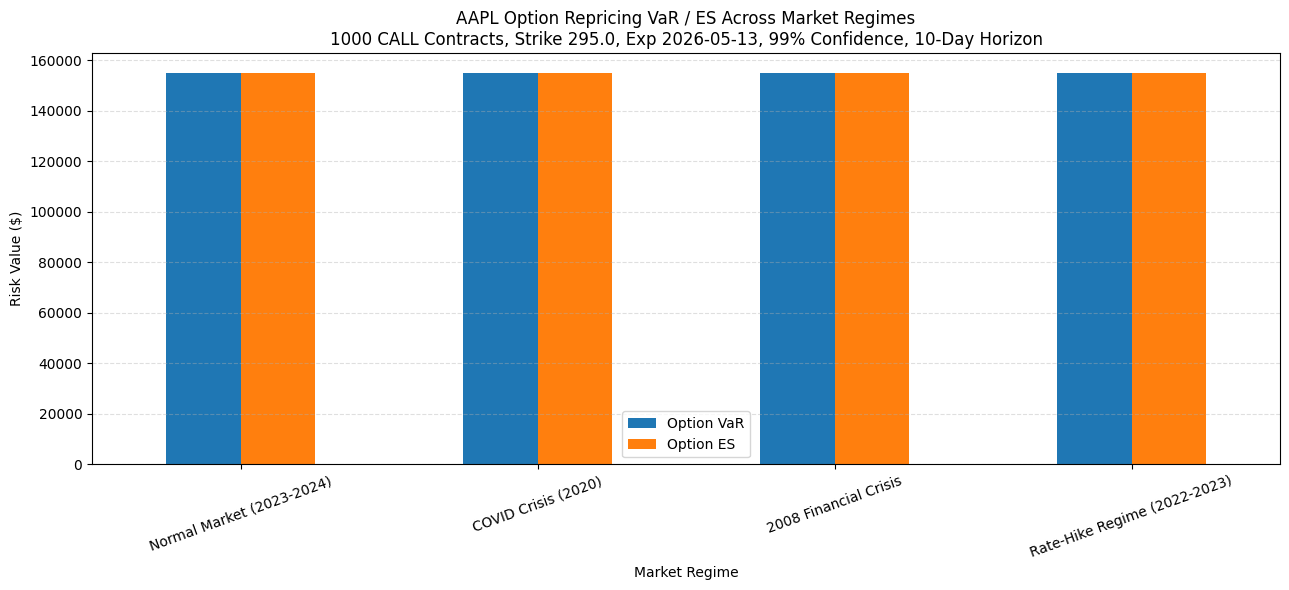

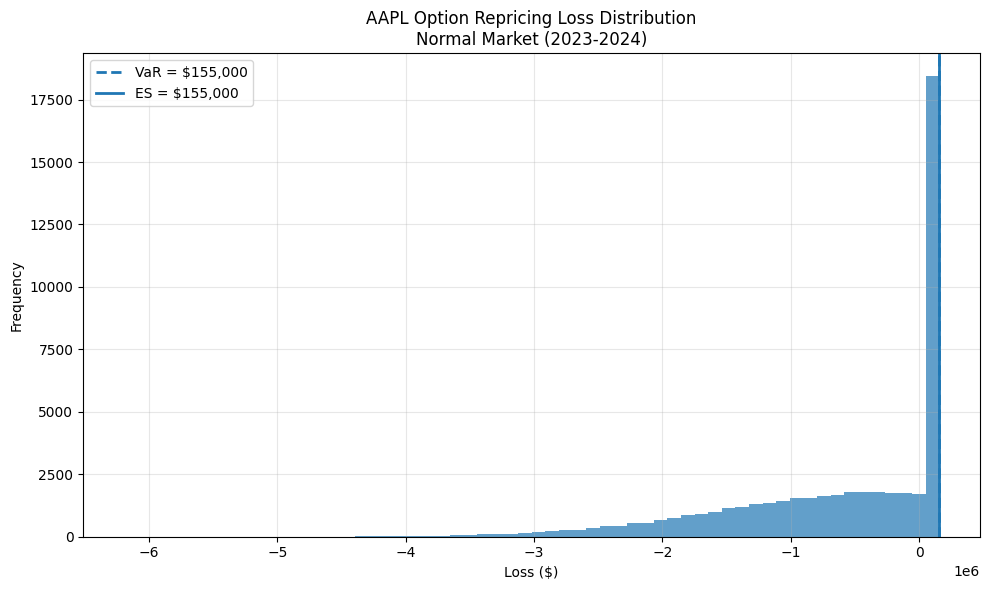

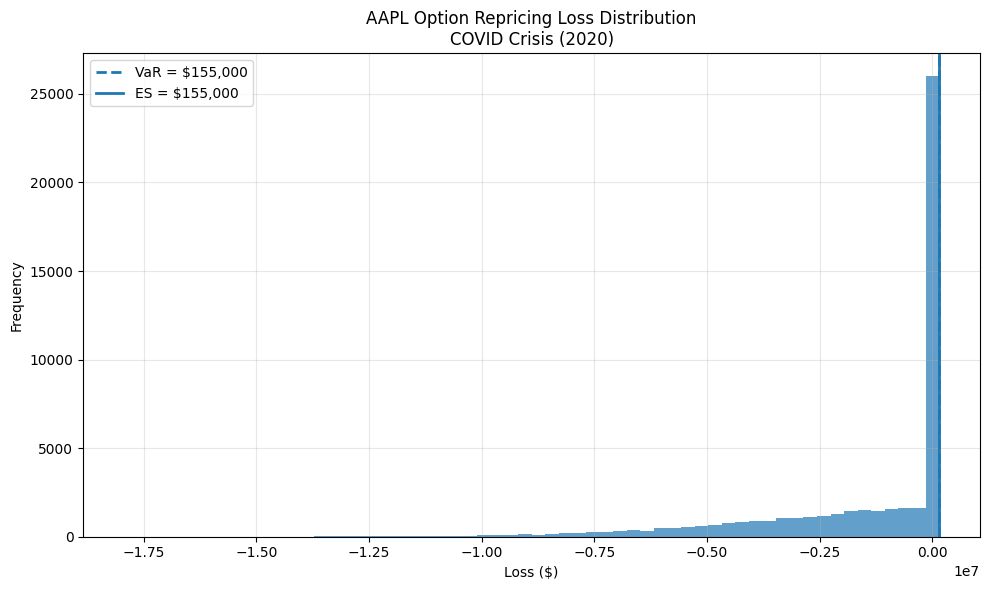

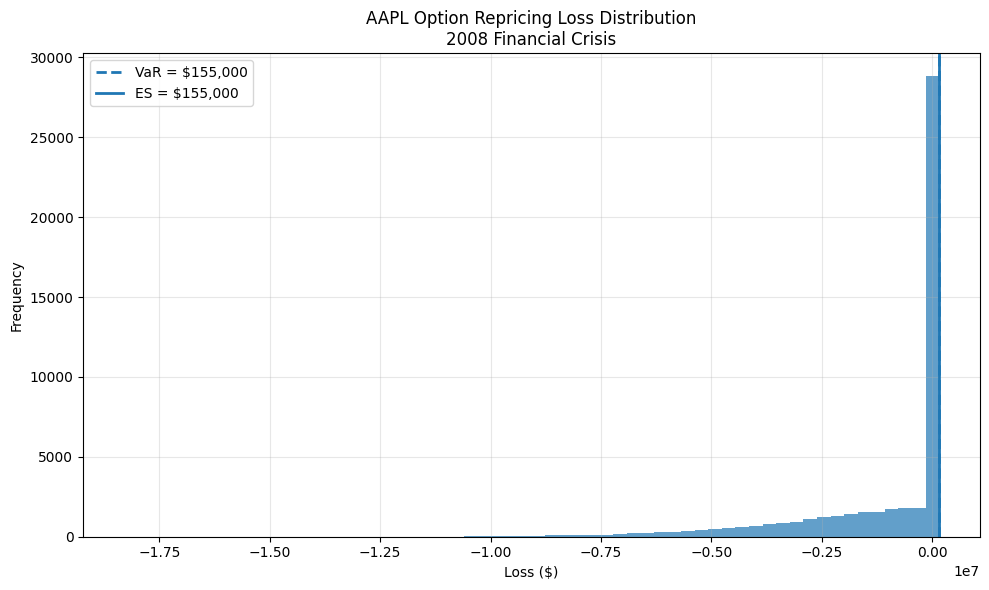

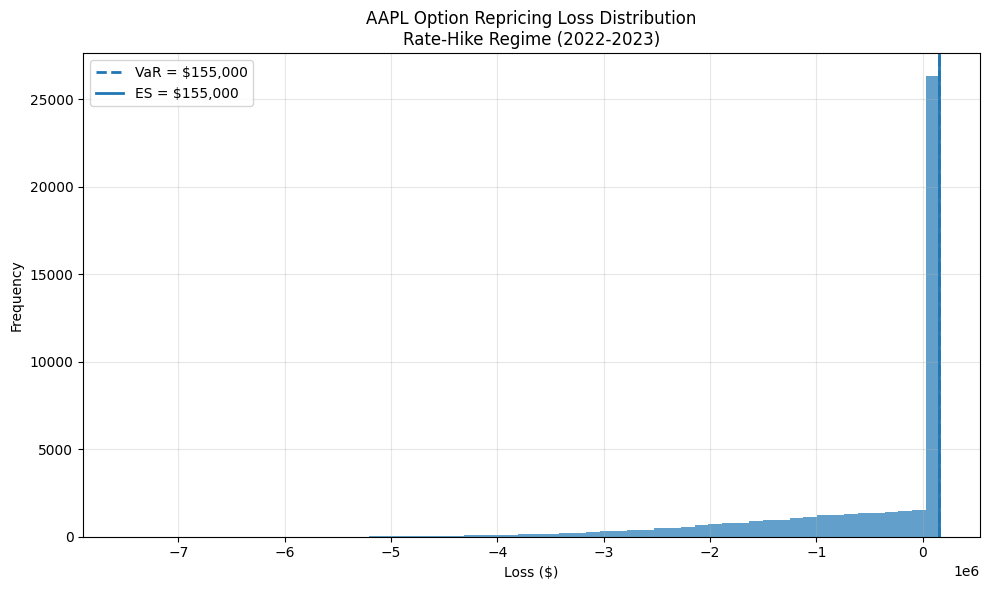

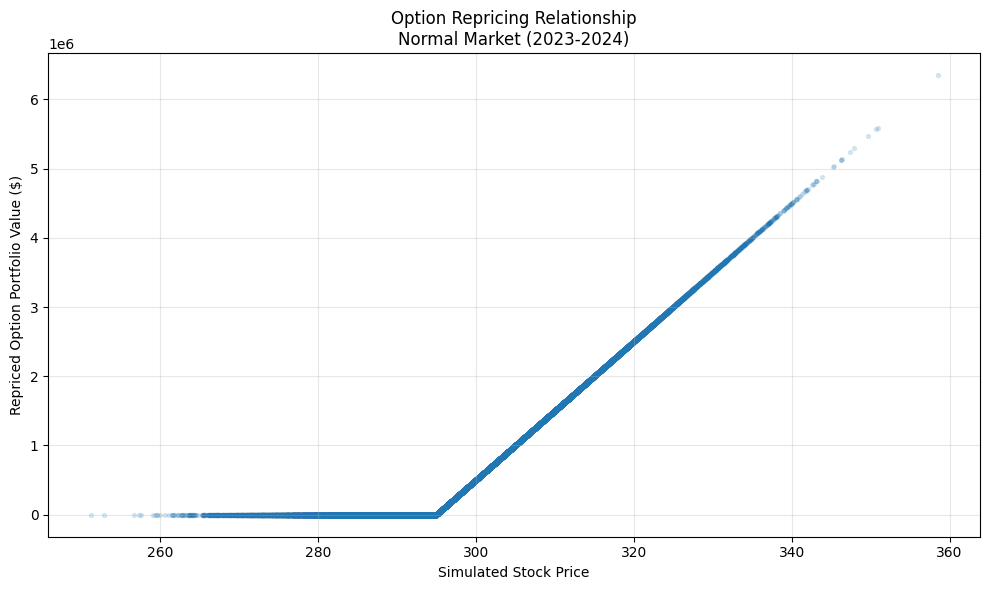

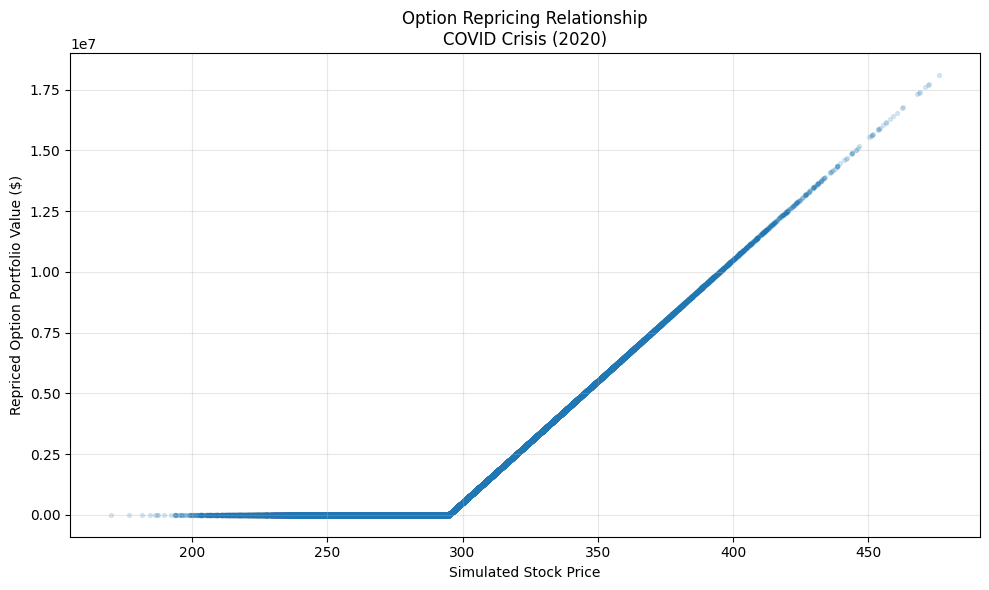

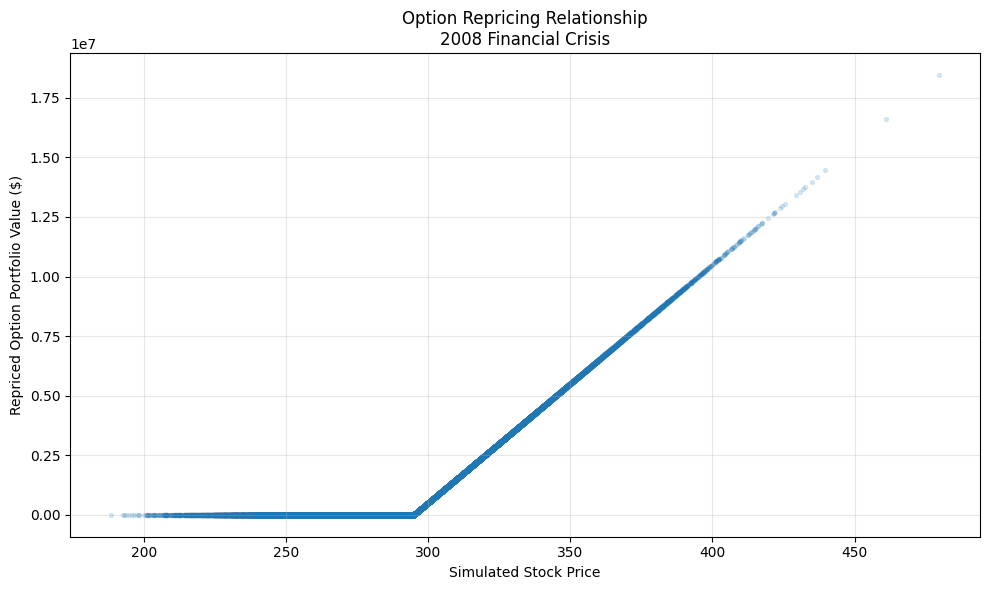

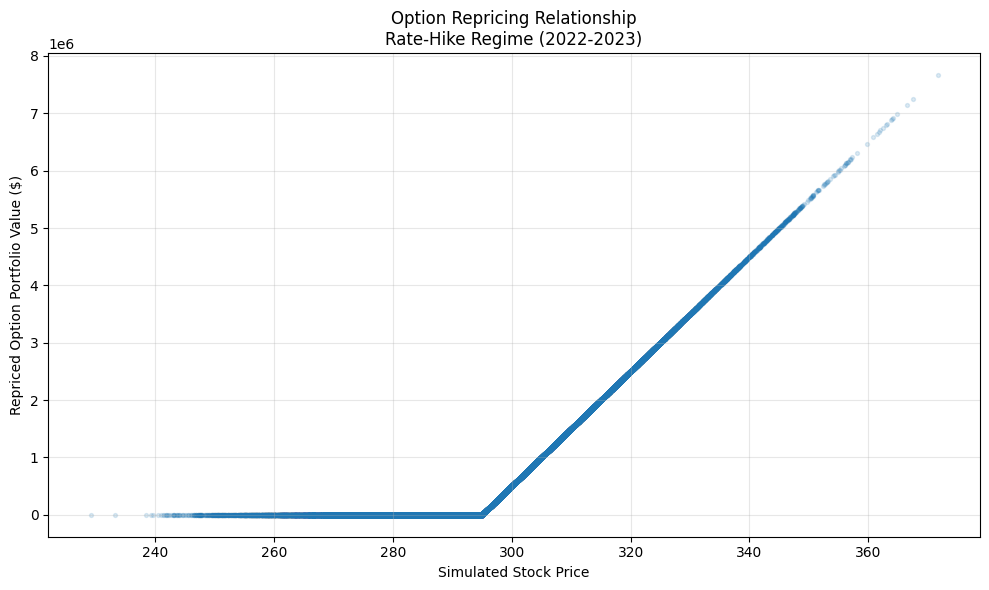

In [76]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"

option_type = "call"      # "call" or "put"
contracts = 1000
contract_size = 100

confidence = 0.99
horizon_days = 10
n_sim = 50000

risk_free_rate = 0.045
np.random.seed(42)

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Black-Scholes pricing function
# ---------------------------------------------------

def bs_price(S, K, T, r, sigma, option_type="call"):

    if T <= 0:
        if option_type == "call":
            return np.maximum(S - K, 0)
        else:
            return np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (
        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ---------------------------------------------------
# Get current option position
# ---------------------------------------------------

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(period="1d")["Close"].iloc[-1]

expiration = ticker.options[0]   # nearest expiration
chain = ticker.option_chain(expiration)

if option_type == "call":
    options = chain.calls.copy()
else:
    options = chain.puts.copy()

# Choose closest strike to current stock price
options["strike_diff"] = abs(options["strike"] - spot_price)
selected_option = options.sort_values("strike_diff").iloc[0]

K = selected_option["strike"]
market_option_price = selected_option["lastPrice"]
implied_vol = selected_option["impliedVolatility"]

today = pd.Timestamp.today().normalize()
expiration_date = pd.Timestamp(expiration)

T = (expiration_date - today).days / 365
T_after_horizon = max(T - horizon_days / 365, 0)

current_option_value = (
    market_option_price
    * contracts
    * contract_size
)

print("Selected Current Option Position")
print("--------------------------------")
print("Ticker:", ticker_symbol)
print("Option Type:", option_type)
print("Expiration:", expiration)
print("Spot Price:", round(spot_price, 2))
print("Strike:", K)
print("Market Option Price:", round(market_option_price, 2))
print("Implied Volatility:", round(implied_vol, 4))
print("Contracts:", contracts)
print("Current Option Portfolio Value:", round(current_option_value, 2))

# ---------------------------------------------------
# Option repricing VaR function by regime
# ---------------------------------------------------

def compute_option_repricing_var(
    regime_name,
    start,
    end
):

    stock_prices = yf.download(
        ticker_symbol,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(stock_prices, pd.DataFrame):
        stock_prices = stock_prices[ticker_symbol]

    returns = stock_prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    Z = np.random.normal(size=n_sim)

    simulated_stock_prices = spot_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    repriced_options = bs_price(
        S=simulated_stock_prices,
        K=K,
        T=T_after_horizon,
        r=risk_free_rate,
        sigma=implied_vol,
        option_type=option_type
    )

    simulated_option_values = (
        repriced_options
        * contracts
        * contract_size
    )

    pnl = simulated_option_values - current_option_value
    losses = -pnl

    var = np.percentile(losses, confidence * 100)
    es = losses[losses >= var].mean()

    return {
        "Regime": regime_name,
        "Start": start,
        "End": end,
        "Mean Daily Return": mu_daily,
        "Daily Volatility": sigma_daily,
        "Option VaR": var,
        "Option ES": es,
        "Losses": losses,
        "Simulated Stock Prices": simulated_stock_prices,
        "Repriced Option Values": simulated_option_values
    }

# ---------------------------------------------------
# Run regime tests
# ---------------------------------------------------

results = {}

for regime_name, (start, end) in periods.items():

    print(f"\nRunning option repricing VaR for {regime_name}...")

    results[regime_name] = compute_option_repricing_var(
        regime_name,
        start,
        end
    )

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Regime": regime,
        "Mean Daily Return": data["Mean Daily Return"],
        "Daily Volatility": data["Daily Volatility"],
        "Option VaR": data["Option VaR"],
        "Option ES": data["Option ES"]
    }
    for regime, data in results.items()
])

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("\nOption Repricing VaR Comparison")
print(comparison_df)

# ---------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------

comparison_df.set_index("Regime")[["Option VaR", "Option ES"]].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    f"{ticker_symbol} Option Repricing VaR / ES Across Market Regimes\n"
    f"{contracts} {option_type.upper()} Contracts, Strike {K}, Exp {expiration}, "
    f"{confidence:.0%} Confidence, {horizon_days}-Day Horizon"
)

plt.ylabel("Risk Value ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Loss distribution graphs by regime
# ---------------------------------------------------

for regime, data in results.items():

    plt.figure(figsize=(10, 6))

    plt.hist(
        data["Losses"],
        bins=60,
        alpha=0.7
    )

    plt.axvline(
        data["Option VaR"],
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${data['Option VaR']:,.0f}"
    )

    plt.axvline(
        data["Option ES"],
        linestyle="-",
        linewidth=2,
        label=f"ES = ${data['Option ES']:,.0f}"
    )

    plt.title(
        f"{ticker_symbol} Option Repricing Loss Distribution\n"
        f"{regime}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# Stock price vs repriced option value by regime
# ---------------------------------------------------

for regime, data in results.items():

    plt.figure(figsize=(10, 6))

    plt.scatter(
        data["Simulated Stock Prices"],
        data["Repriced Option Values"],
        alpha=0.15,
        s=8
    )

    plt.title(
        f"Option Repricing Relationship\n"
        f"{regime}"
    )

    plt.xlabel("Simulated Stock Price")
    plt.ylabel("Repriced Option Portfolio Value ($)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Selected Expirations
{'Short Expiration': '2026-05-29', 'Medium Expiration': '2026-07-17', 'Long Expiration': '2026-11-20'}

Selected Option Positions

 Short Expiration
{'Expiration': '2026-05-29', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(6.03), 'Implied Volatility': np.float64(0.2500685345458984), 'T': 0.04657534246575343, 'T After Horizon': 0.019178082191780826, 'Current Option Value': np.float64(603000.0)}

 Medium Expiration
{'Expiration': '2026-07-17', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(12.73), 'Implied Volatility': np.float64(0.25891854370117195), 'T': 0.18082191780821918, 'T After Horizon': 0.15342465753424658, 'Current Option Value': np.float64(1273000.0)}

 Long Expiration
{'Expiration': '2026-11-20', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(25.18), 'Implied Volatility': np.float64(0.30170376037597657), 'T': 0.5260273972602739, 'T After Horizon': 0.4986301369863013, 'Current Option Value': np.float64(2518

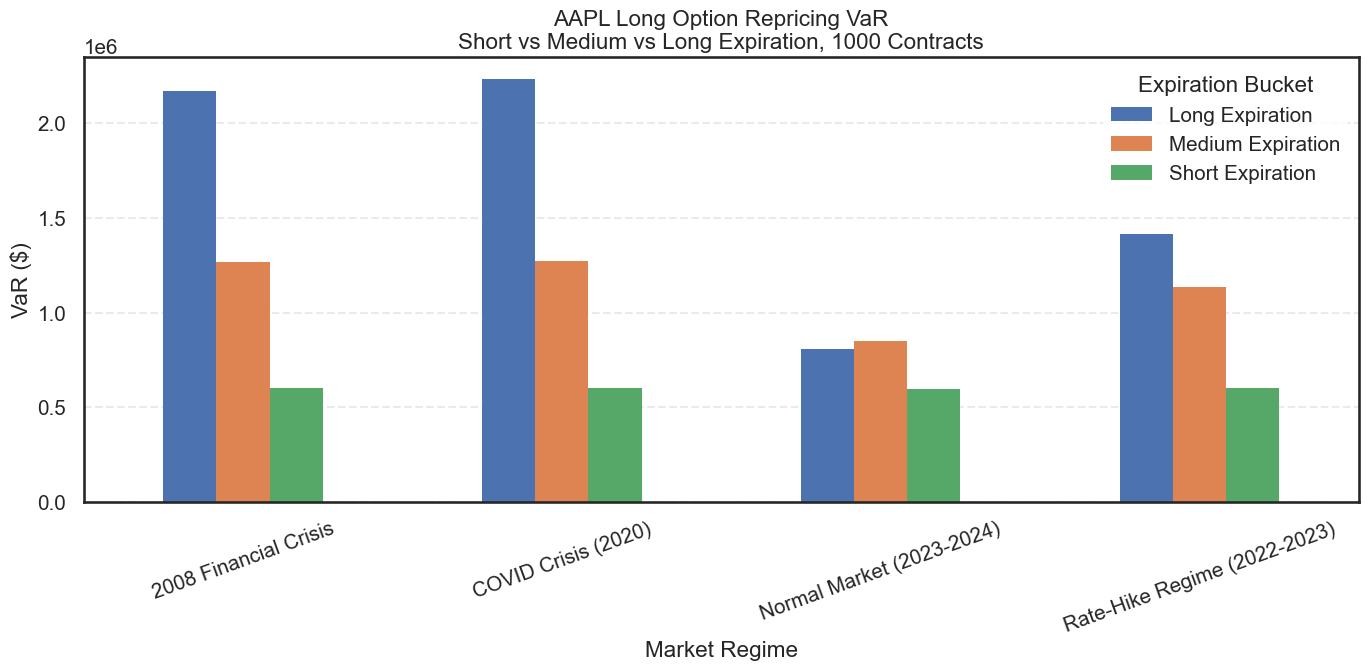

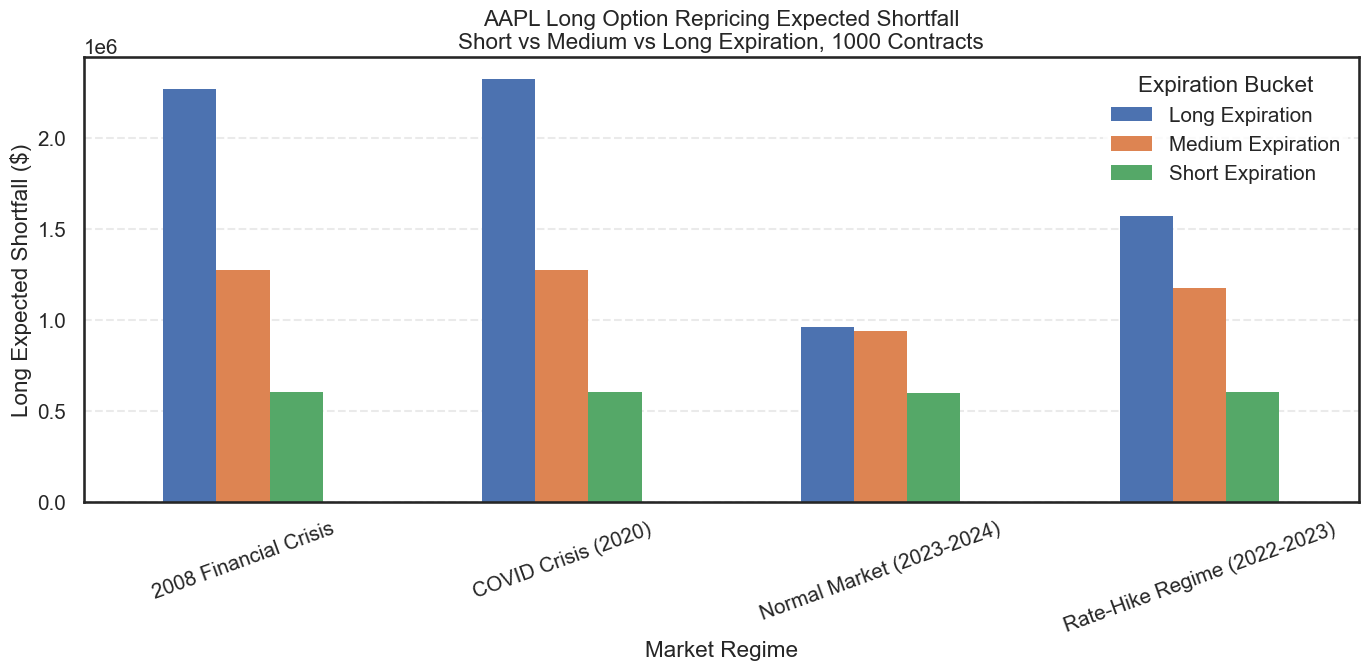

SyntaxError: keyword argument repeated: linewidth (3302062789.py, line 350)

In [103]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------
# Settings
# ---------------------------------------------------

ticker_symbol = "AAPL"

option_type = "call"      # "call" or "put"
contracts = 1000
contract_size = 100

confidence = 0.99
horizon_days = 10
n_sim = 50000

risk_free_rate = 0.045
np.random.seed(42)

# ---------------------------------------------------
# Market regimes
# ---------------------------------------------------

periods = {
    "Normal Market (2023-2024)": ("2023-01-01", "2024-01-01"),
    "COVID Crisis (2020)": ("2020-02-01", "2020-06-01"),
    "2008 Financial Crisis": ("2007-10-01", "2009-03-31"),
    "Rate-Hike Regime (2022-2023)": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# Black-Scholes pricing
# ---------------------------------------------------

def bs_price(S, K, T, r, sigma, option_type="call"):

    if T <= 0:
        if option_type == "call":
            return np.maximum(S - K, 0)
        else:
            return np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (
        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ---------------------------------------------------
# Load current stock and option data
# ---------------------------------------------------

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(period="1d")["Close"].iloc[-1]

today = pd.Timestamp.today().normalize()

all_expirations = [
    pd.Timestamp(exp)
    for exp in ticker.options
]

expiration_df = pd.DataFrame({
    "expiration": all_expirations
})

expiration_df["days_to_expiration"] = (
    expiration_df["expiration"] - today
).dt.days

expiration_df = expiration_df[
    expiration_df["days_to_expiration"] > horizon_days
]

# ---------------------------------------------------
# Pick short / medium / long expirations
# ---------------------------------------------------

targets = {
    "Short Expiration": 14,
    "Medium Expiration": 60,
    "Long Expiration": 180
}

selected_expirations = {}

for bucket, target_days in targets.items():

    closest_row = expiration_df.iloc[
        (expiration_df["days_to_expiration"] - target_days)
        .abs()
        .argsort()
        .iloc[0]
    ]

    selected_expirations[bucket] = closest_row["expiration"].strftime("%Y-%m-%d")

print("Selected Expirations")
print(selected_expirations)

# ---------------------------------------------------
# Select ATM option for each expiration
# ---------------------------------------------------

option_positions = {}

for bucket, expiration in selected_expirations.items():

    chain = ticker.option_chain(expiration)

    if option_type == "call":
        options = chain.calls.copy()
    else:
        options = chain.puts.copy()

    options["strike_diff"] = abs(options["strike"] - spot_price)

    selected_option = options.sort_values("strike_diff").iloc[0]

    K = selected_option["strike"]
    market_option_price = selected_option["lastPrice"]
    implied_vol = selected_option["impliedVolatility"]

    expiration_date = pd.Timestamp(expiration)

    T = (expiration_date - today).days / 365
    T_after_horizon = max(T - horizon_days / 365, 0)

    current_option_value = (
        market_option_price
        * contracts
        * contract_size
    )

    option_positions[bucket] = {
        "Expiration": expiration,
        "Strike": K,
        "Market Option Price": market_option_price,
        "Implied Volatility": implied_vol,
        "T": T,
        "T After Horizon": T_after_horizon,
        "Current Option Value": current_option_value
    }

print("\nSelected Option Positions")
for bucket, pos in option_positions.items():
    print("\n", bucket)
    print(pos)

# ---------------------------------------------------
# Repricing VaR function
# ---------------------------------------------------

def compute_option_var_by_regime(
    bucket,
    position,
    regime_name,
    start,
    end
):

    stock_prices = yf.download(
        ticker_symbol,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )["Close"]

    if isinstance(stock_prices, pd.DataFrame):
        stock_prices = stock_prices[ticker_symbol]

    returns = stock_prices.pct_change().dropna()

    mu_daily = returns.mean()
    sigma_daily = returns.std()

    Z = np.random.normal(size=n_sim)

    simulated_stock_prices = spot_price * np.exp(
        (mu_daily - 0.5 * sigma_daily**2) * horizon_days
        + sigma_daily * np.sqrt(horizon_days) * Z
    )

    repriced_options = bs_price(
        S=simulated_stock_prices,
        K=position["Strike"],
        T=position["T After Horizon"],
        r=risk_free_rate,
        sigma=position["Implied Volatility"],
        option_type=option_type
    )

    simulated_option_values = (
        repriced_options
        * contracts
        * contract_size
    )

    pnl = simulated_option_values - position["Current Option Value"]
    losses = -pnl

    var = np.percentile(losses, confidence * 100)
    es = losses[losses >= var].mean()

    return {
        "Expiration Bucket": bucket,
        "Regime": regime_name,
        "Expiration": position["Expiration"],
        "Strike": position["Strike"],
        "Market Option Price": position["Market Option Price"],
        "Implied Volatility": position["Implied Volatility"],
        "Current Option Value": position["Current Option Value"],
        "Mean Daily Return": mu_daily,
        "Daily Volatility": sigma_daily,
        "Option VaR": var,
        "Option ES": es,
        "Losses": losses
    }

# ---------------------------------------------------
# Run all tests
# ---------------------------------------------------

all_results = []

for bucket, position in option_positions.items():

    for regime_name, (start, end) in periods.items():

        print(f"Running {bucket} | {regime_name}")

        result = compute_option_var_by_regime(
            bucket,
            position,
            regime_name,
            start,
            end
        )

        all_results.append(result)

# ---------------------------------------------------
# Comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "Expiration Bucket": r["Expiration Bucket"],
        "Regime": r["Regime"],
        "Expiration": r["Expiration"],
        "Strike": r["Strike"],
        "Market Option Price": r["Market Option Price"],
        "Implied Volatility": r["Implied Volatility"],
        "Current Option Value": r["Current Option Value"],
        "Daily Volatility": r["Daily Volatility"],
        "Option VaR": r["Option VaR"],
        "Option ES": r["Option ES"]
    }
    for r in all_results
])

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("\nOption VaR by Expiration Bucket and Market Regime")
print(comparison_df)

# ---------------------------------------------------
# Bar chart: VaR comparison
# ---------------------------------------------------

pivot_var = comparison_df.pivot(
    index="Regime",
    columns="Expiration Bucket",
    values="Option VaR"
)

pivot_var.plot(
    kind="bar",
    figsize=(14, 7),linewidth=0

)

plt.title(
    f"{ticker_symbol} Long Option Repricing VaR\n"
    f"Short vs Medium vs Long Expiration, {contracts} Contracts"
)

plt.ylabel("VaR ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Bar chart: ES comparison
# ---------------------------------------------------

pivot_es = comparison_df.pivot(
    index="Regime",
    columns="Expiration Bucket",
    values="Option ES"
)

pivot_es.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker_symbol} Long Option Repricing Expected Shortfall\n"
    f"Short vs Medium vs Long Expiration, {contracts} Contracts"
)

plt.ylabel("Long Expected Shortfall ($)")
plt.xlabel("Market Regime")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Loss distribution graphs
# ---------------------------------------------------

for r in all_results:

    plt.figure(figsize=(10, 6))

    plt.hist(
        r["Losses"],
        bins=60,
        alpha=0.7,linewidth=0
    )
    plt.axvline(
        r["Option VaR"],
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${r['Option VaR']:,.0f}",linewidth=0
    )
    plt.axvline(
        r["Option ES"],
        linestyle="-",
        linewidth=2,
        label=f"ES = ${r['Option ES']:,.0f}",linewidth=0

    )
    plt.title(
        f"{ticker_symbol} Option Loss Distribution\n"
        f"{r['Expiration Bucket']} | {r['Regime']}"
    )
    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Selected Expirations
{'Short Expiration': '2026-05-29', 'Medium Expiration': '2026-07-17', 'Long Expiration': '2026-11-20'}

Selected Option Positions

 Short Expiration
{'Expiration': '2026-05-29', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(6.03), 'Implied Volatility': np.float64(0.2500685345458984), 'T': 0.04657534246575343, 'T After Horizon': 0.019178082191780826, 'Current Option Value': np.float64(603000.0)}

 Medium Expiration
{'Expiration': '2026-07-17', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(12.73), 'Implied Volatility': np.float64(0.25891854370117195), 'T': 0.18082191780821918, 'T After Horizon': 0.15342465753424658, 'Current Option Value': np.float64(1273000.0)}

 Long Expiration
{'Expiration': '2026-11-20', 'Strike': np.float64(295.0), 'Market Option Price': np.float64(25.18), 'Implied Volatility': np.float64(0.30170376037597657), 'T': 0.5260273972602739, 'T After Horizon': 0.4986301369863013, 'Current Option Value': np.float64(251

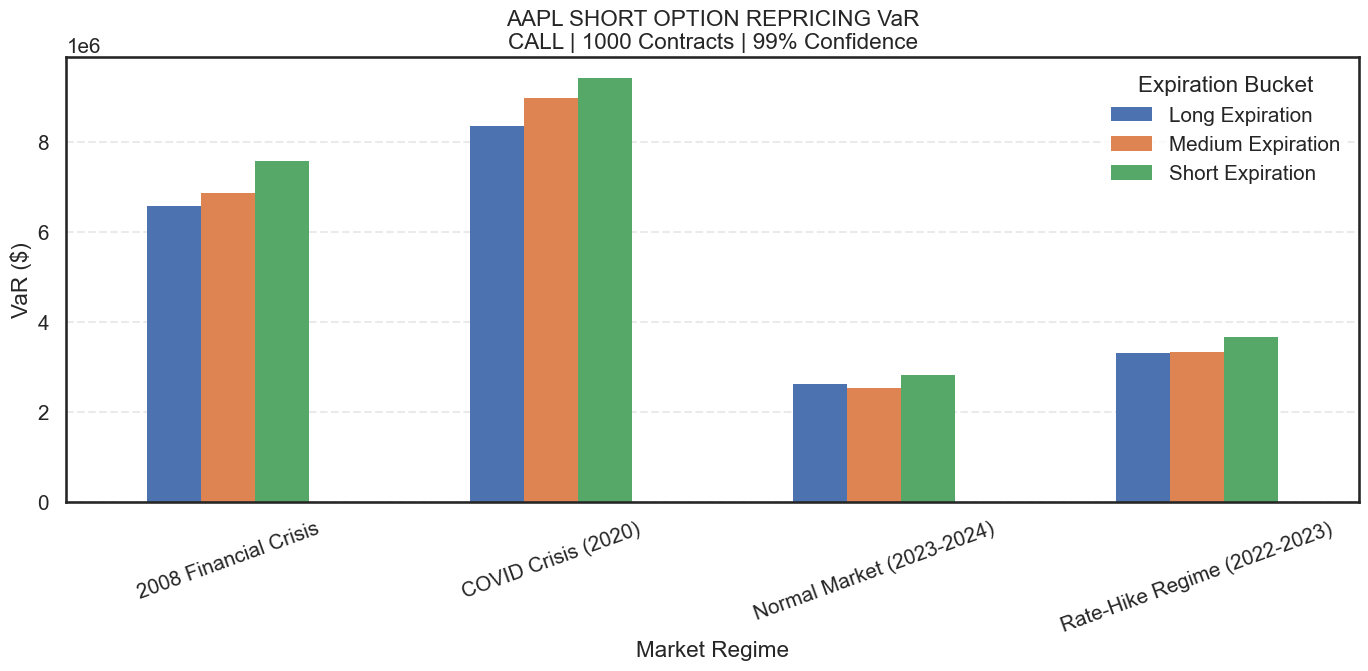

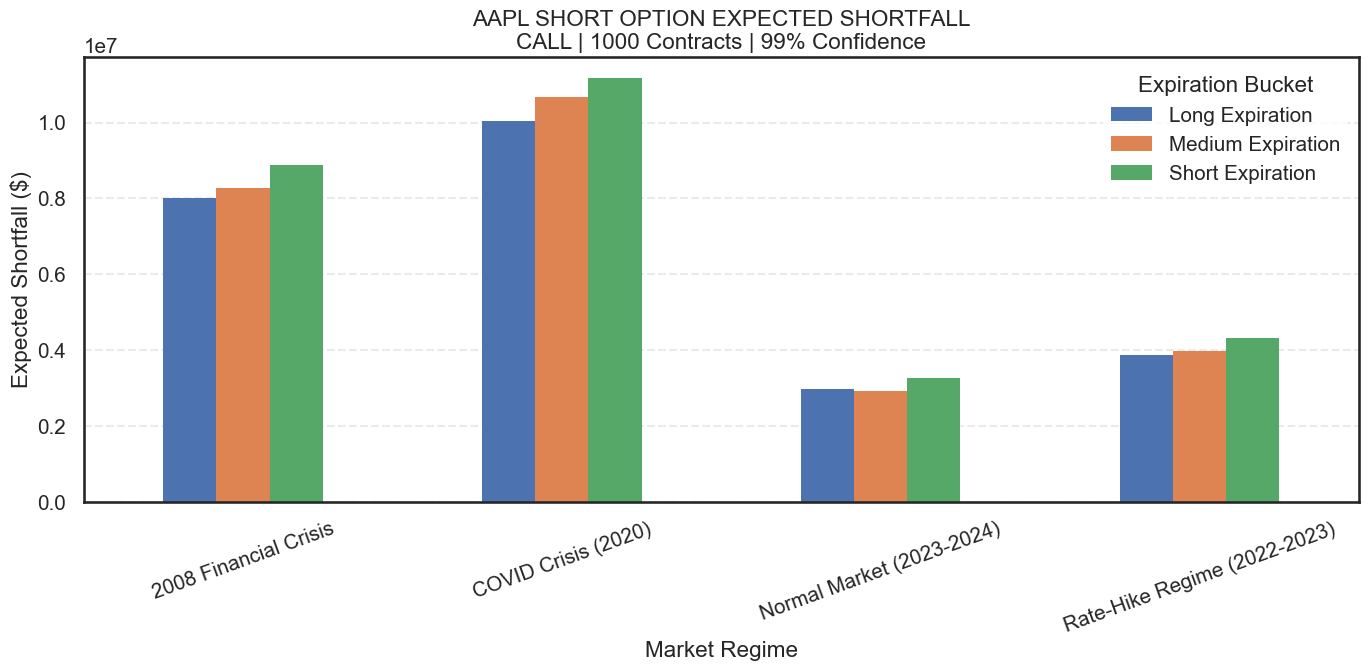

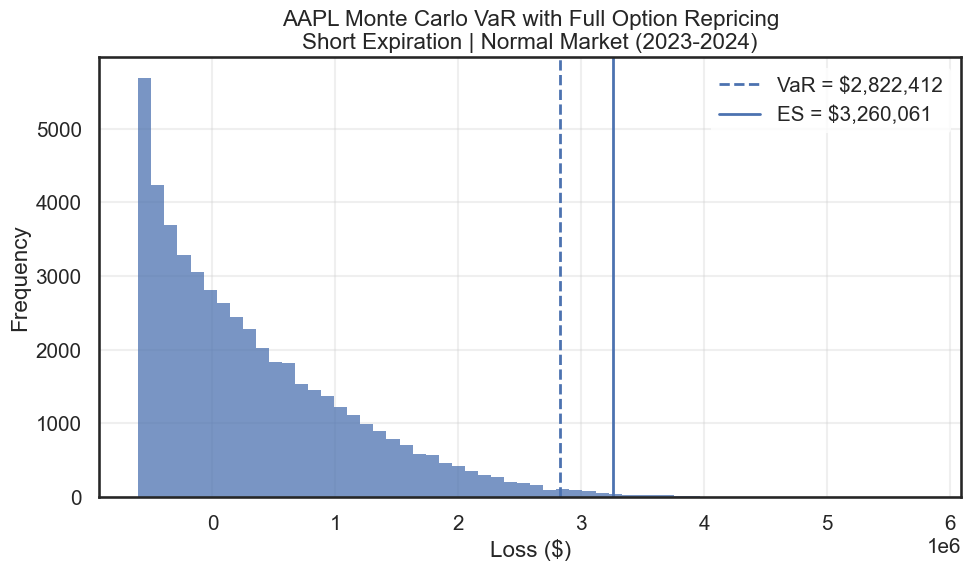

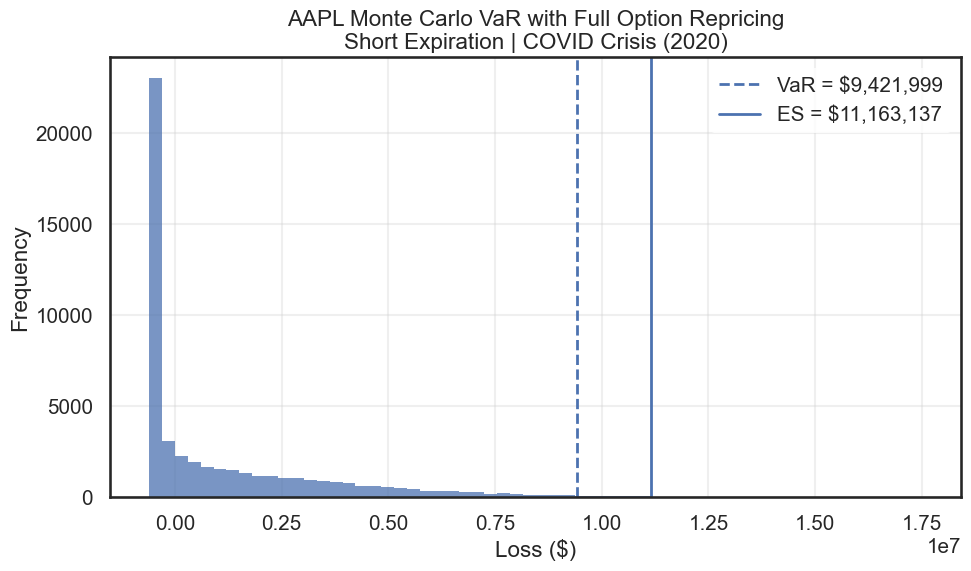

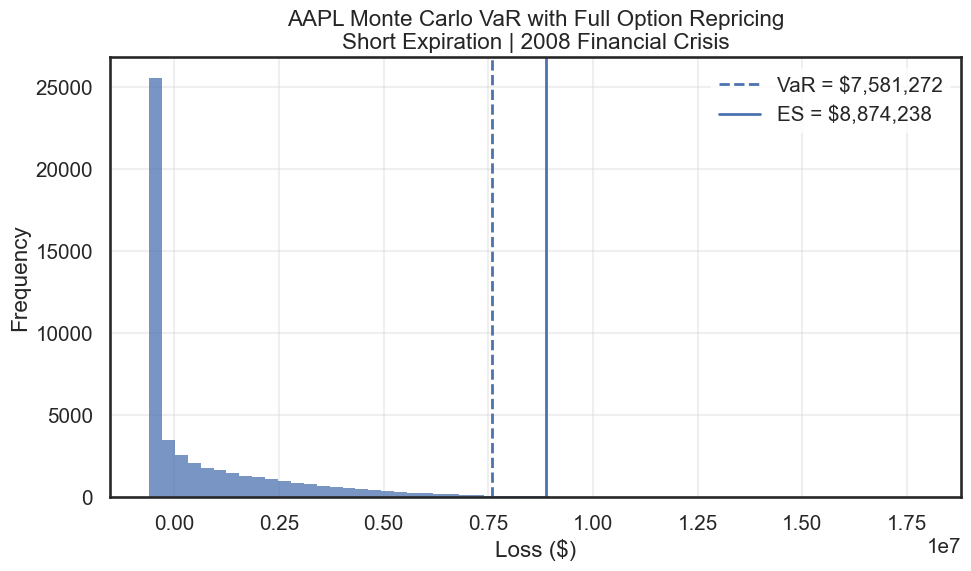

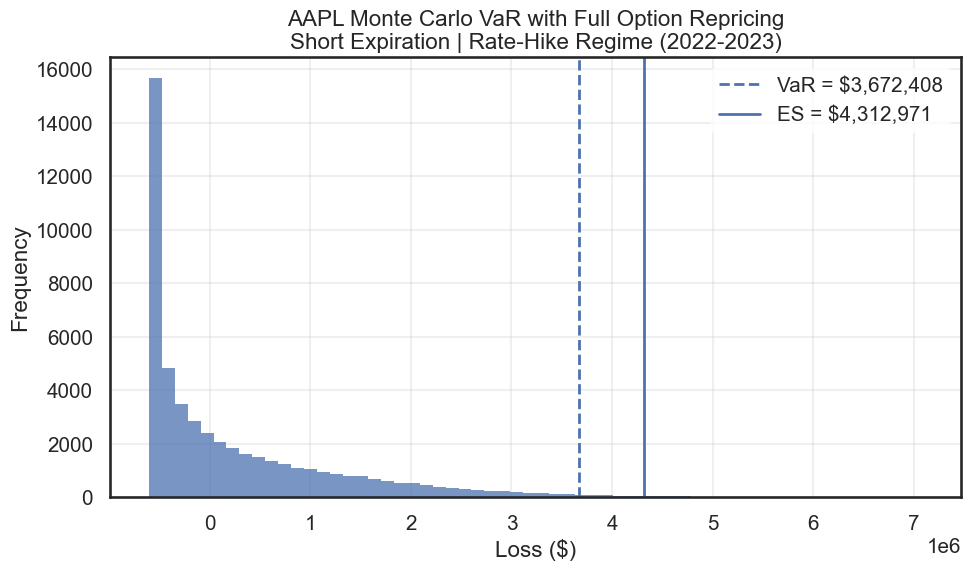

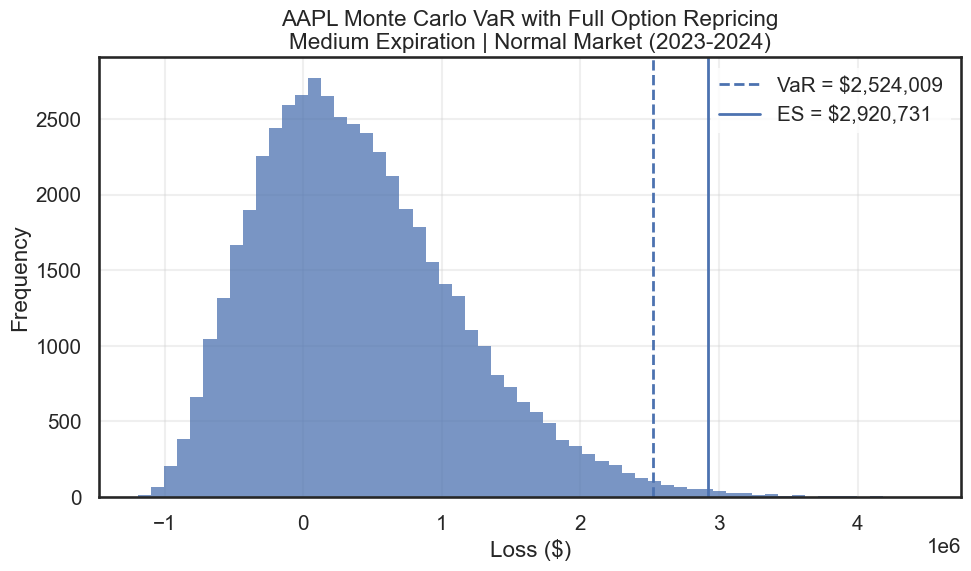

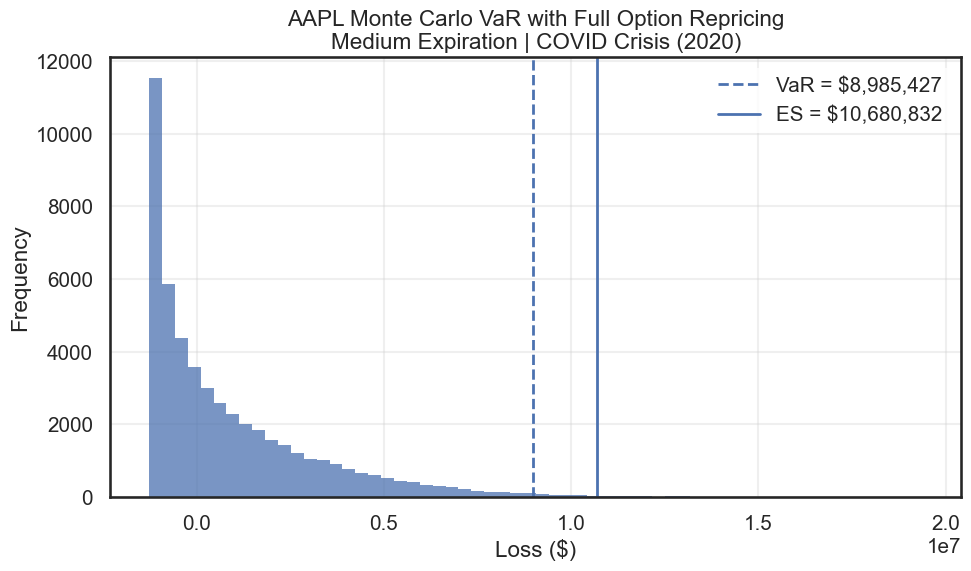

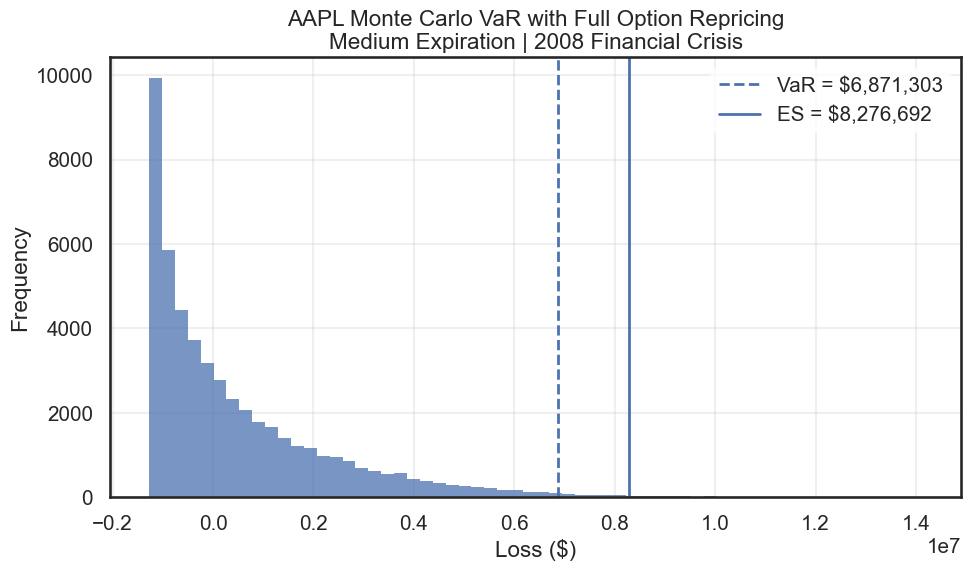

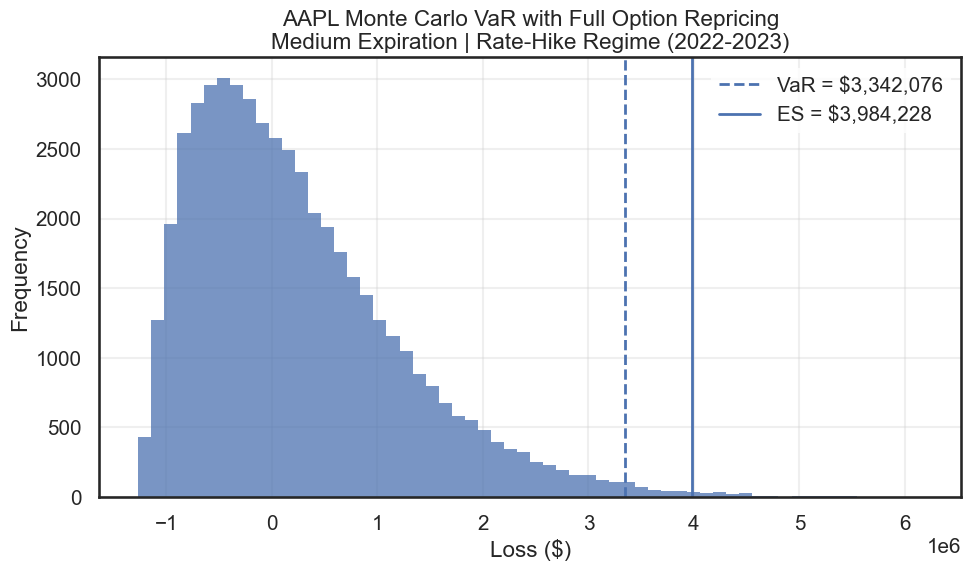

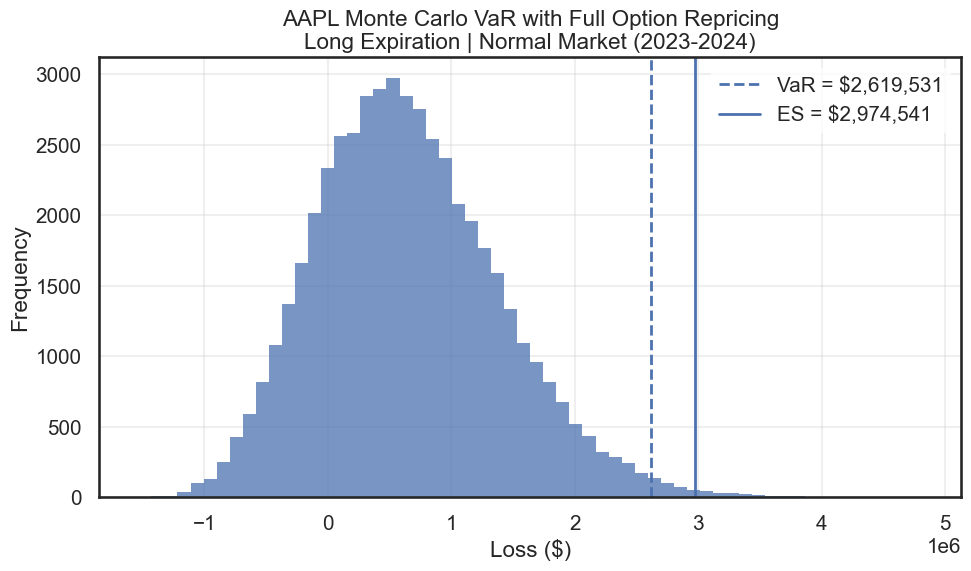

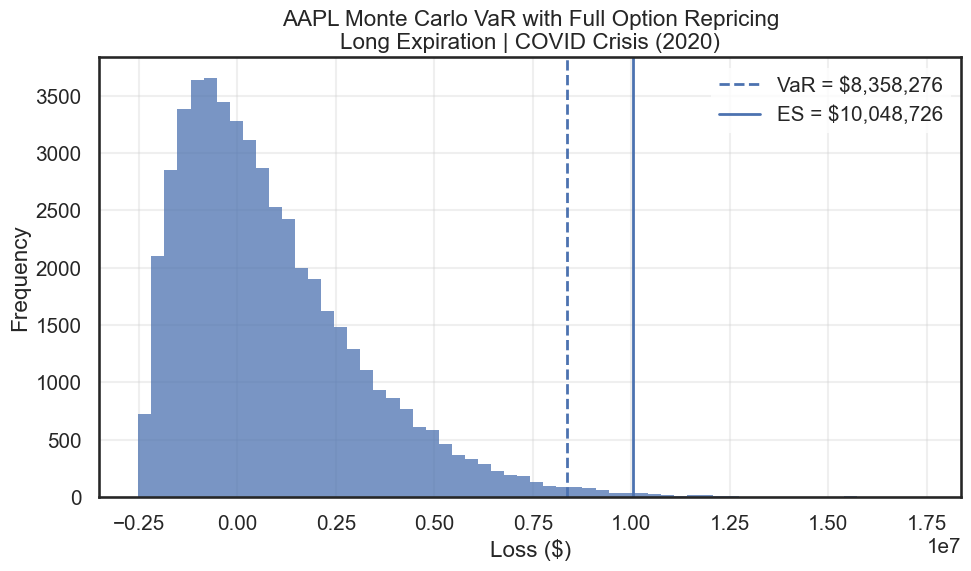

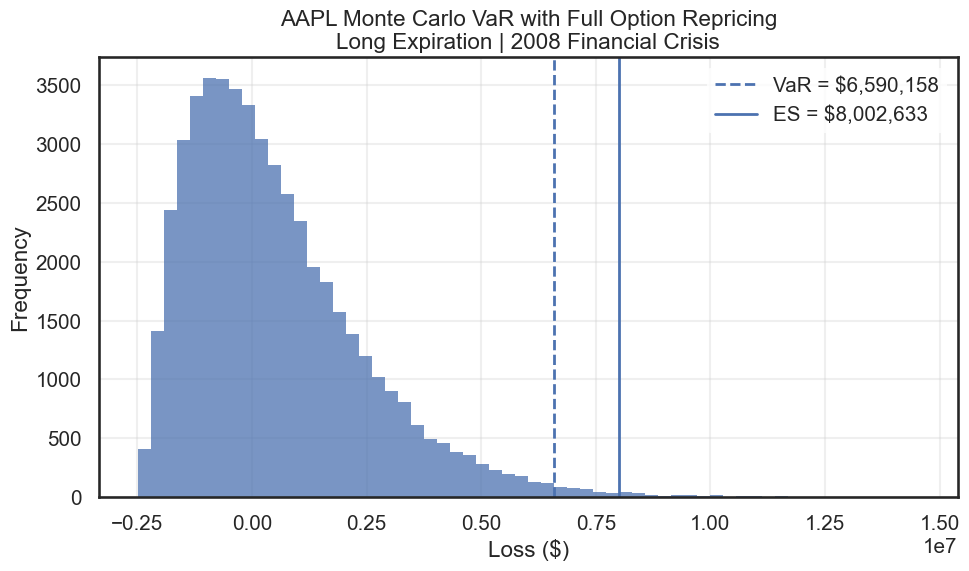

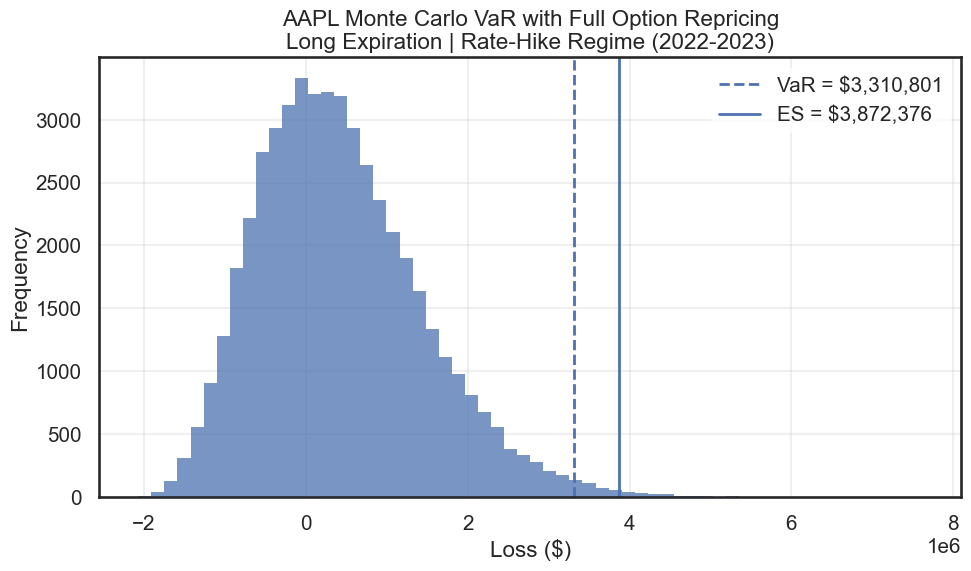

In [102]:
# ===================================================
# OPTION REPRICING VAR
# SHORT OPTION POSITION
# MULTIPLE MARKET REGIMES
# SHORT / MEDIUM / LONG EXPIRATION
# ===================================================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

# ===================================================
# SEABORN STYLE
# ===================================================

sns.set_style("white")

sns.set_context(
    "talk",
    font_scale=0.9
)

sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["patch.edgecolor"] = "lightgray"
plt.rcParams["patch.linewidth"] = 0

# ===================================================
# SETTINGS
# ===================================================

ticker_symbol = "AAPL"

option_type = "call"          # "call" or "put"

position_side = "short"       # "long" or "short"

contracts = 1000

contract_size = 100

confidence = 0.99

horizon_days = 10

n_sim = 50000

risk_free_rate = 0.045

np.random.seed(42)

# ===================================================
# MARKET REGIMES
# ===================================================

periods = {

    "Normal Market (2023-2024)": (
        "2023-01-01",
        "2024-01-01"
    ),

    "COVID Crisis (2020)": (
        "2020-02-01",
        "2020-06-01"
    ),

    "2008 Financial Crisis": (
        "2007-10-01",
        "2009-03-31"
    ),

    "Rate-Hike Regime (2022-2023)": (
        "2022-01-01",
        "2023-12-31"
    )
}

# ===================================================
# BLACK-SCHOLES FUNCTION
# ===================================================

def bs_price(
    S,
    K,
    T,
    r,
    sigma,
    option_type="call"
):

    if T <= 0:

        if option_type == "call":

            return np.maximum(
                S - K,
                0
            )

        else:

            return np.maximum(
                K - S,
                0
            )

    d1 = (

        np.log(S / K)

        + (r + 0.5 * sigma**2) * T

    ) / (

        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":

        return (

            S * norm.cdf(d1)

            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    else:

        return (

            K * np.exp(-r * T) * norm.cdf(-d2)

            - S * norm.cdf(-d1)
        )

# ===================================================
# LOAD CURRENT OPTION DATA
# ===================================================

ticker = yf.Ticker(ticker_symbol)

spot_price = ticker.history(
    period="1d"
)["Close"].iloc[-1]

today = pd.Timestamp.today().normalize()

all_expirations = [

    pd.Timestamp(exp)

    for exp in ticker.options
]

expiration_df = pd.DataFrame({

    "expiration": all_expirations
})

expiration_df["days_to_expiration"] = (

    expiration_df["expiration"]

    - today

).dt.days

# Remove expirations shorter than VaR horizon

expiration_df = expiration_df[

    expiration_df["days_to_expiration"]

    > horizon_days
]

targets = {

    "Short Expiration": 14,

    "Medium Expiration": 60,

    "Long Expiration": 180
}

selected_expirations = {}

for bucket, target_days in targets.items():

    closest_row = expiration_df.iloc[

        (
            expiration_df["days_to_expiration"]

            - target_days

        ).abs().argsort().iloc[0]
    ]

    selected_expirations[bucket] = (

        closest_row["expiration"]

        .strftime("%Y-%m-%d")
    )

print("\nSelected Expirations")

print(selected_expirations)

option_positions = {}

for bucket, expiration in selected_expirations.items():

    chain = ticker.option_chain(expiration)

    if option_type == "call":

        options = chain.calls.copy()

    else:

        options = chain.puts.copy()

    # ATM option selection

    options["strike_diff"] = abs(

        options["strike"]

        - spot_price
    )

    selected_option = (

        options

        .sort_values("strike_diff")

        .iloc[0]
    )

    K = selected_option["strike"]

    market_option_price = selected_option["lastPrice"]

    implied_vol = selected_option["impliedVolatility"]

    expiration_date = pd.Timestamp(expiration)

    T = (

        expiration_date

        - today

    ).days / 365

    T_after_horizon = max(

        T - horizon_days / 365,

        0
    )

    current_option_value = (

        market_option_price

        * contracts

        * contract_size
    )

    option_positions[bucket] = {

        "Expiration": expiration,

        "Strike": K,

        "Market Option Price": market_option_price,

        "Implied Volatility": implied_vol,

        "T": T,

        "T After Horizon": T_after_horizon,

        "Current Option Value": current_option_value
    }

print("\nSelected Option Positions")

for bucket, pos in option_positions.items():

    print("\n", bucket)

    print(pos)

def compute_option_var_by_regime(

    bucket,

    position,

    regime_name,

    start,

    end
):

    stock_prices = yf.download(

        ticker_symbol,

        start=start,

        end=end,

        auto_adjust=True,

        progress=False
    )["Close"]

    if isinstance(stock_prices, pd.DataFrame):

        stock_prices = stock_prices[ticker_symbol]

    returns = stock_prices.pct_change().dropna()

    mu_daily = returns.mean()

    sigma_daily = returns.std()

    Z = np.random.normal(size=n_sim)

    simulated_stock_prices = spot_price * np.exp(

        (
            mu_daily

            - 0.5 * sigma_daily**2
        )

        * horizon_days

        + sigma_daily

        * np.sqrt(horizon_days)

        * Z
    )
    repriced_options = bs_price(

        S=simulated_stock_prices,

        K=position["Strike"],

        T=position["T After Horizon"],

        r=risk_free_rate,

        sigma=position["Implied Volatility"],

        option_type=option_type
    )

    simulated_option_values = (

        repriced_options

        * contracts

        * contract_size
    )

    if position_side == "long":

        pnl = (

            simulated_option_values

            - position["Current Option Value"]
        )

    elif position_side == "short":

        pnl = (

            position["Current Option Value"]

            - simulated_option_values
        )

    else:

        raise ValueError(

            "position_side must be 'long' or 'short'"
        )

    losses = -pnl
    option_var = np.percentile(

        losses,

        confidence * 100
    )

    option_es = losses[

        losses >= option_var

    ].mean()

    return {

        "Expiration Bucket": bucket,

        "Regime": regime_name,

        "Expiration": position["Expiration"],

        "Strike": position["Strike"],

        "Implied Volatility": position["Implied Volatility"],

        "Current Option Value": position["Current Option Value"],

        "Daily Volatility": sigma_daily,

        "Option VaR": option_var,

        "Option ES": option_es,

        "Losses": losses
    }


all_results = []

for bucket, position in option_positions.items():

    for regime_name, (start, end) in periods.items():

        print(

            f"Running {bucket} | {regime_name}"
        )

        result = compute_option_var_by_regime(

            bucket,

            position,

            regime_name,

            start,

            end
        )

        all_results.append(result)
comparison_df = pd.DataFrame([

    {

        "Expiration Bucket": r["Expiration Bucket"],

        "Regime": r["Regime"],

        "Expiration": r["Expiration"],

        "Strike": r["Strike"],

        "Implied Volatility": r["Implied Volatility"],

        "Daily Volatility": r["Daily Volatility"],

        "Option VaR": r["Option VaR"],

        "Option ES": r["Option ES"]
    }

    for r in all_results
])

pd.set_option(

    "display.float_format",

    lambda x: f"{x:,.2f}"
)

print("\nOPTION REPRICING VAR RESULTS")

print(comparison_df)
pivot_var = comparison_df.pivot(

    index="Regime",

    columns="Expiration Bucket",

    values="Option VaR"
)

pivot_var.plot(

    kind="bar",

    figsize=(14, 7)
)

plt.title(

    f"{ticker_symbol} SHORT OPTION REPRICING VaR\n"

    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("VaR ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# ===================================================
# EXPECTED SHORTFALL BAR CHART
# ===================================================

pivot_es = comparison_df.pivot(
    index="Regime",
    columns="Expiration Bucket",
    values="Option ES"
)

pivot_es.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    f"{ticker_symbol} SHORT OPTION EXPECTED SHORTFALL\n"
    f"{option_type.upper()} | "

    f"{contracts} Contracts | "

    f"{confidence:.0%} Confidence"
)

plt.ylabel("Expected Shortfall ($)")

plt.xlabel("Market Regime")

plt.xticks(rotation=20)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# LOSS DISTRIBUTION GRAPHS
for r in all_results:
    plt.figure(figsize=(10, 6))
    plt.hist(
        r["Losses"],
        bins=60,
        alpha=0.75
    )
    plt.axvline(
        r["Option VaR"],
        linestyle="--",
        linewidth=2,
        label=f"VaR = ${r['Option VaR']:,.0f}"
    )
    plt.axvline(
      r["Option ES"],
        linestyle="-",

        linewidth=2,

        label=f"ES = ${r['Option ES']:,.0f}"
    )

    plt.title(

        f"{ticker_symbol} Monte Carlo VaR with Full Option Repricing\n"

        f"{r['Expiration Bucket']} | "

        f"{r['Regime']}"
    )

    plt.xlabel("Loss ($)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()